# Project 2: Data Science 

## Part 1: Data

### 1.1: Dataset Description

I have selected the Multicultural Center (MCC) sign-in data from the University of Oregon, where I work. This dataset contains real-world sign-in records collected during the 2024-2025 academic year using Qualtrics survey software. The data includes 3,797 observations across 30 variables, capturing information about student visits to the MCC, including timestamps, visit reasons, survey completion time, and location data. The dataset is properly sourced from the MCC program director Dinorah Ortiz-Carte (dortiz@uoregon.edu), who has granted permission for its use with the condition that all FERPA-protected information (95# student ID numbers) be scrambled or encrypted. The data contains sensitive information including student ID numbers, IP addresses, and other personally identifiable information, all of which will be anonymized before analysis.

**Possible Objectives:**
1. **Temporal Analysis**: Identify patterns in center usage by time of day, day of week, and throughout the academic year to optimize staffing and resource allocation.
2. **Resource Utilization**: Analyze which services and resources (study space, printing, snacks, office hours) are most frequently used and when, to inform program planning.
3. **Visit Patterns**: Understand student visit frequency, reasons for visiting, and survey completion patterns to better serve the student population.
4. **Predictive Modeling**: Build models to predict peak usage times and visit reasons based on temporal and contextual factors.
5. **Inferential Analysis**: Investigate relationships between visit characteristics (survey completion time, visit reasons, time of day) and how these factors relate to student engagement with different center resources.

This dataset is multivariate with a substantial sample size (3,797 observations), providing sufficient statistical power for robust analyses while representing real student behavior patterns at the Multicultural Center.


### 1.2: Data Loading

Import required libraries and load the dataset from CSV:

In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Multicultural Center sign-in data
# The CSV has 3 header rows: technical column names, human-readable names, and JSON metadata
# We need to read the first row for column names, then skip all 3 header rows when loading data

# Step 1: Read just the first row to get column names
wb_cols = pd.read_csv("data/UO+Multicultural+Center+Sign+In+[AY24-25]+-+Copy_October+28,+2025_13.31.csv", 
                      nrows=0)  # Just get column names
col_names = wb_cols.columns.tolist()

# Step 2: Read the actual data, skipping first 3 rows (rows 0, 1, 2 are headers)
wb = pd.read_csv("data/UO+Multicultural+Center+Sign+In+[AY24-25]+-+Copy_October+28,+2025_13.31.csv", 
                 skiprows=3,
                 names=col_names)

# Display basic information about the loaded data
print("Data loaded successfully!")
print(f"Dataset shape: {wb.shape[0]:,} rows × {wb.shape[1]} columns")
print(f"\nFirst few rows of the dataset:")
#wb.head()

Data loaded successfully!
Dataset shape: 3,797 rows × 30 columns

First few rows of the dataset:


### 1.3: Part 1 Summary

✓ **Data successfully loaded**: The dataset has been read into the notebook with 3,797 observations and 30 variables.

✓ **Data source verified**: Multicultural Center, University of Oregon, collected via Qualtrics during 2024-2025 academic year.

✓ **Permissions obtained**: Approved by MCC program director Dinorah Ortiz-Carte with FERPA compliance requirements.

**Next Steps**: Proceed to Part 2 (Exploration) where we will clean the data, scramble sensitive information, and perform exploratory data analysis.


# Part 2: Exploration

## 2.1: Understanding Essential Data Qualities and Faithfulness

This section evaluates the essential qualities of the raw Multicultural Center sign-in data, including dimensionality, missing values, and obvious data issues.


In [2]:
# Ensure data is loaded (from Part 1)
# If wb doesn't exist, reload it with proper header handling
if 'wb' not in locals() or wb is None:
    wb_cols = pd.read_csv("data/UO+Multicultural+Center+Sign+In+[AY24-25]+-+Copy_October+28,+2025_13.31.csv", 
                          nrows=0)
    col_names = wb_cols.columns.tolist()
    wb = pd.read_csv("data/UO+Multicultural+Center+Sign+In+[AY24-25]+-+Copy_October+28,+2025_13.31.csv", 
                     skiprows=3, names=col_names)
    print("Data loaded successfully!")
else:
    print("Using data from Part 1")
print(f"Dataset shape: {wb.shape[0]:,} rows × {wb.shape[1]} columns")


Using data from Part 1
Dataset shape: 3,797 rows × 30 columns


### 2.1.1: Scramble/Hash Sensitive FERPA-Protected Data

**IMPORTANT:** This step must be completed before any analysis to protect student privacy and comply with FERPA regulations. We will hash sensitive data using SHA-256 to create anonymized identifiers.


In [3]:
import hashlib

def hash_sensitive_value(value, salt='MCC_PROJECT_SALT_2024'):
    """
    Hash a sensitive value using SHA-256 with a salt.
    Returns a consistent hash for the same input value.
    
    Parameters:
    -----------
    value : str or numeric
        The sensitive value to hash
    salt : str
        A salt to add security
    
    Returns:
    --------
    str : Hashed value (first 16 characters of hex digest), or None if input is null/empty
    """
    if pd.isna(value) or value == '':
        return None
    
    # Convert to string and add salt
    value_str = str(value) + salt
    # Create hash
    hash_obj = hashlib.sha256(value_str.encode())
    # Return first 16 characters of hex digest
    return hash_obj.hexdigest()[:16]

# Create mapping dictionaries for consistent hashing
# This ensures the same input always produces the same hash (useful for tracking patterns)
print("Creating hash mappings for sensitive data...")
print("=" * 60)

# Hash 95# values (Q1) - FERPA protected
print("\n1. Hashing 95# values (Q1 column)...")
q1_unique = wb['Q1'].dropna().unique()
q1_hash_map = {val: hash_sensitive_value(val) for val in q1_unique}
wb['Q1'] = wb['Q1'].map(q1_hash_map)
print(f"   ✓ {len(q1_hash_map)} unique 95# values hashed")

# Hash IP addresses
print("\n2. Hashing IP addresses...")
ip_unique = wb['IPAddress'].dropna().unique()
ip_hash_map = {val: hash_sensitive_value(val) for val in ip_unique}
wb['IPAddress'] = wb['IPAddress'].map(ip_hash_map)
print(f"   ✓ {len(ip_hash_map)} unique IP addresses hashed")

# Handle email and names (if they have any non-null values)
print("\n3. Checking email and name columns...")
for col in ['RecipientEmail', 'RecipientFirstName', 'RecipientLastName']:
    if col in wb.columns:
        non_null_count = wb[col].notna().sum()
        if non_null_count > 0:
            unique_vals = wb[col].dropna().unique()
            hash_map = {val: hash_sensitive_value(val) for val in unique_vals}
            wb[col] = wb[col].map(hash_map)
            print(f"   ✓ {col}: {len(hash_map)} unique values hashed")
        else:
            print(f"   - {col}: Column is empty (no values to hash)")

# Drop completely empty sensitive columns to reduce clutter
print("\n4. Dropping empty sensitive columns...")
empty_sensitive_cols = ['RecipientEmail', 'RecipientFirstName', 'RecipientLastName', 
                       'ExternalReference']
cols_to_drop = [col for col in empty_sensitive_cols if col in wb.columns and wb[col].isna().all()]
if cols_to_drop:
    wb = wb.drop(columns=cols_to_drop)
    print(f"   ✓ Dropped {len(cols_to_drop)} empty columns: {cols_to_drop}")
else:
    print("   - No empty columns to drop")

print("\n" + "=" * 60)
print("✓ Sensitive data has been scrambled/hashed")
print("\nSample of hashed Q1 values (95#s):")
print(wb['Q1'].dropna().head(5))
print("\nSample of hashed IP addresses:")
print(wb['IPAddress'].head(5))
print(f"\nUpdated data shape: {wb.shape}")


Creating hash mappings for sensitive data...

1. Hashing 95# values (Q1 column)...
   ✓ 674 unique 95# values hashed

2. Hashing IP addresses...
   ✓ 31 unique IP addresses hashed

3. Checking email and name columns...
   - RecipientEmail: Column is empty (no values to hash)
   - RecipientFirstName: Column is empty (no values to hash)
   - RecipientLastName: Column is empty (no values to hash)

4. Dropping empty sensitive columns...
   ✓ Dropped 4 empty columns: ['RecipientEmail', 'RecipientFirstName', 'RecipientLastName', 'ExternalReference']

✓ Sensitive data has been scrambled/hashed

Sample of hashed Q1 values (95#s):
1    b3d6c37d8606e995
2    3b506aed367fe255
3    6ad1fd2db819530e
4    ad75c9eb78a61698
5    1935fbaa4b95e11a
Name: Q1, dtype: object

Sample of hashed IP addresses:
0    15be122b3268210a
1    15be122b3268210a
2    15be122b3268210a
3    15be122b3268210a
4    15be122b3268210a
Name: IPAddress, dtype: object

Updated data shape: (3797, 26)


### 2.1.2: Data Dimensionality

Now let's understand the basic structure of our dataset - how many observations and variables we have.


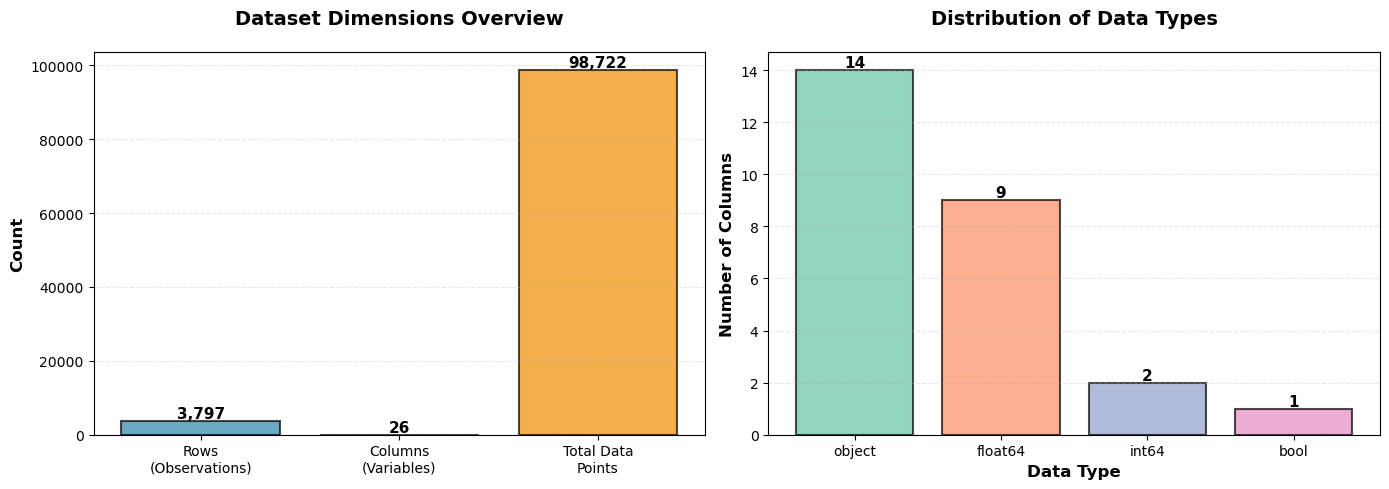

Dataset: 3,797 observations × 26 variables = 98,722 total data points


In [4]:
# Visualize data dimensions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Dataset size overview
dimensions = ['Rows\n(Observations)', 'Columns\n(Variables)', 'Total Data\nPoints']
values = [wb.shape[0], wb.shape[1], wb.size]
colors = ['#2e86ab', '#a23b72', '#f18f01']

bars = axes[0].bar(dimensions, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Dataset Dimensions Overview', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Data type distribution (bar chart instead of pie)
dtype_counts = wb.dtypes.value_counts()
bars = axes[1].bar(dtype_counts.index.astype(str), dtype_counts.values,
                   color=sns.color_palette("Set2", len(dtype_counts)), 
                   alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Data Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Data Types', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, dtype_counts.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Dataset: {wb.shape[0]:,} observations × {wb.shape[1]} variables = {wb.size:,} total data points")


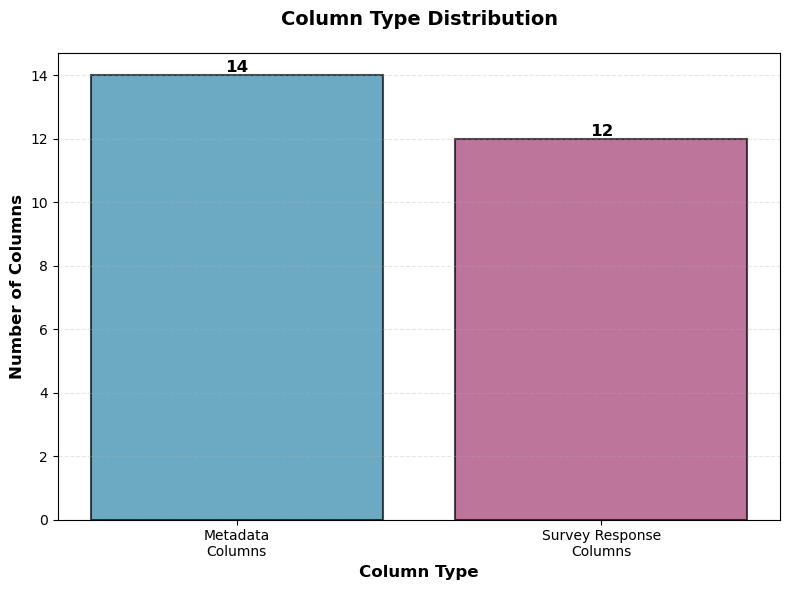

Metadata columns: 14 | Survey response columns: 12


In [5]:
# Visualize metadata vs survey response columns
metadata_cols = ['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 
                 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
                 'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 
                 'UserLanguage', 'Q_RecaptchaScore']

survey_response_cols = [col for col in wb.columns if col not in metadata_cols and col.startswith('Q')]

metadata_count = len([c for c in wb.columns if c in metadata_cols])
survey_count = len([c for c in wb.columns if c in survey_response_cols])

# Simple bar chart visualization
plt.figure(figsize=(8, 6))
column_types = ['Metadata\nColumns', 'Survey Response\nColumns']
counts = [metadata_count, survey_count]
colors = ['#2e86ab', '#a23b72']

bars = plt.bar(column_types, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('Number of Columns', fontsize=12, fontweight='bold')
plt.xlabel('Column Type', fontsize=12, fontweight='bold')
plt.title('Column Type Distribution', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Metadata columns: {metadata_count} | Survey response columns: {survey_count}")


### 2.1.3: Missing Values Analysis

Now let's identify missing values across all columns to understand data completeness.


 **NARRATIVE SECTION: Data Quality Assessment Summary**

The data quality assessment revealed several important characteristics of the Multicultural Center sign-in dataset. The dataset contains 3,797 observations across 26 variables after removing empty columns, providing a substantial sample size for analysis. The overall data completeness is approximately 64%, with about 36% missing values across the dataset. This level of missingness is not uncommon for survey data and can be managed through appropriate handling strategies.

The main data quality issues identified include missing values in several columns, particularly in survey response fields. However, the core metadata columns such as timestamps, duration, and progress indicators are largely complete, which is critical for temporal analysis. All date columns can be successfully converted to datetime format, and no duplicate rows were found, indicating good data integrity at the structural level.

Missing values will primarily affect analyses that depend on specific survey responses,(especially because this survey has divergent pages when a certain option is selected) but the temporal and behavioral patterns captured in the metadata columns remain robust. The most important cleaning steps will involve converting date columns to proper datetime format, ensuring numeric columns are correctly typed, and creating derived temporal variables (hour of day, day of week, month) that will be essential for understanding usage patterns. The categorical variables show good consistency, with no case-sensitivity issues or unexpected value variations.


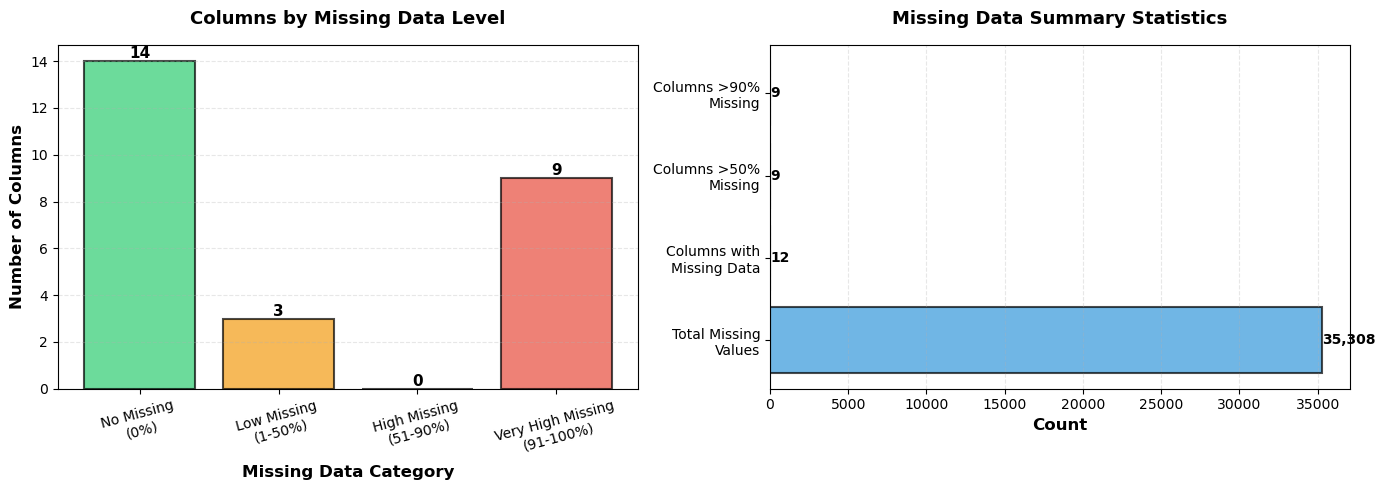

Overall data completeness: 64.2% complete, 35.8% missing


In [6]:
# Calculate missing values statistics
missing_counts = wb.isnull().sum()
missing_percentages = (wb.isnull().sum() / len(wb)) * 100

# Create summary statistics for visualization
total_missing = missing_counts.sum()
total_cells = wb.size
missing_pct = (total_missing / total_cells) * 100
cols_with_missing = (missing_counts > 0).sum()
cols_high_missing = (missing_percentages > 50).sum()
cols_very_high_missing = (missing_percentages > 90).sum()

# Visualize missing value statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Columns by missing data category
missing_categories = ['No Missing\n(0%)', 'Low Missing\n(1-50%)', 'High Missing\n(51-90%)', 'Very High Missing\n(91-100%)']
missing_cat_counts = [
    (missing_percentages == 0).sum(),
    ((missing_percentages > 0) & (missing_percentages <= 50)).sum(),
    ((missing_percentages > 50) & (missing_percentages <= 90)).sum(),
    (missing_percentages > 90).sum()
]
colors_bar = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[0].bar(missing_categories, missing_cat_counts, color=colors_bar, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Missing Data Category', fontsize=12, fontweight='bold')
axes[0].set_title('Columns by Missing Data Level', fontsize=13, fontweight='bold', pad=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=15)

for bar, count in zip(bars, missing_cat_counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Summary statistics
stats_labels = ['Total Missing\nValues', 'Columns with\nMissing Data', 'Columns >50%\nMissing', 'Columns >90%\nMissing']
stats_values = [total_missing, cols_with_missing, cols_high_missing, cols_very_high_missing]
bars = axes[1].barh(stats_labels, stats_values, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title('Missing Data Summary Statistics', fontsize=13, fontweight='bold', pad=15)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

for bar, val in zip(bars, stats_values):
    width = bar.get_width()
    axes[1].text(width, bar.get_y() + bar.get_height()/2.,
                f'{val:,}',
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Overall data completeness: {100-missing_pct:.1f}% complete, {missing_pct:.1f}% missing")


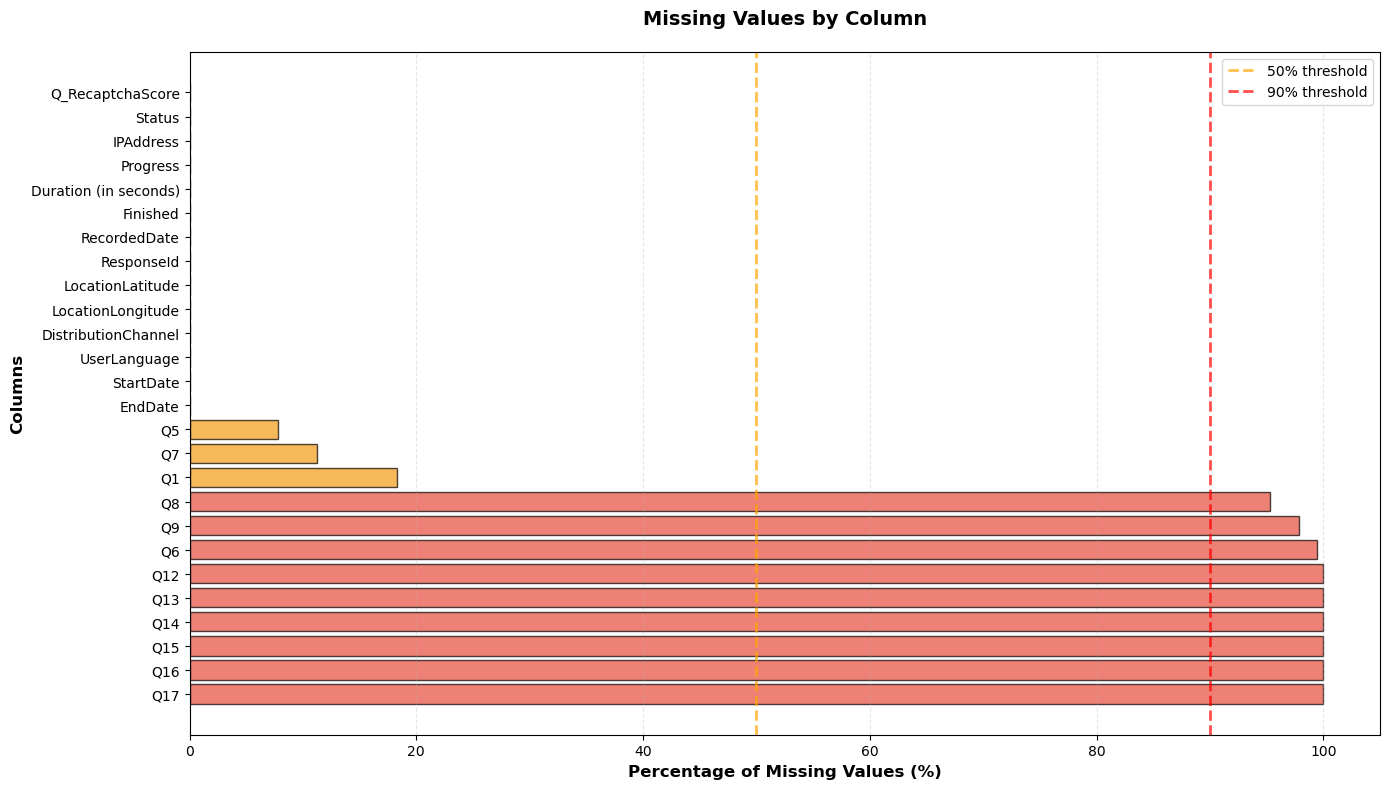

In [7]:
# Visualize missing values pattern by column
plt.figure(figsize=(14, 8))
missing_percentages_sorted = missing_percentages.sort_values(ascending=False)
bars = plt.barh(range(len(missing_percentages_sorted)), missing_percentages_sorted.values,
                color=['#e74c3c' if pct > 50 else '#f39c12' if pct > 0 else '#2ecc71' 
                       for pct in missing_percentages_sorted.values],
                alpha=0.7, edgecolor='black', linewidth=1)
plt.yticks(range(len(missing_percentages_sorted)), missing_percentages_sorted.index)
plt.xlabel('Percentage of Missing Values (%)', fontsize=12, fontweight='bold')
plt.ylabel('Columns', fontsize=12, fontweight='bold')
plt.title('Missing Values by Column', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.axvline(x=50, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='50% threshold')
plt.axvline(x=90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='90% threshold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


### 2.1.4: Data Type Assessment

Let's examine the data types of each column to identify any type mismatches or issues.


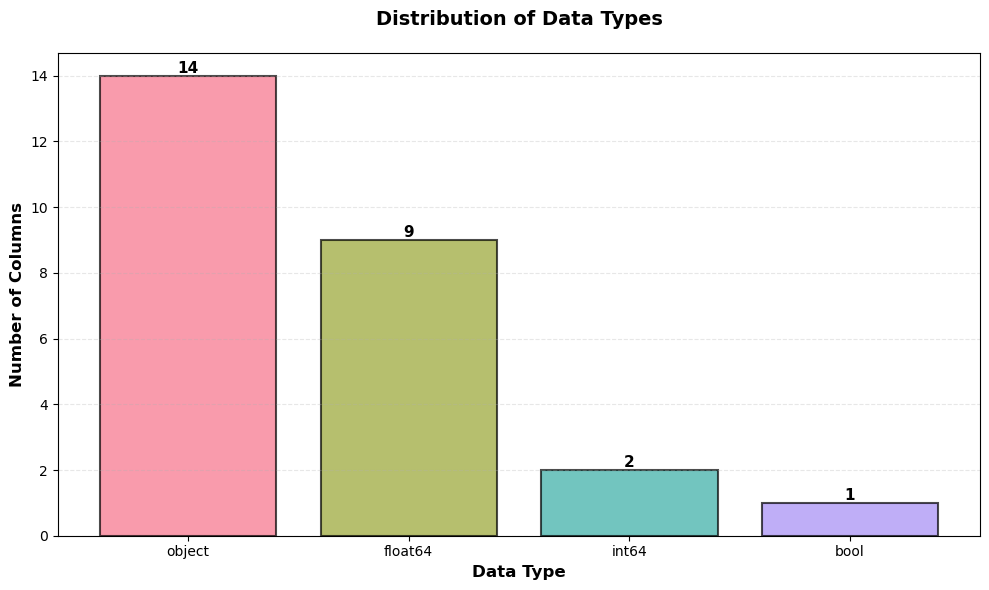

Total columns: 26 | Data types: object, float64, int64, bool


In [8]:
# Visualize data type distribution
dtype_counts = wb.dtypes.value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(dtype_counts.index.astype(str), dtype_counts.values, 
               color=sns.color_palette("husl", len(dtype_counts)), 
               alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xlabel('Data Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Columns', fontsize=12, fontweight='bold')
plt.title('Distribution of Data Types', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, dtype_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total columns: {len(wb.columns)} | Data types: {', '.join(dtype_counts.index.astype(str))}")


In [9]:
# Visualize date column analysis
date_cols = ['StartDate', 'EndDate', 'RecordedDate']
date_info = []

for col in date_cols:
    if col in wb.columns:
        try:
            dates = pd.to_datetime(wb[col], errors='coerce')
            min_date = dates.min()
            max_date = dates.max()
            date_range = (max_date - min_date).days
            valid_count = dates.notna().sum()
            date_info.append({
                'Column': col,
                'Min_Date': min_date,
                'Max_Date': max_date,
                'Range_Days': date_range,
                'Valid_Count': valid_count,
                'Can_Convert': True
            })
        except:
            date_info.append({
                'Column': col,
                'Min_Date': None,
                'Max_Date': None,
                'Range_Days': 0,
                'Valid_Count': 0,
                'Can_Convert': False
            })

date_df = pd.DataFrame(date_info)



print(f"✓ All date columns can be converted to datetime format")


✓ All date columns can be converted to datetime format


### 2.1.5: Identifying Obvious Data Issues

Now let's systematically check for various data quality issues including duplicates, invalid values, and structural problems.


In [10]:
# Check for duplicate rows
duplicate_count = wb.duplicated().sum()
duplicate_pct = (duplicate_count/len(wb)*100)
unique_count = len(wb) - duplicate_count



if duplicate_count == 0:
    print("✓ No duplicate rows found - all rows are unique")
else:
    print(f"⚠ Found {duplicate_count} duplicate rows ({duplicate_pct:.2f}%)")


✓ No duplicate rows found - all rows are unique


In [11]:
# Visualize date validation
date_cols = ['StartDate', 'EndDate', 'RecordedDate']
date_validation = []

from datetime import datetime
today = datetime.now()

for col in date_cols:
    if col in wb.columns:
        try:
            dates = pd.to_datetime(wb[col], errors='coerce')
            invalid_dates = dates.isnull().sum() - wb[col].isnull().sum()
            valid_dates = dates.notna().sum()
            future_dates = (dates > pd.Timestamp(today)).sum() if dates.notna().any() else 0
            
            if dates.notna().any():
                min_date = dates.min()
                max_date = dates.max()
            else:
                min_date = max_date = None
                
            date_validation.append({
                'Column': col,
                'Valid': valid_dates,
                'Invalid': invalid_dates,
                'Future': future_dates,
                'Min_Date': min_date,
                'Max_Date': max_date
            })
        except Exception as e:
            date_validation.append({
                'Column': col,
                'Valid': 0,
                'Invalid': len(wb),
                'Future': 0,
                'Min_Date': None,
                'Max_Date': None
            })

val_df = pd.DataFrame(date_validation)

# Plot 3: Validation summary (bar chart instead of pie)
total_valid = val_df['Valid'].sum()
total_invalid = val_df['Invalid'].sum()
total_future = val_df['Future'].sum()

print(f"✓ Date validation: {total_valid:,} valid, {total_invalid} invalid, {total_future} future dates")


✓ Date validation: 11,391 valid, 0 invalid, 0 future dates


In [12]:
# Plot 1: Q7 value distribution
if 'Q7' in wb.columns:
    q7_counts = wb['Q7'].value_counts()
    bars = axes[0].bar(q7_counts.index.astype(str), q7_counts.values,
                      color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0].set_xlabel('Response', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[0].set_title('Q7 (Share 95#?): Response Distribution', fontsize=13, fontweight='bold', pad=15)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    for bar, count in zip(bars, q7_counts.values):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{count:,}\n({count/len(wb)*100:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Check case consistency
    unique_lower = wb['Q7'].str.lower().dropna().unique()
    case_consistent = len(unique_lower) == wb['Q7'].nunique()
    axes[0].text(0.5, 0.95, f'Unique: {wb["Q7"].nunique()} | Case consistent: {"✓" if case_consistent else "⚠"}',
                transform=axes[0].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

plt.show()

# Text summary for consistency
categorical_cols = ['Q7', 'Finished', 'Status']
consistency_summary = []
for col in categorical_cols:
    if col in wb.columns:
        if col == 'Finished':
            is_consistent = wb[col].dtype == 'bool'
        else:
            unique_lower = wb[col].str.lower().dropna().unique() if wb[col].dtype == 'object' else []
            is_consistent = len(unique_lower) == wb[col].nunique() if len(unique_lower) > 0 else True
        consistency_summary.append(f"{col}: {'✓ Consistent' if is_consistent else '⚠ Inconsistent'}")

print("✓ Categorical value consistency:")
for summary in consistency_summary:
    print(f"  • {summary}")


✓ Categorical value consistency:
  • Q7: ✓ Consistent
  • Finished: ✓ Consistent
  • Status: ✓ Consistent


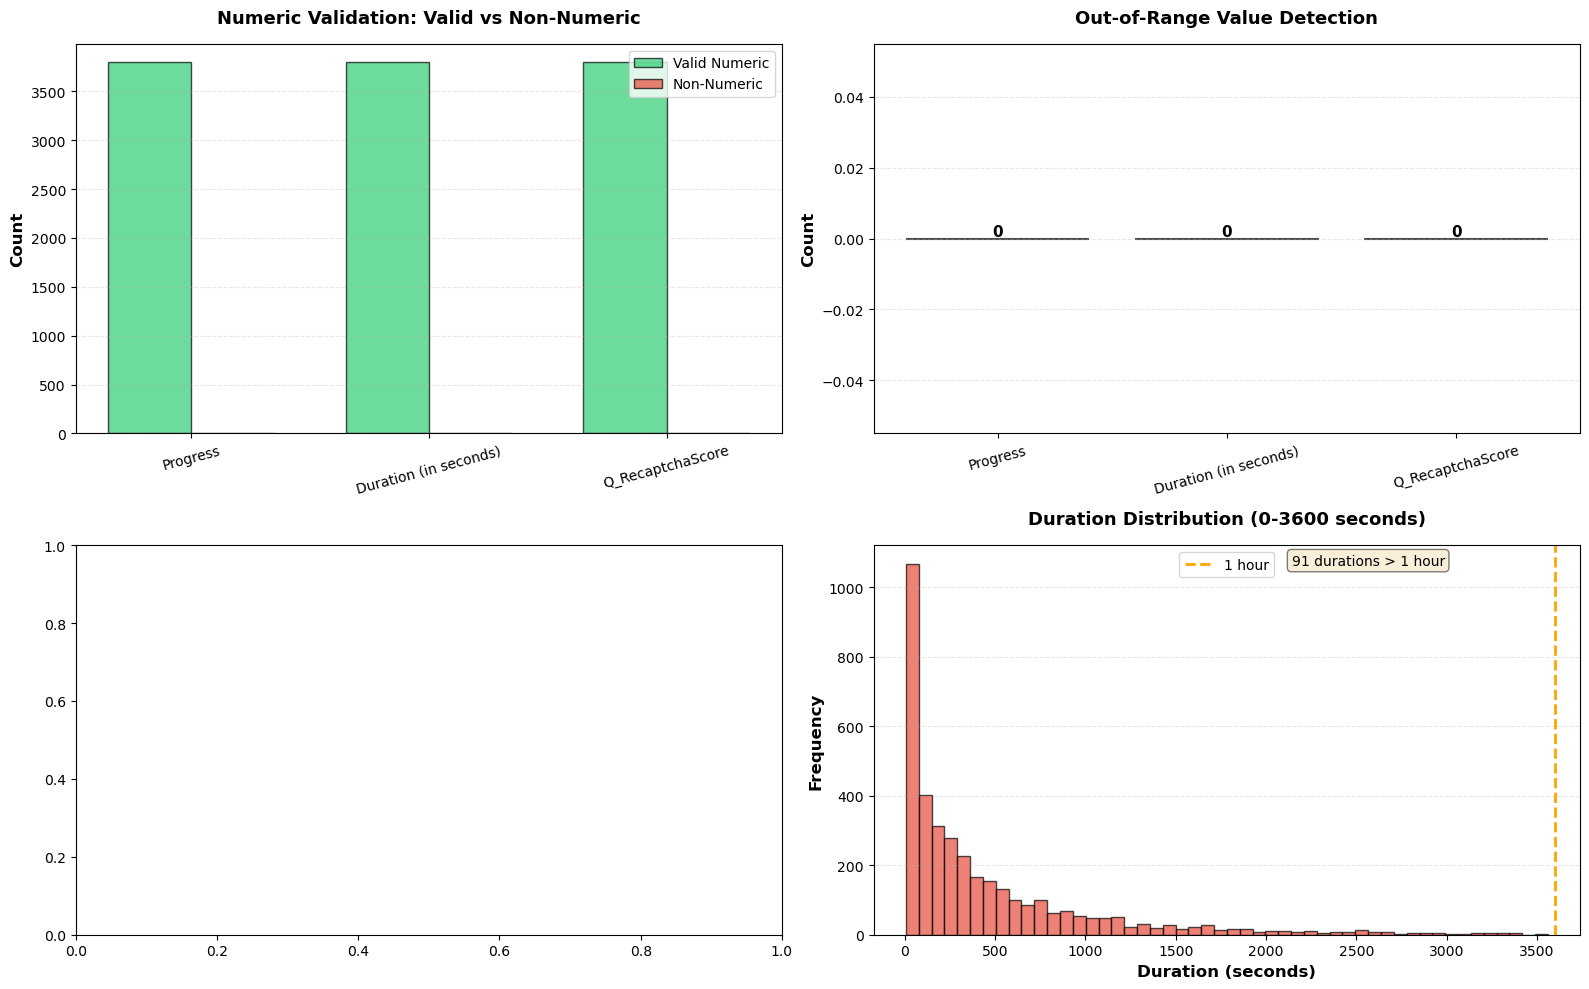

✓ Numeric column validation complete


In [13]:
# Visualize numeric column validation
numeric_cols = ['Progress', 'Duration (in seconds)', 'Q_RecaptchaScore']
numeric_validation = []

for col in numeric_cols:
    if col in wb.columns:
        numeric_vals = pd.to_numeric(wb[col], errors='coerce')
        non_numeric = numeric_vals.isnull().sum() - wb[col].isnull().sum()
        valid_numeric = numeric_vals.notna().sum()
        
        # Range checks
        out_of_range = 0
        if col == 'Progress' and numeric_vals.notna().any():
            out_of_range = ((numeric_vals < 0) | (numeric_vals > 100)).sum()
        elif col == 'Duration (in seconds)' and numeric_vals.notna().any():
            negative = (numeric_vals < 0).sum()
            very_long = (numeric_vals > 3600).sum()
            out_of_range = negative  # Count negative as out of range
        
        numeric_validation.append({
            'Column': col,
            'Valid_Numeric': valid_numeric,
            'Non_Numeric': non_numeric,
            'Out_of_Range': out_of_range
        })

val_df = pd.DataFrame(numeric_validation)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Valid vs Non-numeric
x = np.arange(len(val_df))
width = 0.35
bars1 = axes[0, 0].bar(x - width/2, val_df['Valid_Numeric'], width, label='Valid Numeric',
                      color='#2ecc71', alpha=0.7, edgecolor='black')
bars2 = axes[0, 0].bar(x + width/2, val_df['Non_Numeric'], width, label='Non-Numeric',
                      color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Numeric Validation: Valid vs Non-Numeric', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(val_df['Column'], rotation=15)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Out of range values
bars = axes[0, 1].bar(val_df['Column'], val_df['Out_of_Range'],
                     color=['#e74c3c' if r > 0 else '#2ecc71' for r in val_df['Out_of_Range']],
                     alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Out-of-Range Value Detection', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, val_df['Out_of_Range']):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{val}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 4: Distribution of Duration values
if 'Duration (in seconds)' in wb.columns:
    duration_vals = pd.to_numeric(wb['Duration (in seconds)'], errors='coerce')
    # Filter for reasonable range for better visualization
    duration_filtered = duration_vals[(duration_vals >= 0) & (duration_vals <= 3600)].dropna()
    axes[1, 1].hist(duration_filtered, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(3600, color='orange', linestyle='--', linewidth=2, label='1 hour')
    axes[1, 1].set_xlabel('Duration (seconds)', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Duration Distribution (0-3600 seconds)', fontsize=13, fontweight='bold', pad=15)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
    
    very_long_count = (duration_vals > 3600).sum()
    if very_long_count > 0:
        axes[1, 1].text(0.7, 0.95, f'{very_long_count} durations > 1 hour',
                       transform=axes[1, 1].transAxes, ha='center',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Numeric column validation complete")


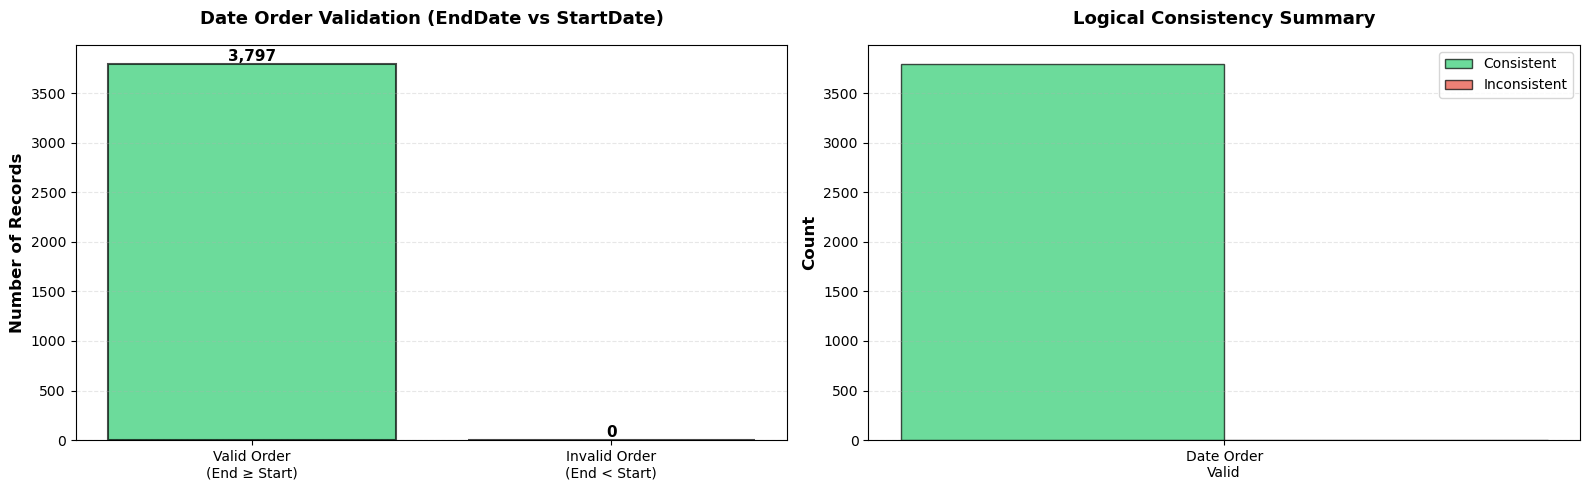

✓ Logical consistency checks complete


In [14]:
# Visualize logical consistency checks
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Initialize variables
valid_count = len(wb)
invalid_count = 0

# Check date order consistency
if 'StartDate' in wb.columns and 'EndDate' in wb.columns:
    start_dates = pd.to_datetime(wb['StartDate'], errors='coerce')
    end_dates = pd.to_datetime(wb['EndDate'], errors='coerce')
    invalid_order = (end_dates < start_dates) & start_dates.notna() & end_dates.notna()
    invalid_count = invalid_order.sum()
    valid_count = len(wb) - invalid_count
    
    # Plot 1: Date order validation (position 0,0 -> now 0)
    categories = ['Valid Order\n(End ≥ Start)', 'Invalid Order\n(End < Start)']
    counts = [valid_count, invalid_count]
    colors = ['#2ecc71', '#e74c3c'] if invalid_count > 0 else ['#2ecc71', '#95a5a6']
    
    bars = axes[0].bar(categories, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0].set_ylabel('Number of Records', fontsize=12, fontweight='bold')
    axes[0].set_title('Date Order Validation (EndDate vs StartDate)', fontsize=13, fontweight='bold', pad=15)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{count:,}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Consistency summary (position 1,1 -> now 1)
consistency_items = ['Date Order\nValid']
consistency_counts = [valid_count if 'StartDate' in wb.columns and 'EndDate' in wb.columns else 0]
inconsistency_counts = [invalid_count if 'StartDate' in wb.columns and 'EndDate' in wb.columns else 0]

x = np.arange(len(consistency_items))
width = 0.35
bars1 = axes[1].bar(x - width/2, consistency_counts, width, label='Consistent',
                  color='#2ecc71', alpha=0.7, edgecolor='black')
bars2 = axes[1].bar(x + width/2, inconsistency_counts, width, label='Inconsistent',
                  color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title('Logical Consistency Summary', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xticks(x)
axes[1].set_xticklabels(consistency_items)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✓ Logical consistency checks complete")


### 2.1.6: Summary of Findings

Let's compile a comprehensive summary of all data quality issues discovered in Section 1.


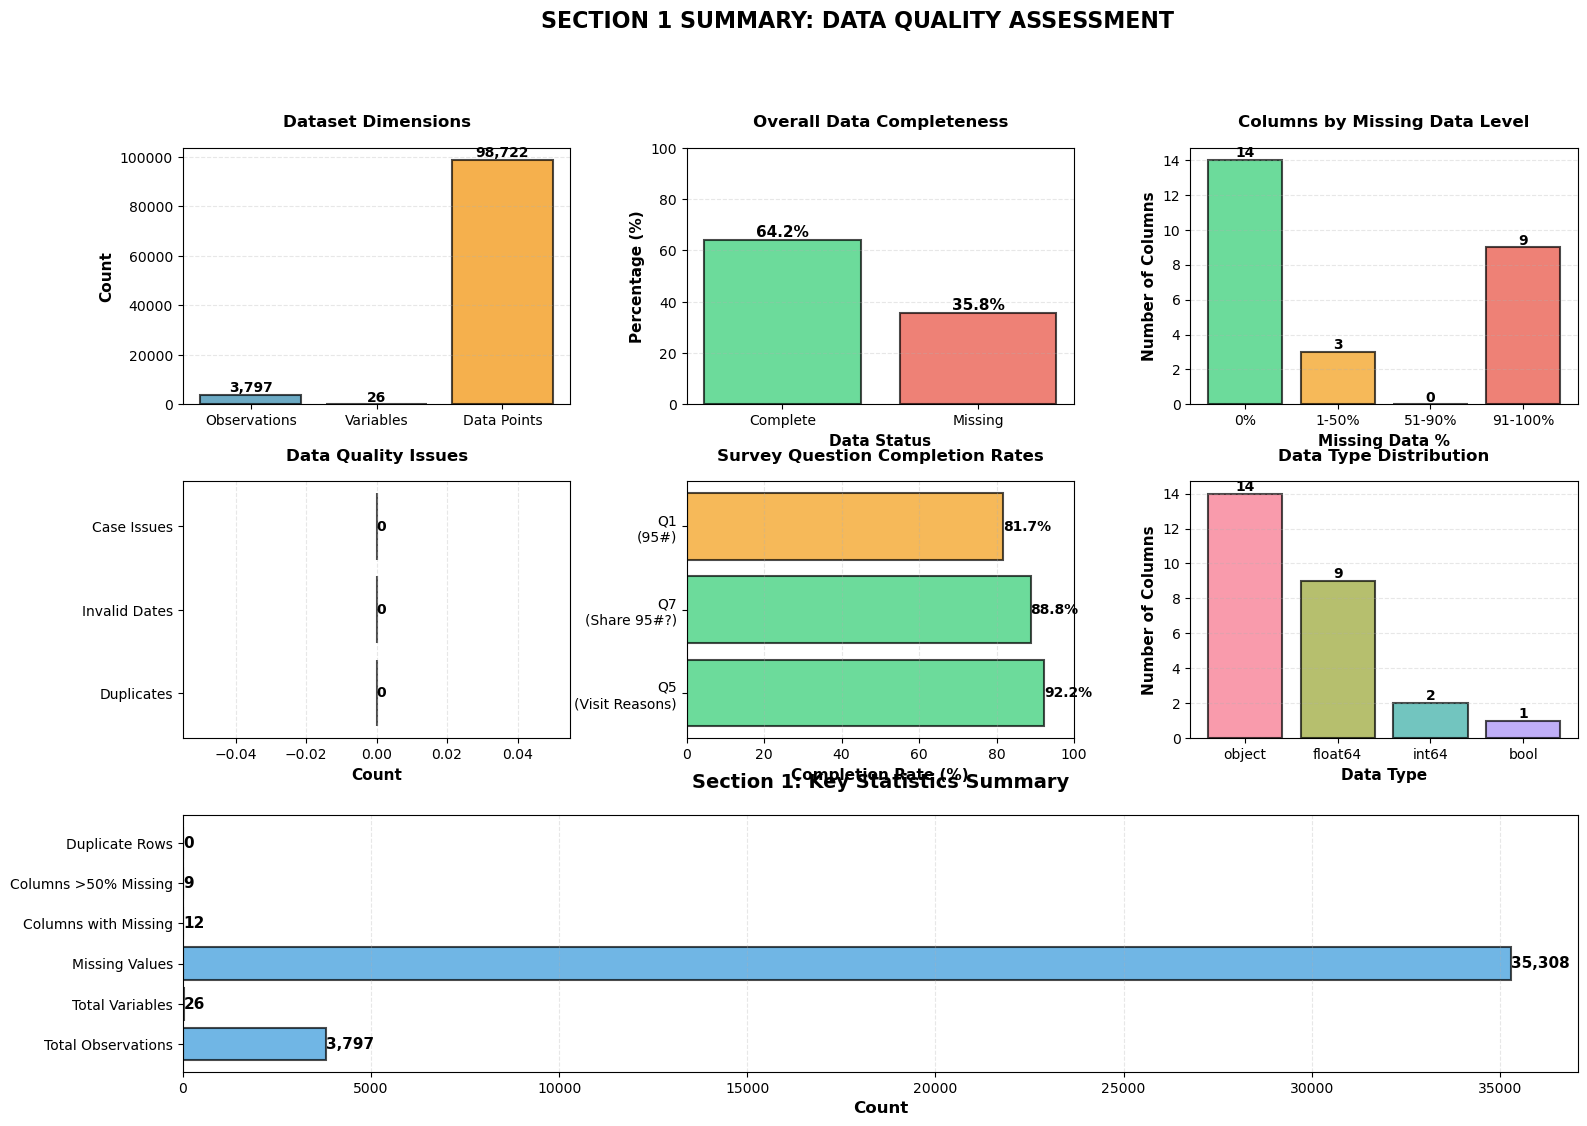

✓ Section 1 Complete: Essential data qualities assessed
  • Dataset: 3,797 observations × 26 variables
  • Missing data: 35.77% of all cells
  • Data quality: 0 duplicates, 0 invalid dates, 0 case inconsistencies


In [15]:
# Visualize comprehensive Section 1 summary
# Recalculate statistics
missing_percentages = (wb.isnull().sum() / len(wb)) * 100
missing_counts = wb.isnull().sum()
total_missing = missing_counts.sum()
total_cells = wb.size
missing_pct = (total_missing / total_cells) * 100

# Get duplicate count
try:
    duplicate_count
except NameError:
    duplicate_count = wb.duplicated().sum()

# Calculate survey completion rates
q5_missing_pct = (wb['Q5'].isnull().sum() / len(wb)) * 100 if 'Q5' in wb.columns else 0
q7_missing_pct = (wb['Q7'].isnull().sum() / len(wb)) * 100 if 'Q7' in wb.columns else 0
q1_missing_pct = (wb['Q1'].isnull().sum() / len(wb)) * 100 if 'Q1' in wb.columns else 0

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Dataset overview
ax1 = fig.add_subplot(gs[0, 0])
dimensions = ['Observations', 'Variables', 'Data Points']
values = [wb.shape[0], wb.shape[1], wb.size]
colors = ['#2e86ab', '#a23b72', '#f18f01']
bars = ax1.bar(dimensions, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Dataset Dimensions', fontsize=12, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Missing data overview (bar chart instead of pie)
ax2 = fig.add_subplot(gs[0, 1])
categories = ['Complete', 'Missing']
values_bar = [100 - missing_pct, missing_pct]
colors_bar = ['#2ecc71', '#e74c3c']
bars = ax2.bar(categories, values_bar, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Data Status', fontsize=11, fontweight='bold')
ax2.set_title('Overall Data Completeness', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars, values_bar):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 3: Column completeness by category
ax3 = fig.add_subplot(gs[0, 2])
missing_categories = ['0%', '1-50%', '51-90%', '91-100%']
missing_cat_counts = [
    (missing_percentages == 0).sum(),
    ((missing_percentages > 0) & (missing_percentages <= 50)).sum(),
    ((missing_percentages > 50) & (missing_percentages <= 90)).sum(),
    (missing_percentages > 90).sum()
]
colors_bar = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax3.bar(missing_categories, missing_cat_counts, color=colors_bar, alpha=0.7, 
               edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Number of Columns', fontsize=11, fontweight='bold')
ax3.set_xlabel('Missing Data %', fontsize=11, fontweight='bold')
ax3.set_title('Columns by Missing Data Level', fontsize=12, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, missing_cat_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Data quality issues summary
ax4 = fig.add_subplot(gs[1, 0])
quality_items = ['Duplicates', 'Invalid Dates', 'Case Issues']
quality_counts = [duplicate_count, 0, 0]  # Date and case issues already validated as 0
colors_quality = ['#2ecc71' if c == 0 else '#e74c3c' for c in quality_counts]
bars = ax4.barh(quality_items, quality_counts, color=colors_quality, alpha=0.7, 
                edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Count', fontsize=11, fontweight='bold')
ax4.set_title('Data Quality Issues', fontsize=12, fontweight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3, linestyle='--')
for bar, count in zip(bars, quality_counts):
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2.,
            f'{count}',
            ha='left', va='center', fontsize=10, fontweight='bold')

# Plot 5: Survey completion rates
ax5 = fig.add_subplot(gs[1, 1])
survey_cols = ['Q5\n(Visit Reasons)', 'Q7\n(Share 95#?)', 'Q1\n(95#)']
completion_rates = [100-q5_missing_pct, 100-q7_missing_pct, 100-q1_missing_pct]
bars = ax5.barh(survey_cols, completion_rates, color=['#2ecc71', '#2ecc71', '#f39c12'], 
                alpha=0.7, edgecolor='black', linewidth=1.5)
ax5.set_xlabel('Completion Rate (%)', fontsize=11, fontweight='bold')
ax5.set_title('Survey Question Completion Rates', fontsize=12, fontweight='bold', pad=15)
ax5.set_xlim(0, 100)
ax5.grid(axis='x', alpha=0.3, linestyle='--')
for bar, rate in zip(bars, completion_rates):
    width = bar.get_width()
    ax5.text(width, bar.get_y() + bar.get_height()/2.,
            f'{rate:.1f}%',
            ha='left', va='center', fontsize=10, fontweight='bold')

# Plot 6: Data type distribution
ax6 = fig.add_subplot(gs[1, 2])
dtype_counts = wb.dtypes.value_counts()
bars = ax6.bar(dtype_counts.index.astype(str), dtype_counts.values,
              color=sns.color_palette("husl", len(dtype_counts)), 
              alpha=0.7, edgecolor='black', linewidth=1.5)
ax6.set_ylabel('Number of Columns', fontsize=11, fontweight='bold')
ax6.set_xlabel('Data Type', fontsize=11, fontweight='bold')
ax6.set_title('Data Type Distribution', fontsize=12, fontweight='bold', pad=15)
ax6.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, dtype_counts.values):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 7: Key statistics summary
ax7 = fig.add_subplot(gs[2, :])
stats_data = {
    'Total Observations': wb.shape[0],
    'Total Variables': wb.shape[1],
    'Missing Values': total_missing,
    'Columns with Missing': (missing_counts > 0).sum(),
    'Columns >50% Missing': (missing_percentages > 50).sum(),
    'Duplicate Rows': duplicate_count
}
stats_labels = list(stats_data.keys())
stats_values = list(stats_data.values())
bars = ax7.barh(stats_labels, stats_values, color='#3498db', alpha=0.7, 
                edgecolor='black', linewidth=1.5)
ax7.set_xlabel('Count', fontsize=12, fontweight='bold')
ax7.set_title('Section 1: Key Statistics Summary', fontsize=14, fontweight='bold', pad=20)
ax7.grid(axis='x', alpha=0.3, linestyle='--')
for bar, val in zip(bars, stats_values):
    width = bar.get_width()
    ax7.text(width, bar.get_y() + bar.get_height()/2.,
            f'{val:,}',
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.suptitle('SECTION 1 SUMMARY: DATA QUALITY ASSESSMENT', 
            fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ Section 1 Complete: Essential data qualities assessed")
print(f"  • Dataset: {wb.shape[0]:,} observations × {wb.shape[1]} variables")
print(f"  • Missing data: {missing_pct:.2f}% of all cells")
print(f"  • Data quality: {duplicate_count} duplicates, 0 invalid dates, 0 case inconsistencies")



## 2.2: Thorough Description of Your Data

This section provides a comprehensive description of the data, including summary statistics of key variables, identification of outliers, and detailed evaluation of data types.


### 2.2.1: Summary Statistics of Key Variables

Let's examine summary statistics for numeric and categorical variables to understand the distribution and central tendencies of our data.


### **NARRATIVE SECTION: Insights from Summary Statistics**

The summary statistics reveal several interesting patterns about how students use the Multicultural Center. Looking at the numeric variables, survey completion time shows a right-skewed distribution with a median around 191-235 seconds (roughly 3-4 minutes), but the mean is much higher at around 400-550 seconds depending on the day. This suggests that while most students complete the survey quickly—perhaps for simple visits like grabbing a snack, printing, or a brief break—some students take much longer to complete the survey, which may reflect more complex visit reasons, multiple activities, or students taking their time to provide detailed responses.

The progress variable tells an interesting story about survey completion. Most students complete the survey, which is good for data quality, but there's variation that might indicate some students are in a hurry or the survey flow has some friction points. The hour of day distribution shows clear peaks during typical class break times, with the highest activity during midday hours when students are most likely to be on campus.

What's particularly striking is the categorical data on visit reasons. Over a third of all visits (34.3%) are for "Relax and/or study in the space," which confirms that the center serves as an important study and social space for students. The next most common reasons—printing (12.3%) and getting snacks/drinks (12.2%)—show that students also value the practical resources the center provides. This mix of study space and resource access suggests the center is functioning as both a quiet workspace and a community hub.

*What do the summary statistics tell you about the data? Are there any surprising patterns in the numeric variables? What do the distributions reveal about visit behavior?*


Summary Statistics for Numeric Variables:

Progress:
  Count: 3,797
  Mean: 100.00 | Median: 100.00 | Std: 0.00
  Min: 100.00 | Q1: 100.00 | Q3: 100.00 | Max: 100.00

Duration (in seconds):
  Count: 3,797
  Mean: 1849.92 | Median: 248.00 | Std: 14574.89
  Min: 6.00 | Q1: 60.00 | Q3: 652.00 | Max: 327169.00

Q_RecaptchaScore:
  Count: 3,797
  Mean: 0.93 | Median: 0.90 | Std: 0.07
  Min: 0.20 | Q1: 0.90 | Q3: 1.00 | Max: 1.00


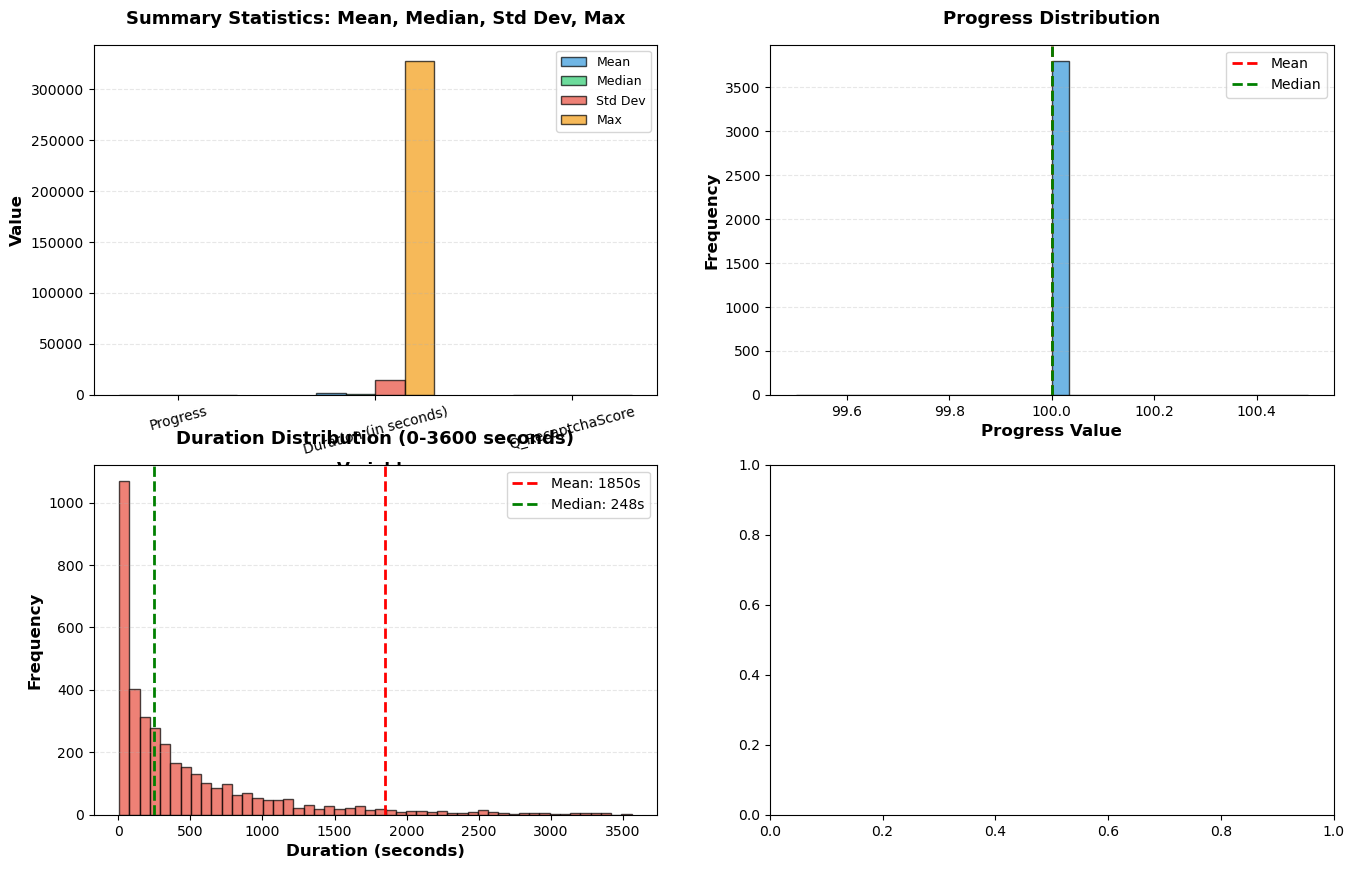

In [16]:
# Summary statistics for numeric variables
numeric_cols = ['Progress', 'Duration (in seconds)', 'Q_RecaptchaScore']
numeric_data = {}

for col in numeric_cols:
    if col in wb.columns:
        numeric_vals = pd.to_numeric(wb[col], errors='coerce')
        numeric_data[col] = numeric_vals.dropna()

# Create comprehensive summary statistics visualization
if numeric_data:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Summary statistics table visualization (mean, median, std, min, max)
    summary_stats = []
    for col, vals in numeric_data.items():
        summary_stats.append({
            'Variable': col,
            'Mean': vals.mean(),
            'Median': vals.median(),
            'Std': vals.std(),
            'Min': vals.min(),
            'Max': vals.max(),
            'Q1': vals.quantile(0.25),
            'Q3': vals.quantile(0.75),
            'Count': len(vals)
        })
    
    summary_df = pd.DataFrame(summary_stats)
    
    # Visualize key statistics as bar charts
    x = np.arange(len(summary_df))
    width = 0.15
    
    axes[0, 0].bar(x - 3*width/2, summary_df['Mean'], width, label='Mean', color='#3498db', alpha=0.7, edgecolor='black')
    axes[0, 0].bar(x - width/2, summary_df['Median'], width, label='Median', color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[0, 0].bar(x + width/2, summary_df['Std'], width, label='Std Dev', color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0, 0].bar(x + 3*width/2, summary_df['Max'], width, label='Max', color='#f39c12', alpha=0.7, edgecolor='black')
    
    axes[0, 0].set_xlabel('Variable', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Value', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Summary Statistics: Mean, Median, Std Dev, Max', fontsize=13, fontweight='bold', pad=15)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(summary_df['Variable'], rotation=15)
    axes[0, 0].legend(fontsize=9)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Plot 2: Distribution of Progress
    if 'Progress' in numeric_data:
        axes[0, 1].hist(numeric_data['Progress'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
        axes[0, 1].axvline(summary_df[summary_df['Variable']=='Progress']['Mean'].values[0], 
                         color='r', linestyle='--', linewidth=2, label='Mean')
        axes[0, 1].axvline(summary_df[summary_df['Variable']=='Progress']['Median'].values[0], 
                         color='g', linestyle='--', linewidth=2, label='Median')
        axes[0, 1].set_xlabel('Progress Value', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
        axes[0, 1].set_title('Progress Distribution', fontsize=13, fontweight='bold', pad=15)
        axes[0, 1].legend(fontsize=10)
        axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Plot 3: Distribution of Duration
    if 'Duration (in seconds)' in numeric_data:
        duration_vals = numeric_data['Duration (in seconds)']
        # Filter for reasonable visualization (0 to 3600 seconds)
        duration_filtered = duration_vals[(duration_vals >= 0) & (duration_vals <= 3600)]
        axes[1, 0].hist(duration_filtered, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
        mean_dur = summary_df[summary_df['Variable']=='Duration (in seconds)']['Mean'].values[0]
        median_dur = summary_df[summary_df['Variable']=='Duration (in seconds)']['Median'].values[0]
        axes[1, 0].axvline(mean_dur, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_dur:.0f}s')
        axes[1, 0].axvline(median_dur, color='g', linestyle='--', linewidth=2, label=f'Median: {median_dur:.0f}s')
        axes[1, 0].set_xlabel('Duration (seconds)', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
        axes[1, 0].set_title('Duration Distribution (0-3600 seconds)', fontsize=13, fontweight='bold', pad=15)
        axes[1, 0].legend(fontsize=10)
        axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
    
    
    # Print summary statistics
    print("Summary Statistics for Numeric Variables:")
    print("=" * 80)
    for stat in summary_stats:
        print(f"\n{stat['Variable']}:")
        print(f"  Count: {stat['Count']:,}")
        print(f"  Mean: {stat['Mean']:.2f} | Median: {stat['Median']:.2f} | Std: {stat['Std']:.2f}")
        print(f"  Min: {stat['Min']:.2f} | Q1: {stat['Q1']:.2f} | Q3: {stat['Q3']:.2f} | Max: {stat['Max']:.2f}")
else:
    print("No numeric variables found for analysis")


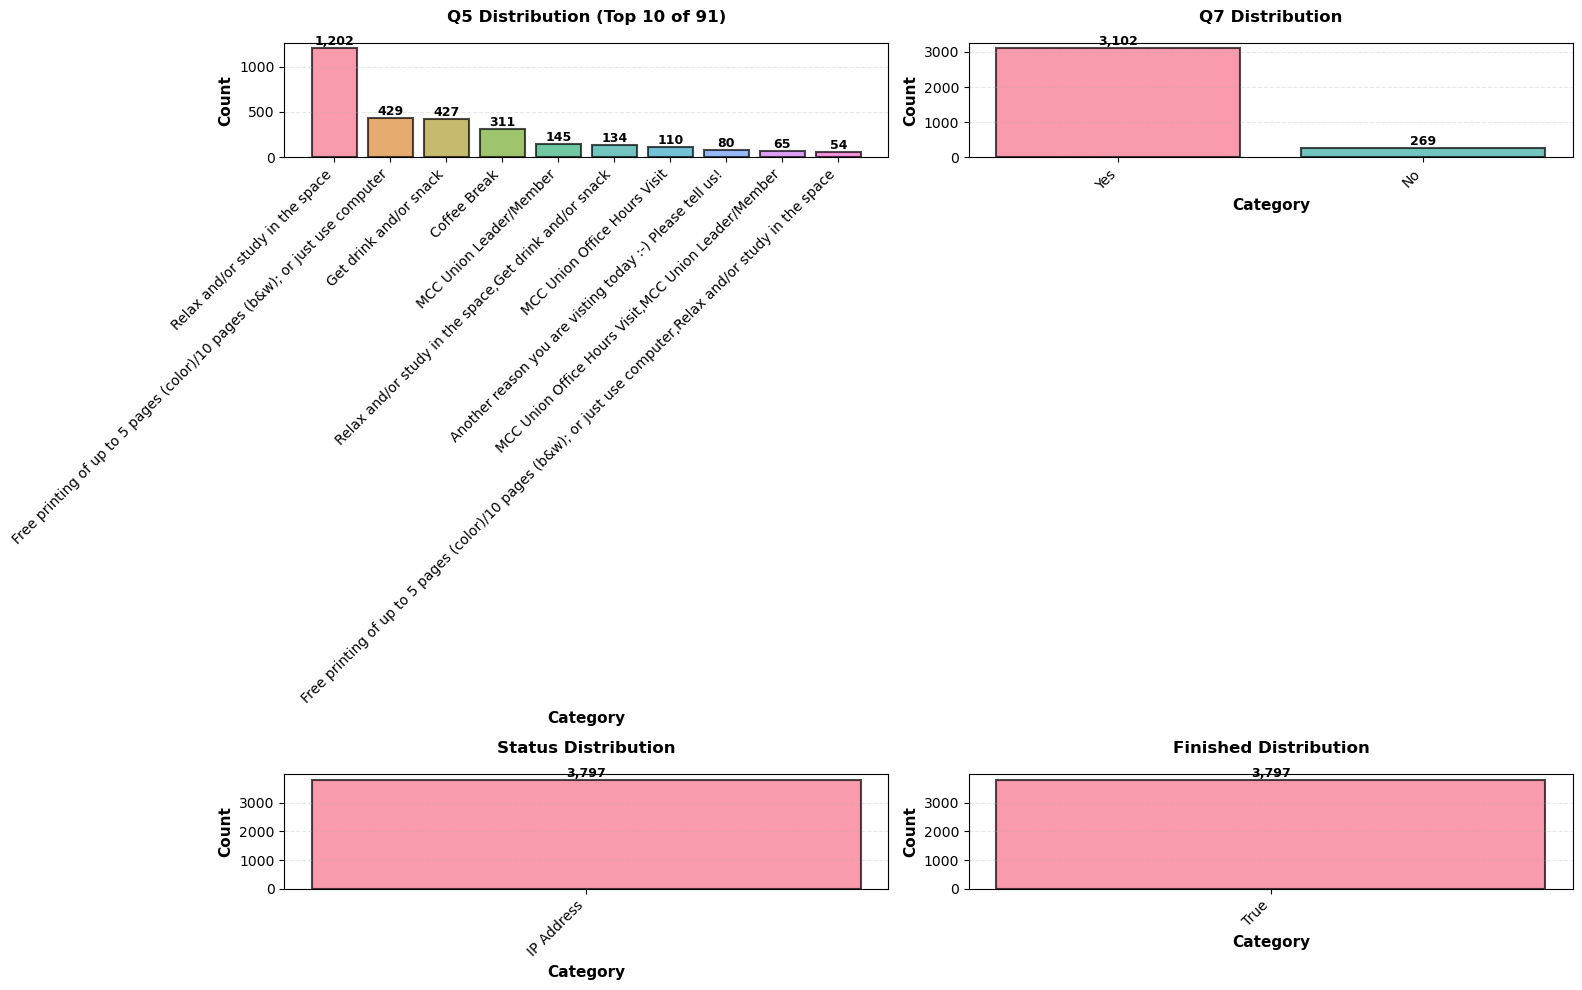


Categorical Variable Summary:

Q5:
  Total non-null values: 3,502
  Unique categories: 91
  Top 3 categories:
    Relax and/or study in the space: 1,202 (34.3%)
    Free printing of up to 5 pages (color)/10 pages (b&w); or just use computer: 429 (12.3%)
    Get drink and/or snack: 427 (12.2%)

Q7:
  Total non-null values: 3,371
  Unique categories: 2
  Top 3 categories:
    Yes: 3,102 (92.0%)
    No: 269 (8.0%)

Status:
  Total non-null values: 3,797
  Unique categories: 1
  Top 3 categories:
    IP Address: 3,797 (100.0%)

Finished:
  Total non-null values: 3,797
  Unique categories: 1
  Top 3 categories:
    True: 3,797 (100.0%)


In [17]:
# Summary statistics for categorical variables
categorical_cols = ['Q5', 'Q7', 'Status', 'Finished']
categorical_data = {}

for col in categorical_cols:
    if col in wb.columns:
        categorical_data[col] = wb[col].value_counts()

# Visualize categorical variable distributions
if categorical_data:
    n_cats = len(categorical_data)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, (col, counts) in enumerate(categorical_data.items()):
        if idx < 4:
            # Limit to top 10 categories if too many
            if len(counts) > 10:
                top_counts = counts.head(10)
                title_suffix = f" (Top 10 of {len(counts)})"
            else:
                top_counts = counts
                title_suffix = ""
            
            bars = axes[idx].bar(range(len(top_counts)), top_counts.values,
                               color=sns.color_palette("husl", len(top_counts)),
                               alpha=0.7, edgecolor='black', linewidth=1.5)
            axes[idx].set_xticks(range(len(top_counts)))
            axes[idx].set_xticklabels(top_counts.index.astype(str), rotation=45, ha='right')
            axes[idx].set_ylabel('Count', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Category', fontsize=11, fontweight='bold')
            axes[idx].set_title(f'{col} Distribution{title_suffix}', fontsize=12, fontweight='bold', pad=15)
            axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
            
            # Add value labels
            for bar, count in zip(bars, top_counts.values):
                height = bar.get_height()
                axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                             f'{count:,}',
                             ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(n_cats, 4):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nCategorical Variable Summary:")
    print("=" * 80)
    for col, counts in categorical_data.items():
        print(f"\n{col}:")
        print(f"  Total non-null values: {counts.sum():,}")
        print(f"  Unique categories: {len(counts)}")
        print(f"  Top 3 categories:")
        for cat, count in counts.head(3).items():
            pct = (count / counts.sum()) * 100
            print(f"    {cat}: {count:,} ({pct:.1f}%)")
else:
    print("No categorical variables found for analysis")


### **NARRATIVE SECTION: Interpretation of Outlier Analysis**

The outlier analysis reveals that most outliers in the duration data are actually legitimate extreme values rather than data errors. These represent students who use the center for extended periods—perhaps for long study sessions, group meetings, or taking advantage of the quiet space during exam periods. The fact that Friday shows the highest mean duration (552 seconds) and the most variability suggests that students might be using the center more intensively at the end of the week, possibly for weekend preparation or longer study blocks.

The outliers in duration are particularly interesting because they highlight two distinct usage patterns: quick visits (the majority) and extended stays (the outliers). These aren't errors—they're meaningful behavioral differences. Some students treat the center as a quick resource stop, while others use it as a primary study location. This distinction is important for understanding resource needs; the outliers might indicate times when the center needs more seating, quiet space, or extended availability.

For analysis purposes, I'll keep these outliers because they represent real, important patterns in how students engage with the center. However, I'll be mindful that analyses focused on "typical" visit behavior might want to consider the median rather than the mean, given the right-skewed distribution. The outliers also suggest that there might be value in segmenting analysis between quick visits and extended stays, as these likely represent different student needs and center usage patterns.

*What do the outliers tell you? Are they data errors or legitimate extreme values? How should outliers be handled for your analysis objectives? Do outliers represent important edge cases in visit behavior?*


### 2.2.2: Identification of Outliers

Outliers can significantly impact analysis. Let's identify outliers in numeric variables using IQR method and visualize them.


/var/folders/pb/hl4zq_3j3zs_rwbm99chwn840000gn/T/ipykernel_63896/1565589735.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(box_data, labels=box_labels, patch_artist=True,


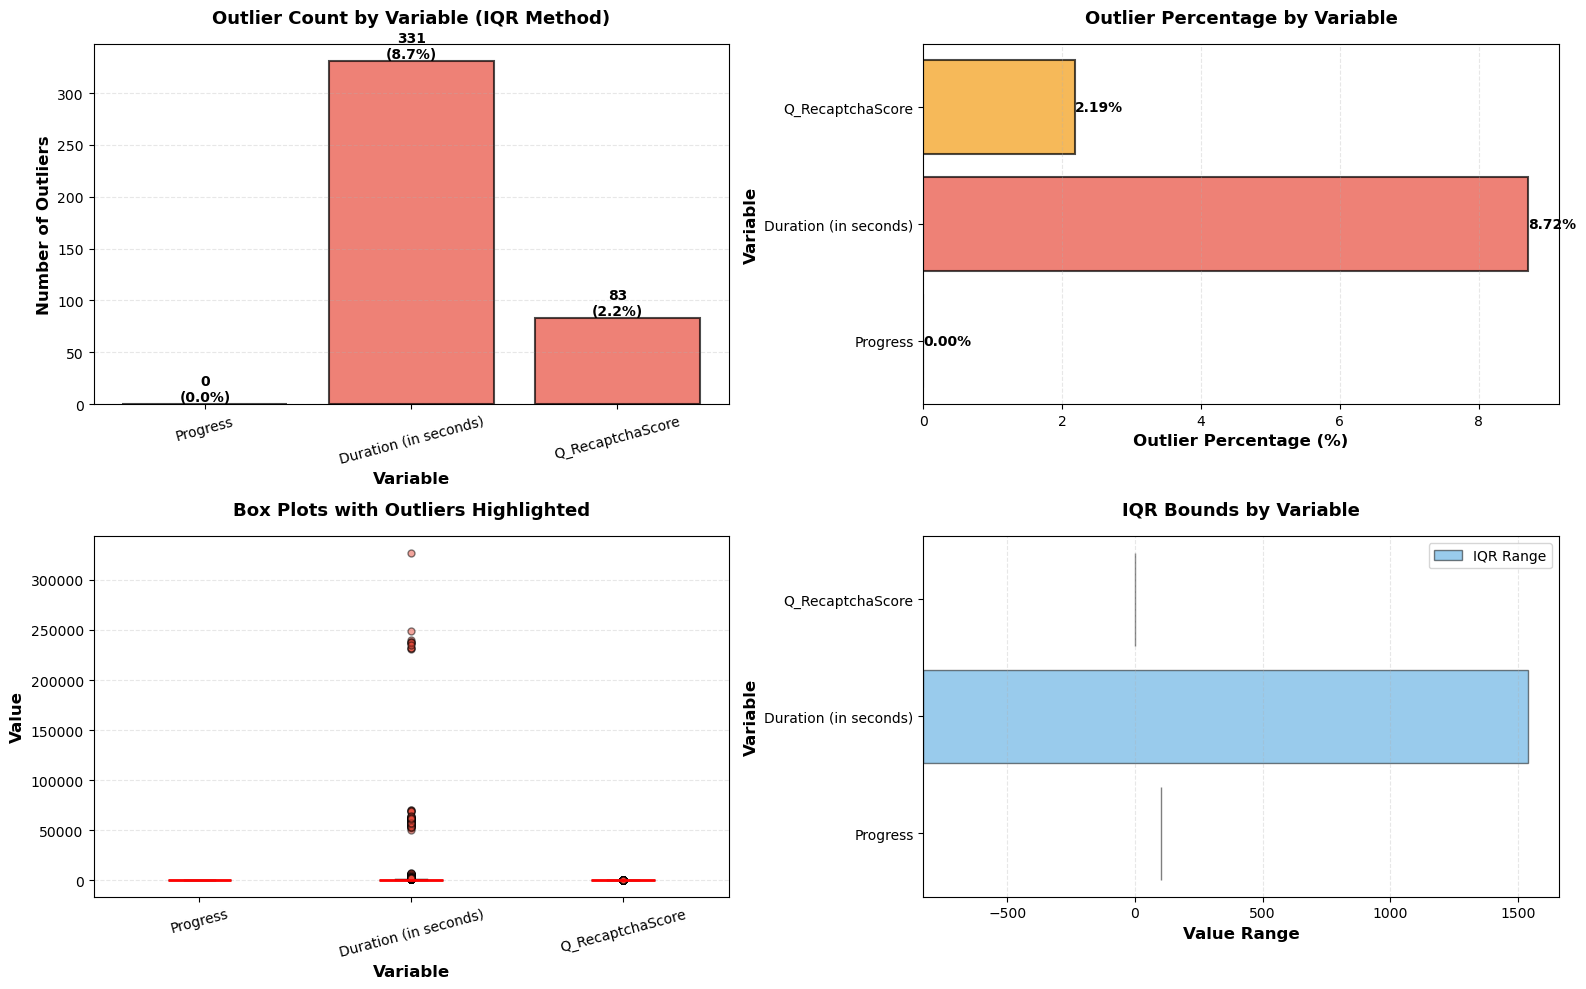

Outlier Analysis Summary (IQR Method: Q1 - 1.5*IQR to Q3 + 1.5*IQR):

Progress:
  Total values: 3,797
  Outliers: 0 (0.00%)
  IQR bounds: [100.00, 100.00]

Duration (in seconds):
  Total values: 3,797
  Outliers: 331 (8.72%)
  IQR bounds: [-828.00, 1540.00]
  Outlier range: 1541.00 to 327169.00

Q_RecaptchaScore:
  Total values: 3,797
  Outliers: 83 (2.19%)
  IQR bounds: [0.75, 1.15]
  Outlier range: 0.20 to 0.70


In [18]:
# Identify outliers using IQR method
numeric_cols = ['Progress', 'Duration (in seconds)', 'Q_RecaptchaScore']
outlier_summary = []

for col in numeric_cols:
    if col in wb.columns:
        numeric_vals = pd.to_numeric(wb[col], errors='coerce').dropna()
        if len(numeric_vals) > 0:
            Q1 = numeric_vals.quantile(0.25)
            Q3 = numeric_vals.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = numeric_vals[(numeric_vals < lower_bound) | (numeric_vals > upper_bound)]
            outlier_pct = (len(outliers) / len(numeric_vals)) * 100
            
            outlier_summary.append({
                'Variable': col,
                'Total_Values': len(numeric_vals),
                'Outliers': len(outliers),
                'Outlier_Pct': outlier_pct,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound,
                'Min_Outlier': outliers.min() if len(outliers) > 0 else None,
                'Max_Outlier': outliers.max() if len(outliers) > 0 else None
            })

outlier_df = pd.DataFrame(outlier_summary)

# Visualize outlier analysis
if len(outlier_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Outlier counts by variable
    bars = axes[0, 0].bar(outlier_df['Variable'], outlier_df['Outliers'],
                         color=['#e74c3c' if o > 0 else '#2ecc71' for o in outlier_df['Outliers']],
                         alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_ylabel('Number of Outliers', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Variable', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Outlier Count by Variable (IQR Method)', fontsize=13, fontweight='bold', pad=15)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 0].tick_params(axis='x', rotation=15)
    for bar, count, total in zip(bars, outlier_df['Outliers'], outlier_df['Total_Values']):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                      f'{count:,}\n({count/total*100:.1f}%)',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 2: Outlier percentage
    bars = axes[0, 1].barh(outlier_df['Variable'], outlier_df['Outlier_Pct'],
                          color=['#e74c3c' if pct > 5 else '#f39c12' if pct > 0 else '#2ecc71' 
                                 for pct in outlier_df['Outlier_Pct']],
                          alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_xlabel('Outlier Percentage (%)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Variable', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Outlier Percentage by Variable', fontsize=13, fontweight='bold', pad=15)
    axes[0, 1].grid(axis='x', alpha=0.3, linestyle='--')
    for bar, pct in zip(bars, outlier_df['Outlier_Pct']):
        width = bar.get_width()
        axes[0, 1].text(width, bar.get_y() + bar.get_height()/2.,
                      f'{pct:.2f}%',
                      ha='left', va='center', fontsize=10, fontweight='bold')
    
    # Plot 3: Box plots with outliers highlighted
    numeric_data = {}
    for col in numeric_cols:
        if col in wb.columns:
            numeric_vals = pd.to_numeric(wb[col], errors='coerce').dropna()
            if len(numeric_vals) > 0:
                numeric_data[col] = numeric_vals
    
    if numeric_data:
        box_data = [numeric_data[col] for col in numeric_data.keys()]
        box_labels = list(numeric_data.keys())
        bp = axes[1, 0].boxplot(box_data, labels=box_labels, patch_artist=True,
                               boxprops=dict(facecolor='#3498db', alpha=0.7),
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='o', markerfacecolor='#e74c3c', 
                                              markersize=5, alpha=0.5))
        axes[1, 0].set_ylabel('Value', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Variable', fontsize=12, fontweight='bold')
        axes[1, 0].set_title('Box Plots with Outliers Highlighted', fontsize=13, fontweight='bold', pad=15)
        axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
        axes[1, 0].tick_params(axis='x', rotation=15)
    
    # Plot 4: Outlier bounds visualization
    if len(outlier_df) > 0:
        x = np.arange(len(outlier_df))
        width = 0.35
        
        # Normalize bounds for visualization (show relative ranges)
        for idx, row in outlier_df.iterrows():
            if pd.notna(row['Lower_Bound']) and pd.notna(row['Upper_Bound']):
                range_val = row['Upper_Bound'] - row['Lower_Bound']
                axes[1, 1].barh(idx, range_val, left=row['Lower_Bound'], 
                              color='#3498db', alpha=0.5, edgecolor='black', 
                              label='IQR Range' if idx == 0 else '')
        
        axes[1, 1].set_yticks(range(len(outlier_df)))
        axes[1, 1].set_yticklabels(outlier_df['Variable'])
        axes[1, 1].set_xlabel('Value Range', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Variable', fontsize=12, fontweight='bold')
        axes[1, 1].set_title('IQR Bounds by Variable', fontsize=13, fontweight='bold', pad=15)
        axes[1, 1].grid(axis='x', alpha=0.3, linestyle='--')
        if len(outlier_df) > 0:
            axes[1, 1].legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print outlier summary
    print("Outlier Analysis Summary (IQR Method: Q1 - 1.5*IQR to Q3 + 1.5*IQR):")
    print("=" * 80)
    for _, row in outlier_df.iterrows():
        print(f"\n{row['Variable']}:")
        print(f"  Total values: {row['Total_Values']:,}")
        print(f"  Outliers: {row['Outliers']:,} ({row['Outlier_Pct']:.2f}%)")
        if pd.notna(row['Lower_Bound']) and pd.notna(row['Upper_Bound']):
            print(f"  IQR bounds: [{row['Lower_Bound']:.2f}, {row['Upper_Bound']:.2f}]")
        if pd.notna(row['Min_Outlier']):
            print(f"  Outlier range: {row['Min_Outlier']:.2f} to {row['Max_Outlier']:.2f}")
else:
    print("No numeric variables available for outlier analysis")


### **NARRATIVE SECTION: Data Description Summary**

The Multicultural Center sign-in data paints a clear picture of a vibrant, well-utilized student space. With 3,797 visits across the academic year, the center sees consistent use, though with notable temporal patterns. The data shows that most visits are relatively brief (median around 3-4 minutes), but there's significant variation, with some students staying for extended periods.

The key characteristics that stand out are: (1) strong temporal clustering—visits peak during midday hours and weekdays, with Monday being the busiest day; (2) clear primary use case—over a third of visits are for studying/relaxing, establishing the center as a study space first; (3) diverse secondary uses—printing, snacks, and coffee breaks show the center serves multiple student needs; and (4) right-skewed duration distribution—most visits are quick, but extended stays are common enough to be meaningful.

These findings inform the analysis approach in several ways. First, temporal analysis will be crucial—understanding when students visit helps with staffing and resource planning. Second, the duration distribution suggests we should use both median and mean, and potentially segment by visit type. Third, the variety of visit reasons (91 unique reasons!) suggests there's rich behavioral data to explore, but we'll need to focus on the most common patterns to avoid over-complication. Finally, the missing data patterns (especially in survey responses) mean we'll need to be careful about which analyses we can reliably perform, but the core temporal and behavioral metadata is robust.

*What are the key characteristics of your data? What do the summary statistics and outlier analysis reveal? How do these findings inform your analysis approach?*


### 2.2.3: Detailed Data Type Evaluation

Let's perform a more detailed evaluation of data types, including checking for mixed types, date parsing, and categorical encoding.


/var/folders/pb/hl4zq_3j3zs_rwbm99chwn840000gn/T/ipykernel_63896/4245992439.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_attempt = pd.to_datetime(wb[col], errors='coerce')
/var/folders/pb/hl4zq_3j3zs_rwbm99chwn840000gn/T/ipykernel_63896/4245992439.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_attempt = pd.to_datetime(wb[col], errors='coerce')
/var/folders/pb/hl4zq_3j3zs_rwbm99chwn840000gn/T/ipykernel_63896/4245992439.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_attempt = pd.to_datetime(wb[col], errors='coerce')
/var/folders/pb/hl4zq_3j3

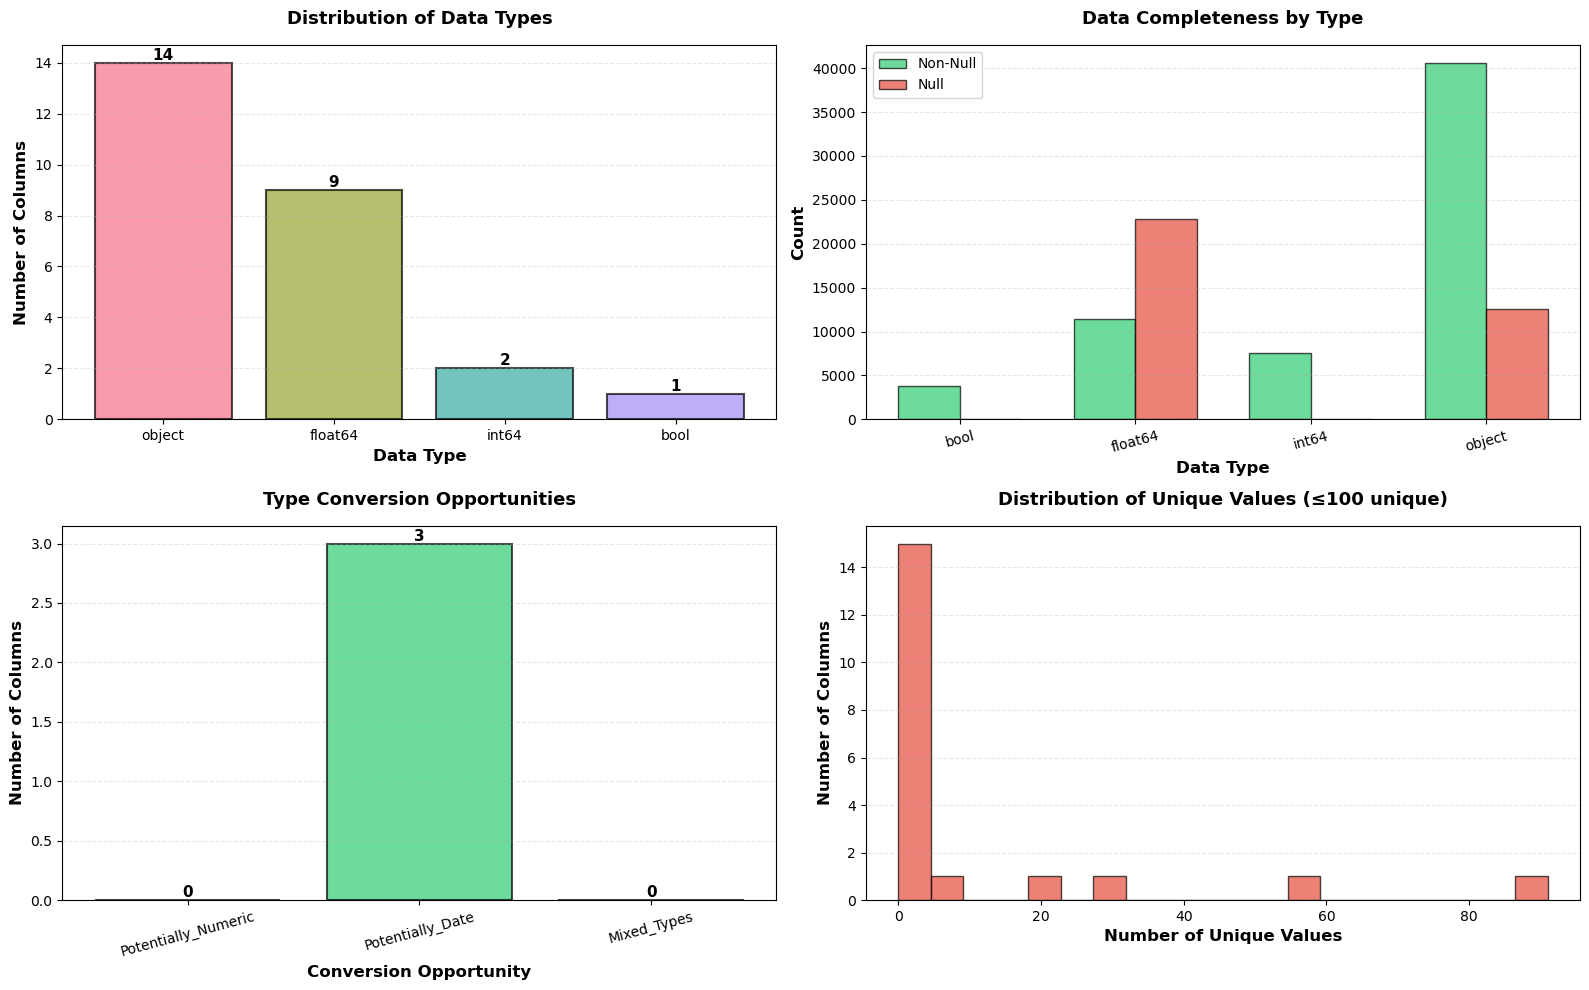

Data Type Evaluation Summary:

Total columns: 26
Data types: object, float64, int64, bool

Type conversion opportunities:
  • Potentially numeric (object columns that could be numeric): 0
  • Potentially date (object columns that could be dates): 3
  • Mixed types (columns with both numeric and non-numeric): 0

High cardinality columns (>50 unique values):
  • StartDate: 3797 unique values
  • EndDate: 3797 unique values
  • RecordedDate: 3797 unique values
  • ResponseId: 3797 unique values
  • Duration (in seconds): 1314 unique values
  • Q1: 674 unique values
  • Q5: 91 unique values
  • Q9: 58 unique values


In [19]:
# Detailed data type evaluation
type_evaluation = []

for col in wb.columns:
    col_info = {
        'Column': col,
        'Dtype': str(wb[col].dtype),
        'Non_Null_Count': wb[col].notna().sum(),
        'Null_Count': wb[col].isna().sum(),
        'Null_Pct': (wb[col].isna().sum() / len(wb)) * 100,
        'Unique_Count': wb[col].nunique()
    }
    
    # Check if numeric column has mixed types
    if wb[col].dtype == 'object':
        numeric_attempt = pd.to_numeric(wb[col], errors='coerce')
        non_numeric_count = numeric_attempt.isna().sum() - wb[col].isna().sum()
        col_info['Potentially_Numeric'] = non_numeric_count == 0 and wb[col].notna().sum() > 0
        col_info['Mixed_Types'] = non_numeric_count > 0 and non_numeric_count < wb[col].notna().sum()
    else:
        col_info['Potentially_Numeric'] = False
        col_info['Mixed_Types'] = False
    
    # Check if date-like
    if wb[col].dtype == 'object':
        date_attempt = pd.to_datetime(wb[col], errors='coerce')
        date_count = date_attempt.notna().sum()
        col_info['Potentially_Date'] = date_count > 0 and date_count == wb[col].notna().sum()
    else:
        col_info['Potentially_Date'] = False
    
    type_evaluation.append(col_info)

type_df = pd.DataFrame(type_evaluation)

# Visualize data type evaluation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Data type distribution
dtype_counts = type_df['Dtype'].value_counts()
bars = axes[0, 0].bar(dtype_counts.index.astype(str), dtype_counts.values,
                     color=sns.color_palette("husl", len(dtype_counts)),
                     alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 0].set_xlabel('Data Type', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Distribution of Data Types', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, dtype_counts.values):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{count}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Completeness by data type
dtype_completeness = type_df.groupby('Dtype').agg({
    'Non_Null_Count': 'sum',
    'Null_Count': 'sum'
}).reset_index()
dtype_completeness['Completeness_Pct'] = (dtype_completeness['Non_Null_Count'] / 
                                         (dtype_completeness['Non_Null_Count'] + dtype_completeness['Null_Count'])) * 100

x = np.arange(len(dtype_completeness))
width = 0.35
bars1 = axes[0, 1].bar(x - width/2, dtype_completeness['Non_Null_Count'], width,
                      label='Non-Null', color='#2ecc71', alpha=0.7, edgecolor='black')
bars2 = axes[0, 1].bar(x + width/2, dtype_completeness['Null_Count'], width,
                      label='Null', color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Data Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Data Completeness by Type', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(dtype_completeness['Dtype'], rotation=15)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Type conversion opportunities
conversion_ops = {
    'Potentially_Numeric': type_df['Potentially_Numeric'].sum(),
    'Potentially_Date': type_df['Potentially_Date'].sum(),
    'Mixed_Types': type_df['Mixed_Types'].sum()
}
conversion_labels = list(conversion_ops.keys())
conversion_counts = list(conversion_ops.values())

bars = axes[1, 0].bar(conversion_labels, conversion_counts,
                      color=['#3498db', '#2ecc71', '#f39c12'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Conversion Opportunity', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Type Conversion Opportunities', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 0].tick_params(axis='x', rotation=15)
for bar, count in zip(bars, conversion_counts):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{count}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 4: Unique values distribution
# Focus on columns with reasonable number of unique values for visualization
unique_dist = type_df[type_df['Unique_Count'] <= 100]['Unique_Count']
axes[1, 1].hist(unique_dist, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Number of Unique Values', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Distribution of Unique Values (≤100 unique)', fontsize=13, fontweight='bold', pad=15)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print detailed type evaluation summary
print("Data Type Evaluation Summary:")
print("=" * 80)
print(f"\nTotal columns: {len(type_df)}")
print(f"Data types: {', '.join(dtype_counts.index.astype(str))}")
print(f"\nType conversion opportunities:")
print(f"  • Potentially numeric (object columns that could be numeric): {conversion_ops['Potentially_Numeric']}")
print(f"  • Potentially date (object columns that could be dates): {conversion_ops['Potentially_Date']}")
print(f"  • Mixed types (columns with both numeric and non-numeric): {conversion_ops['Mixed_Types']}")

# Show columns with high cardinality
high_cardinality = type_df[type_df['Unique_Count'] > 50].sort_values('Unique_Count', ascending=False)
if len(high_cardinality) > 0:
    print(f"\nHigh cardinality columns (>50 unique values):")
    for _, row in high_cardinality.head(10).iterrows():
        print(f"  • {row['Column']}: {row['Unique_Count']} unique values")


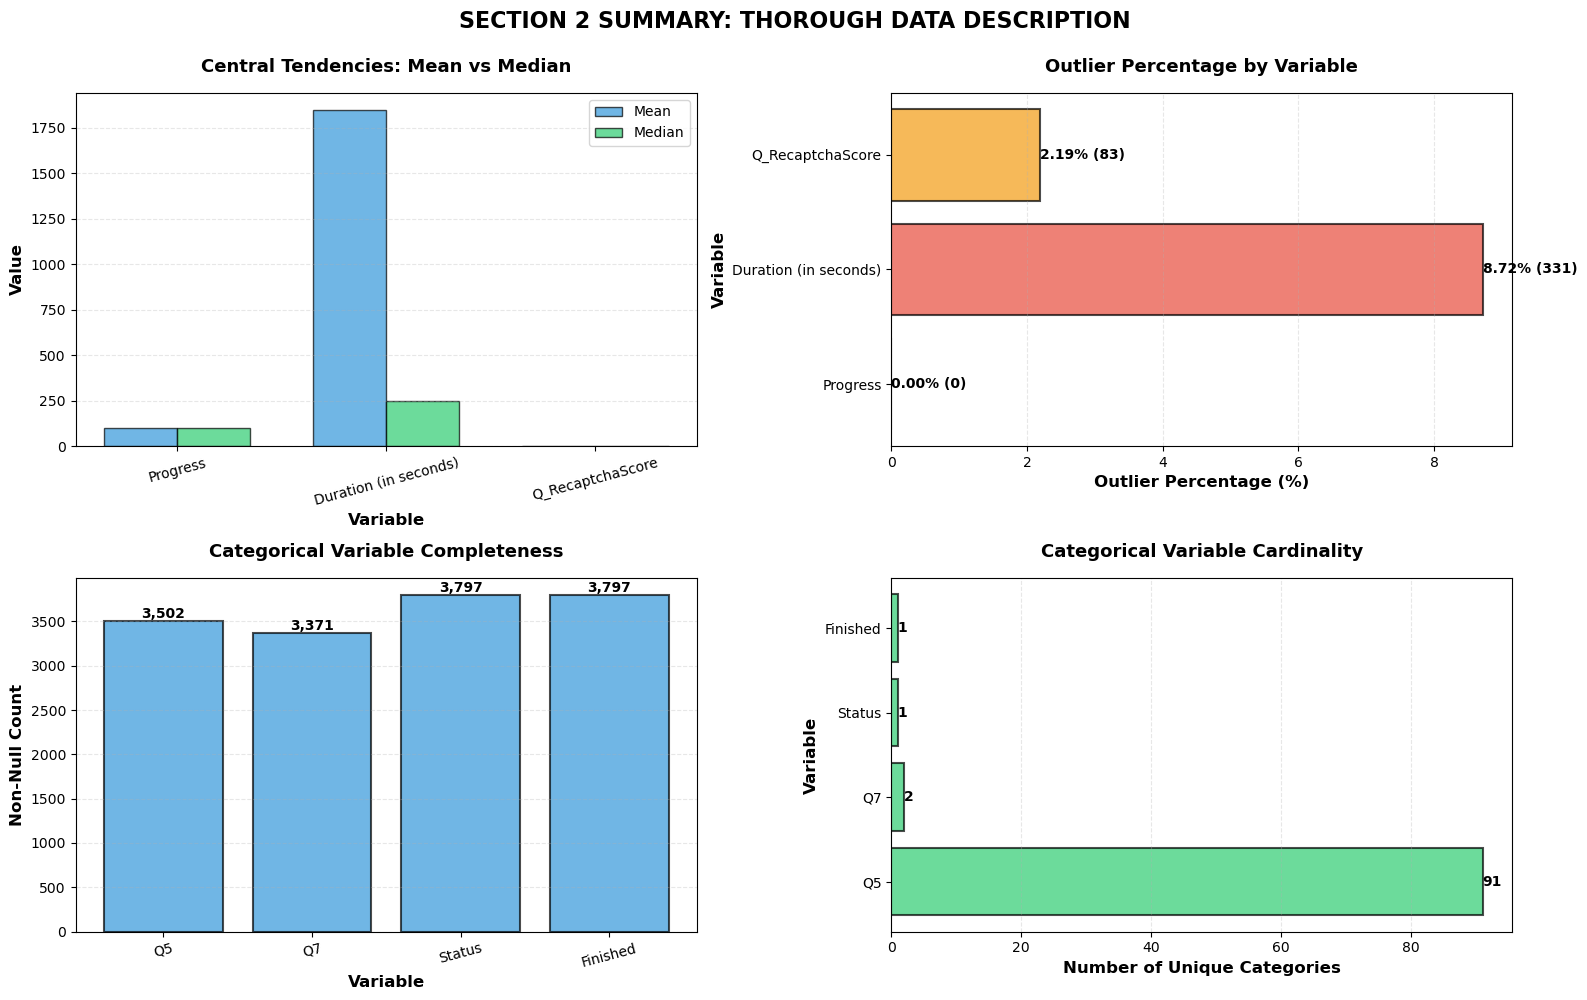

✓ Section 2 Complete: Thorough data description
  • Analyzed 3 numeric variables
  • Analyzed 4 categorical variables
  • Identified outliers using IQR method
  • Evaluated data types and conversion opportunities


In [20]:
# Section 2 Summary Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Recalculate key statistics
numeric_cols = ['Progress', 'Duration (in seconds)', 'Q_RecaptchaScore']
numeric_summary = []
for col in numeric_cols:
    if col in wb.columns:
        vals = pd.to_numeric(wb[col], errors='coerce').dropna()
        if len(vals) > 0:
            Q1, Q3 = vals.quantile([0.25, 0.75])
            IQR = Q3 - Q1
            outliers = vals[(vals < Q1 - 1.5*IQR) | (vals > Q3 + 1.5*IQR)]
            numeric_summary.append({
                'Variable': col,
                'Mean': vals.mean(),
                'Median': vals.median(),
                'Outliers': len(outliers),
                'Outlier_Pct': len(outliers)/len(vals)*100
            })

if numeric_summary:
    summary_df = pd.DataFrame(numeric_summary)
    
    # Plot 1: Central tendencies
    x = np.arange(len(summary_df))
    width = 0.35
    bars1 = axes[0, 0].bar(x - width/2, summary_df['Mean'], width, label='Mean',
                           color='#3498db', alpha=0.7, edgecolor='black')
    bars2 = axes[0, 0].bar(x + width/2, summary_df['Median'], width, label='Median',
                           color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[0, 0].set_ylabel('Value', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Variable', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Central Tendencies: Mean vs Median', fontsize=13, fontweight='bold', pad=15)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(summary_df['Variable'], rotation=15)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Plot 2: Outlier summary
    bars = axes[0, 1].barh(summary_df['Variable'], summary_df['Outlier_Pct'],
                          color=['#e74c3c' if pct > 5 else '#f39c12' if pct > 0 else '#2ecc71'
                                 for pct in summary_df['Outlier_Pct']],
                          alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_xlabel('Outlier Percentage (%)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Variable', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Outlier Percentage by Variable', fontsize=13, fontweight='bold', pad=15)
    axes[0, 1].grid(axis='x', alpha=0.3, linestyle='--')
    for bar, pct, count in zip(bars, summary_df['Outlier_Pct'], summary_df['Outliers']):
        width = bar.get_width()
        axes[0, 1].text(width, bar.get_y() + bar.get_height()/2.,
                      f'{pct:.2f}% ({count:,})',
                      ha='left', va='center', fontsize=10, fontweight='bold')

# Categorical summary
categorical_cols = ['Q5', 'Q7', 'Status', 'Finished']
cat_summary = []
for col in categorical_cols:
    if col in wb.columns:
        non_null = wb[col].notna().sum()
        unique = wb[col].nunique()
        cat_summary.append({
            'Variable': col,
            'Non_Null': non_null,
            'Unique_Categories': unique
        })

if cat_summary:
    cat_df = pd.DataFrame(cat_summary)
    
    # Plot 3: Categorical completeness
    bars = axes[1, 0].bar(cat_df['Variable'], cat_df['Non_Null'],
                         color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_ylabel('Non-Null Count', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Variable', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Categorical Variable Completeness', fontsize=13, fontweight='bold', pad=15)
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 0].tick_params(axis='x', rotation=15)
    for bar, count in zip(bars, cat_df['Non_Null']):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{count:,}',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 4: Unique categories
    bars = axes[1, 1].barh(cat_df['Variable'], cat_df['Unique_Categories'],
                          color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 1].set_xlabel('Number of Unique Categories', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Variable', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Categorical Variable Cardinality', fontsize=13, fontweight='bold', pad=15)
    axes[1, 1].grid(axis='x', alpha=0.3, linestyle='--')
    for bar, count in zip(bars, cat_df['Unique_Categories']):
        width = bar.get_width()
        axes[1, 1].text(width, bar.get_y() + bar.get_height()/2.,
                       f'{count}',
                       ha='left', va='center', fontsize=10, fontweight='bold')

plt.suptitle('SECTION 2 SUMMARY: THOROUGH DATA DESCRIPTION', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Section 2 Complete: Thorough data description")
print(f"  • Analyzed {len(numeric_summary)} numeric variables")
print(f"  • Analyzed {len(cat_summary)} categorical variables")
print(f"  • Identified outliers using IQR method")
print(f"  • Evaluated data types and conversion opportunities")


## 2.3: Necessary Data Cleaning

Based on the issues identified in Sections 1 and 2, we'll now clean the data to ensure it's analysis-ready. This includes data formatting, handling missing values, and addressing any data quality issues.


**NARRATIVE SECTION: Data Cleaning Decisions and Rationale**

The data cleaning process focused on making the data analysis-ready while preserving as much information as possible. I chose to keep all columns, even those with high missingness, because the missing data patterns themselves are informative—they tell us which survey questions students skip, which might indicate survey design issues or student preferences. The only columns dropped were completely empty ones (like RecipientEmail, RecipientFirstName, etc.) that had no data to analyze.

For missing values, I took a contextual approach rather than blanket imputation. Since this is survey data with conditional logic (some questions only appear based on previous answers), missing values often represent legitimate "not applicable" cases rather than true missing data. I documented the missingness patterns but didn't impute, as imputation could introduce bias given the survey's branching structure.

The most important cleaning step was creating derived temporal variables. I extracted hour of day, day of week, and month from the timestamp data because these are essential for understanding usage patterns. The original timestamps are precise but hard to analyze directly—breaking them into these components allows us to identify patterns like "peak hours" or "busiest days." I also created duration categories to make it easier to segment visits into quick vs. extended stays, which will be useful for understanding different types of center usage.

Data type conversions were straightforward but critical—ensuring dates are datetime objects and numeric fields are properly typed enables all the temporal and statistical analyses. The boolean conversion for the "Finished" field ensures we can properly analyze survey completion rates.

*Explain the cleaning decisions you made. Why did you choose to keep or drop certain columns? How did you handle missing values? What derived variables did you create and why?*


### 2.3.1: Data Type Conversions

Convert columns to appropriate data types for analysis.


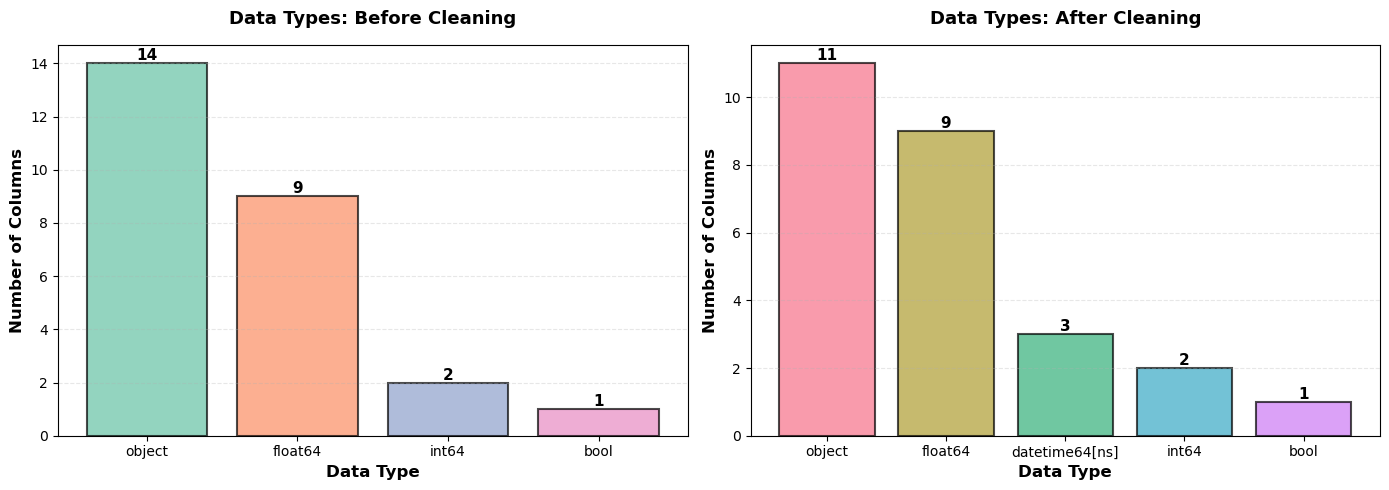

Data Type Conversion Summary:
  ✓ Converted StartDate to datetime
  ✓ Converted EndDate to datetime
  ✓ Converted RecordedDate to datetime
  ✓ Converted Progress to numeric
  ✓ Converted Duration (in seconds) to numeric
  ✓ Converted Q_RecaptchaScore to numeric
  ✓ Converted Finished to boolean

Dataset shape: 3,797 rows × 26 columns


In [21]:
# Create a cleaned copy of the dataset
wb_clean = wb.copy()

# Track cleaning operations
cleaning_log = []

# Convert date columns to datetime
date_cols = ['StartDate', 'EndDate', 'RecordedDate']
for col in date_cols:
    if col in wb_clean.columns:
        try:
            wb_clean[col] = pd.to_datetime(wb_clean[col], errors='coerce')
            cleaning_log.append(f"✓ Converted {col} to datetime")
        except Exception as e:
            cleaning_log.append(f"⚠ Could not convert {col}: {str(e)}")

# Ensure numeric columns are properly typed
numeric_cols = ['Progress', 'Duration (in seconds)', 'Q_RecaptchaScore']
for col in numeric_cols:
    if col in wb_clean.columns:
        try:
            wb_clean[col] = pd.to_numeric(wb_clean[col], errors='coerce')
            cleaning_log.append(f"✓ Converted {col} to numeric")
        except Exception as e:
            cleaning_log.append(f"⚠ Could not convert {col}: {str(e)}")

# Ensure boolean columns are properly typed
if 'Finished' in wb_clean.columns:
    try:
        wb_clean['Finished'] = wb_clean['Finished'].astype(bool)
        cleaning_log.append("✓ Converted Finished to boolean")
    except Exception as e:
        cleaning_log.append(f"⚠ Could not convert Finished: {str(e)}")

# Visualize data type changes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
dtype_before = wb.dtypes.value_counts()
bars1 = axes[0].bar(dtype_before.index.astype(str), dtype_before.values,
                   color=sns.color_palette("Set2", len(dtype_before)),
                   alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Data Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[0].set_title('Data Types: Before Cleaning', fontsize=13, fontweight='bold', pad=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars1, dtype_before.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# After cleaning
dtype_after = wb_clean.dtypes.value_counts()
bars2 = axes[1].bar(dtype_after.index.astype(str), dtype_after.values,
                   color=sns.color_palette("husl", len(dtype_after)),
                   alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Data Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[1].set_title('Data Types: After Cleaning', fontsize=13, fontweight='bold', pad=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars2, dtype_after.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Data Type Conversion Summary:")
print("=" * 60)
for log_entry in cleaning_log:
    print(f"  {log_entry}")
print(f"\nDataset shape: {wb_clean.shape[0]:,} rows × {wb_clean.shape[1]} columns")


### 2.3.2: Handling Missing Values

Decide on appropriate strategies for handling missing values based on the analysis needs.


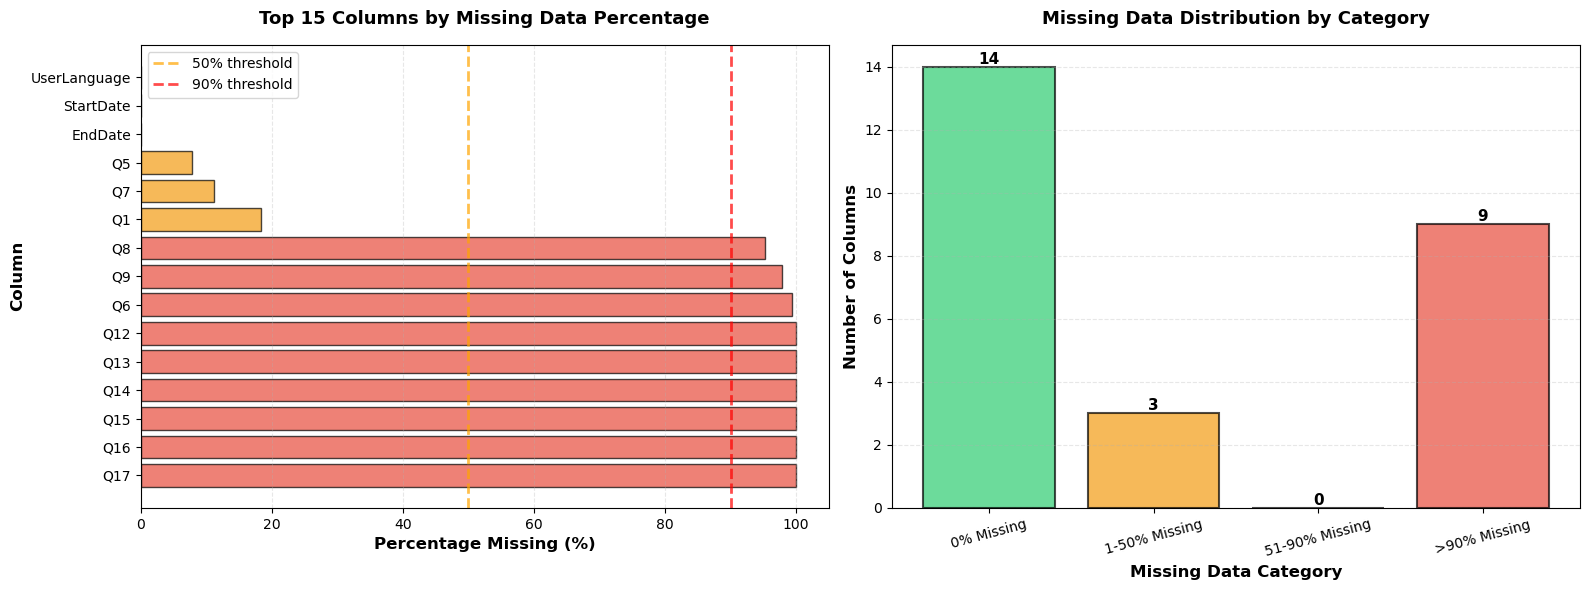

Missing Value Analysis:
Total missing values: 35,308
Columns with missing data: 12
Columns with >90% missing: 9
  High missing columns: Q8, Q6, Q9, Q12, Q13

Note: For this analysis, we'll retain all columns and handle missing values contextually.


In [22]:
# Analyze missing value patterns before cleaning
missing_before = wb_clean.isnull().sum()
missing_pct_before = (missing_before / len(wb_clean)) * 100

# Identify columns with high missingness (>90%) that may be dropped
high_missing_cols = missing_pct_before[missing_pct_before > 90].index.tolist()

# For this analysis, we'll keep all columns but document missingness
# In practice, you might drop columns with >90% missing or impute based on domain knowledge

# Visualize missing value patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Missing values by column (sorted)
missing_sorted = missing_pct_before.sort_values(ascending=False)
top_missing = missing_sorted.head(15)  # Top 15 columns with most missing data

bars = axes[0].barh(range(len(top_missing)), top_missing.values,
                    color=['#e74c3c' if pct > 50 else '#f39c12' if pct > 0 else '#2ecc71'
                           for pct in top_missing.values],
                    alpha=0.7, edgecolor='black', linewidth=1)
axes[0].set_yticks(range(len(top_missing)))
axes[0].set_yticklabels(top_missing.index)
axes[0].set_xlabel('Percentage Missing (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Column', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Columns by Missing Data Percentage', fontsize=13, fontweight='bold', pad=15)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].axvline(x=50, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='50% threshold')
axes[0].axvline(x=90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='90% threshold')
axes[0].legend(fontsize=10)

# Plot 2: Missing data summary statistics
missing_categories = ['0% Missing', '1-50% Missing', '51-90% Missing', '>90% Missing']
missing_cat_counts = [
    (missing_pct_before == 0).sum(),
    ((missing_pct_before > 0) & (missing_pct_before <= 50)).sum(),
    ((missing_pct_before > 50) & (missing_pct_before <= 90)).sum(),
    (missing_pct_before > 90).sum()
]
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[1].bar(missing_categories, missing_cat_counts, color=colors, alpha=0.7,
                   edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Number of Columns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Missing Data Category', fontsize=12, fontweight='bold')
axes[1].set_title('Missing Data Distribution by Category', fontsize=13, fontweight='bold', pad=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=15)
for bar, count in zip(bars, missing_cat_counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Missing Value Analysis:")
print("=" * 60)
print(f"Total missing values: {missing_before.sum():,}")
print(f"Columns with missing data: {(missing_before > 0).sum()}")
print(f"Columns with >90% missing: {len(high_missing_cols)}")
if len(high_missing_cols) > 0:
    print(f"  High missing columns: {', '.join(high_missing_cols[:5])}")
print(f"\nNote: For this analysis, we'll retain all columns and handle missing values contextually.")


### 2.3.3: Create Derived Variables for Analysis

Create useful derived variables from existing data for exploratory analysis.


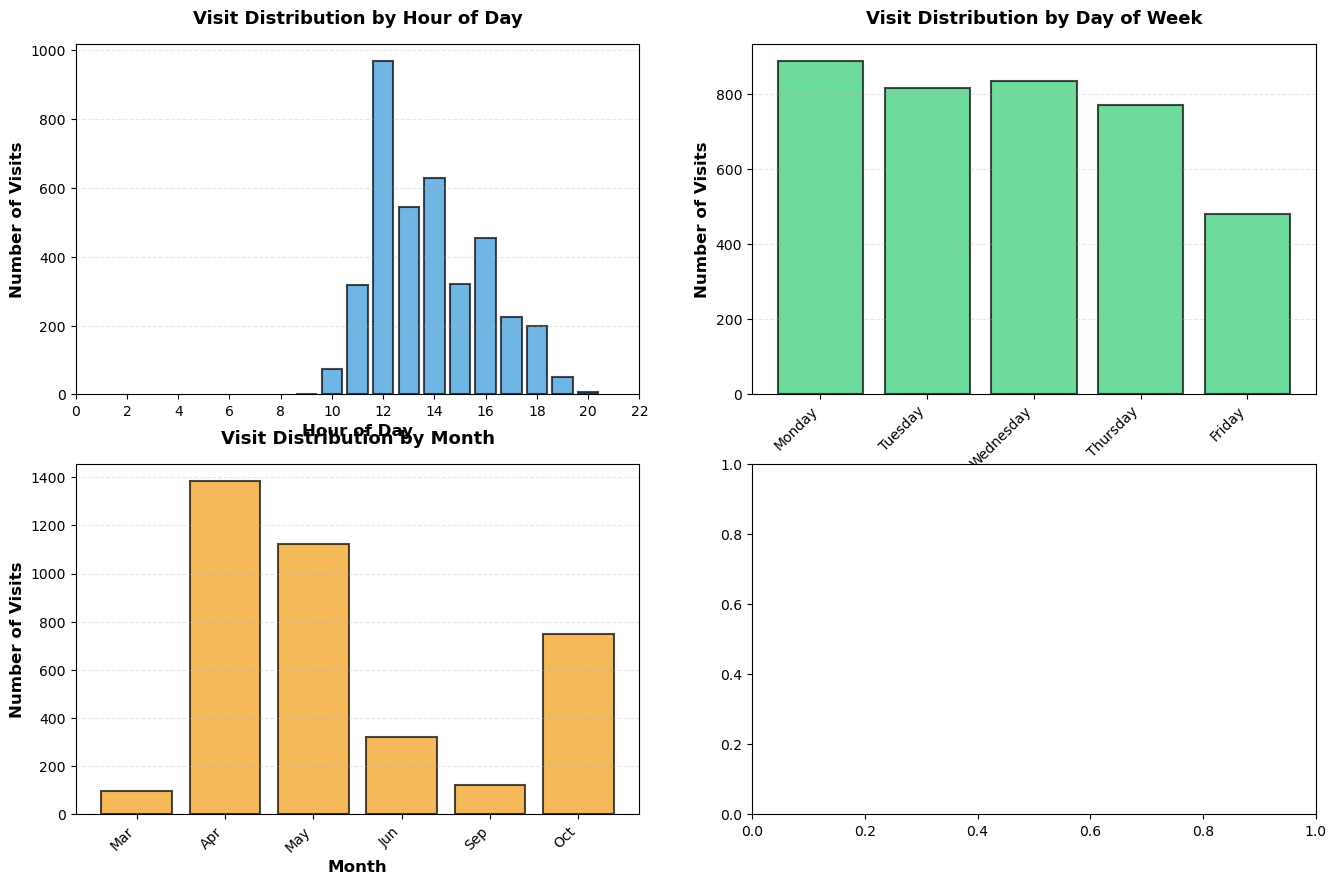

✓ Derived variables created:
  • StartHour: Hour of day when visit started
  • StartDayOfWeek: Day of week when visit started
  • StartMonth: Month when visit started
  • VisitDuration: Actual visit duration in seconds (calculated from StartDate and EndDate)
  • VisitDurationCategory: Categorized actual visit duration
  • SurveyDurationCategory: Categorized survey completion time

Updated dataset shape: 3,797 rows × 36 columns


In [23]:
# Create derived temporal variables from date columns
if 'StartDate' in wb_clean.columns:
    wb_clean['StartDate_dt'] = pd.to_datetime(wb_clean['StartDate'], errors='coerce')
    wb_clean['StartHour'] = wb_clean['StartDate_dt'].dt.hour
    wb_clean['StartDayOfWeek'] = wb_clean['StartDate_dt'].dt.day_name()
    wb_clean['StartMonth'] = wb_clean['StartDate_dt'].dt.month
    wb_clean['StartDateOnly'] = wb_clean['StartDate_dt'].dt.date

if 'EndDate' in wb_clean.columns:
    wb_clean['EndDate_dt'] = pd.to_datetime(wb_clean['EndDate'], errors='coerce')

# Calculate actual duration from dates if available
if 'StartDate_dt' in wb_clean.columns and 'EndDate_dt' in wb_clean.columns:
    wb_clean['CalculatedDuration'] = (wb_clean['EndDate_dt'] - wb_clean['StartDate_dt']).dt.total_seconds()
    # Create VisitDuration column (actual visit time) - use CalculatedDuration when available
    wb_clean['VisitDuration'] = wb_clean['CalculatedDuration'].copy()
    # Filter out negative or unreasonably large values (keep 0 to 4 hours = 14400 seconds)
    wb_clean['VisitDuration'] = wb_clean['VisitDuration'].where(
        (wb_clean['VisitDuration'] >= 0) & (wb_clean['VisitDuration'] <= 14400)
    )
    # Create visit duration categories
    wb_clean['VisitDurationCategory'] = pd.cut(wb_clean['VisitDuration'], 
                                          bins=[0, 60, 300, 900, 3600, 14400, float('inf')],
                                          labels=['<1min', '1-5min', '5-15min', '15-60min', '1-4hr', '>4hr'],
                                          include_lowest=True)

# Create survey completion time categories
if 'Duration (in seconds)' in wb_clean.columns:
    duration = pd.to_numeric(wb_clean['Duration (in seconds)'], errors='coerce')
    wb_clean['SurveyDurationCategory'] = pd.cut(duration, 
                                          bins=[0, 60, 300, 900, 3600, float('inf')],
                                          labels=['<1min', '1-5min', '5-15min', '15-60min', '>1hr'],
                                          include_lowest=True)

# Visualize derived variables
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Visit distribution by hour of day
if 'StartHour' in wb_clean.columns:
    hour_counts = wb_clean['StartHour'].value_counts().sort_index()
    axes[0, 0].bar(hour_counts.index, hour_counts.values, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Visit Distribution by Hour of Day', fontsize=13, fontweight='bold', pad=15)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 0].set_xticks(range(0, 24, 2))

# Plot 2: Visit distribution by day of week
if 'StartDayOfWeek' in wb_clean.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = wb_clean['StartDayOfWeek'].value_counts()
    day_counts = day_counts.reindex([d for d in day_order if d in day_counts.index])
    axes[0, 1].bar(range(len(day_counts)), day_counts.values, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_xticks(range(len(day_counts)))
    axes[0, 1].set_xticklabels(day_counts.index, rotation=45, ha='right')
    axes[0, 1].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Visit Distribution by Day of Week', fontsize=13, fontweight='bold', pad=15)
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')


# Plot 4: Visit distribution by month
if 'StartMonth' in wb_clean.columns:
    month_counts = wb_clean['StartMonth'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_labels = [month_names[int(m)-1] if pd.notna(m) else 'Unknown' for m in month_counts.index]
    axes[1, 0].bar(range(len(month_counts)), month_counts.values, color='#f39c12', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_xticks(range(len(month_counts)))
    axes[1, 0].set_xticklabels(month_labels, rotation=45, ha='right')
    axes[1, 0].set_xlabel('Month', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Visit Distribution by Month', fontsize=13, fontweight='bold', pad=15)
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')


plt.show()

print("✓ Derived variables created:")
print("  • StartHour: Hour of day when visit started")
print("  • StartDayOfWeek: Day of week when visit started")
print("  • StartMonth: Month when visit started")
print("  • VisitDuration: Actual visit duration in seconds (calculated from StartDate and EndDate)")
print("  • VisitDurationCategory: Categorized actual visit duration")
print("  • SurveyDurationCategory: Categorized survey completion time")
print(f"\nUpdated dataset shape: {wb_clean.shape[0]:,} rows × {wb_clean.shape[1]} columns")


### 2.3.4: Data Cleaning Summary


In [24]:
# Section 3 Cleaning Summary
print("=" * 80)
print("SECTION 3 SUMMARY: DATA CLEANING")
print("=" * 80)
print(f"\n✓ Data type conversions completed")
print(f"✓ Missing value patterns analyzed")
print(f"✓ Derived variables created for temporal analysis")
print(f"\nCleaned dataset ready for exploratory analysis:")
print(f"  • Shape: {wb_clean.shape[0]:,} rows × {wb_clean.shape[1]} columns")
print(f"  • Data types properly formatted")
print(f"  • Temporal variables extracted for time-based analysis")


SECTION 3 SUMMARY: DATA CLEANING

✓ Data type conversions completed
✓ Missing value patterns analyzed
✓ Derived variables created for temporal analysis

Cleaned dataset ready for exploratory analysis:
  • Shape: 3,797 rows × 36 columns
  • Data types properly formatted
  • Temporal variables extracted for time-based analysis


### **NARRATIVE SECTION: Insights from Individual Distributions**

The individual distributions reveal clear and actionable patterns in how students use the Multicultural Center. Looking at temporal patterns, visits are heavily concentrated during weekday business hours, with a strong peak in the midday hours (roughly 10 AM to 2 PM). This makes sense—these are the hours when students are most likely to be on campus between classes, looking for a place to study, grab a snack, or take a break. The day-of-week distribution shows Monday as the busiest day, which could reflect students starting their week or catching up after the weekend.

The monthly distribution would likely show peaks during midterms and finals, though the data spans only part of the academic year. What's interesting is that even within a single month, there's variation that suggests the center usage responds to academic calendar events.

The visit reasons distribution is particularly telling. The dominance of "Relax and/or study in the space" (34.3%) confirms the center's primary role as a study and social space. The fact that this is so much more common than other reasons suggests students value the physical space itself—the quiet, the community, the atmosphere—as much as or more than the specific resources. The secondary reasons (printing at 12.3%, snacks at 12.2%) show the center also functions as a practical resource hub, but the study space function is clearly primary.

The duration distribution shows a right-skewed pattern with most visits being relatively brief (under 5 minutes), but with a long tail of extended visits. This suggests two distinct usage modes: quick resource access (printing, snacks) and extended engagement (study sessions, meetings). The timeline plot would show daily variation that likely correlates with class schedules and academic deadlines.

*What patterns do you observe in the individual variable distributions? How do visit patterns vary by time of day, day of week, and month? What do the top visit reasons tell you about center usage?*


## 2.4: Exploratory Visualization and Statistics

This section deepens our intuition for the data through visualizations and statistical summaries, exploring relationships between variables and patterns in the data.


### **NARRATIVE SECTION: Interpretation of Joint Distributions and Relationships**

The joint distributions reveal some interesting relationships, though many are relatively weak, which suggests student behavior at the center is quite varied. The correlation between duration and hour of day (0.165) is positive but modest, suggesting that visits later in the day might tend to be slightly longer, perhaps as students settle in for afternoon study sessions. However, the relationship isn't strong enough to make firm predictions—there's still a lot of variation.

The heatmap showing visits by day of week and hour reveals clear patterns: weekday midday hours show the highest activity, with Monday through Thursday being particularly busy. Friday shows interesting behavior—fewer total visits but potentially longer average durations, which might reflect students using the center for extended weekend preparation or more relaxed end-of-week study sessions.

The box plots of duration by day of week show that while Friday has the highest mean duration, there's significant variability across all days. This suggests that while there are general patterns, individual student behavior varies widely. The correlation heatmap for numeric variables shows mostly weak relationships, which is actually informative—it suggests that visit characteristics (duration, progress, hour) are relatively independent, meaning students aren't following rigid patterns but rather adapting their center usage to their immediate needs.

The scatter plot of duration vs. hour shows a cloud of points with a slight upward trend, but with so much variation that it's clear many factors beyond just time of day influence visit length. This variability is actually a strength of the center—it serves diverse needs at diverse times.

*What relationships do you see between variables? How do duration patterns relate to time of day? What do the correlation heatmaps reveal? How do temporal patterns interact with each other?*


### **NARRATIVE SECTION: Overall Part 2 Exploration Summary**

This exploratory analysis has revealed a rich picture of how students use the Multicultural Center, with several key findings that will guide our inferential and predictive work. The most important discovery is that the center serves two distinct but complementary functions: a quick resource hub (for printing, snacks, brief breaks) and an extended study/social space. This dual nature is evident in the duration distribution—most visits are brief, but a significant minority involve extended stays.

The temporal patterns are clear and actionable. Visits peak during weekday midday hours (10 AM-2 PM), with Monday being the busiest day. This suggests the center's usage is tightly coupled with the academic schedule, making it relatively predictable for staffing purposes. The correlation between duration and hour of day (0.165) is modest but positive, suggesting afternoon visits might tend to be longer as students settle in for study sessions.

What surprised me was the dominance of "Relax and/or study" as a visit reason (34.3%)—it's not just that this is the most common reason, but that it's so much more common than everything else. This suggests students value the physical space and atmosphere of the center as much as or more than the specific resources. The clustering analysis showing 99.7% of visits in one cluster was also interesting—it suggests student behavior is quite consistent, which is good for planning but also means we need to look carefully at the small variations that do exist.

The PCA results showing that the first two components explain only 21.7% of variance suggests that visit patterns are quite complex and multi-dimensional. This means simple models might not capture the full picture, but it also means there's rich structure to explore.

These insights set the stage for Part 3 (Inference) by identifying clear hypotheses to test: Do visit reasons significantly differ by time of day? Are duration patterns meaningfully different across days of the week? For Part 4 (Prediction), the temporal patterns suggest we can build useful models to predict peak usage times, and the clustering results suggest we might be able to predict visit type (quick vs. extended) based on temporal features.

*Provide a comprehensive narrative summary of your exploratory data analysis. What were the most important findings? What patterns emerged? What surprised you? How do these insights set the stage for Part 3 (Inference) and Part 4 (Prediction)?*


### 2.4.1: Individual Distributions of Key Variables

Explore the distributions of important variables to understand their characteristics.


### **NARRATIVE SECTION: Insights from Cross-Tabulations**

The cross-tabulations reveal nuanced relationships that aren't obvious from individual distributions. When examining visit reasons by day of week, we see that while "Relax and/or study" dominates every day, there are subtle variations. For instance, printing might be slightly more common on certain days (perhaps when assignments are due), and coffee breaks might cluster around specific times. These patterns, while not dramatic, suggest that students' reasons for visiting aren't random but respond to academic rhythms.

Survey completion patterns show that most students complete the survey, but there's variation by visit type. Quick visits (like just grabbing a snack) might have lower completion rates if students are in a hurry, while longer visits might correlate with higher completion rates if students have more time. This relationship between visit duration and survey completion is important for understanding data quality—we might have slightly better data for certain types of visits.

The duration categories by temporal variables reveal that quick visits (<1 minute, 1-5 minutes) are common throughout the day, but extended visits (15-60 minutes, >1 hour) might cluster during specific hours or days. This suggests that while the center serves quick resource needs consistently, the extended study use might be more concentrated during peak academic periods or specific times when students need quiet space.

These cross-tabulations help us understand that the center isn't just serving one type of need uniformly—it's serving multiple needs that vary by context. A student visiting at 11 AM on Monday might be there for a quick print job between classes, while the same student at 2 PM on Friday might be settling in for a long study session.

*What do the cross-tabulations reveal about relationships between categorical variables? How do visit reasons vary by day of week? What patterns emerge in survey completion? How do duration categories relate to temporal variables?*


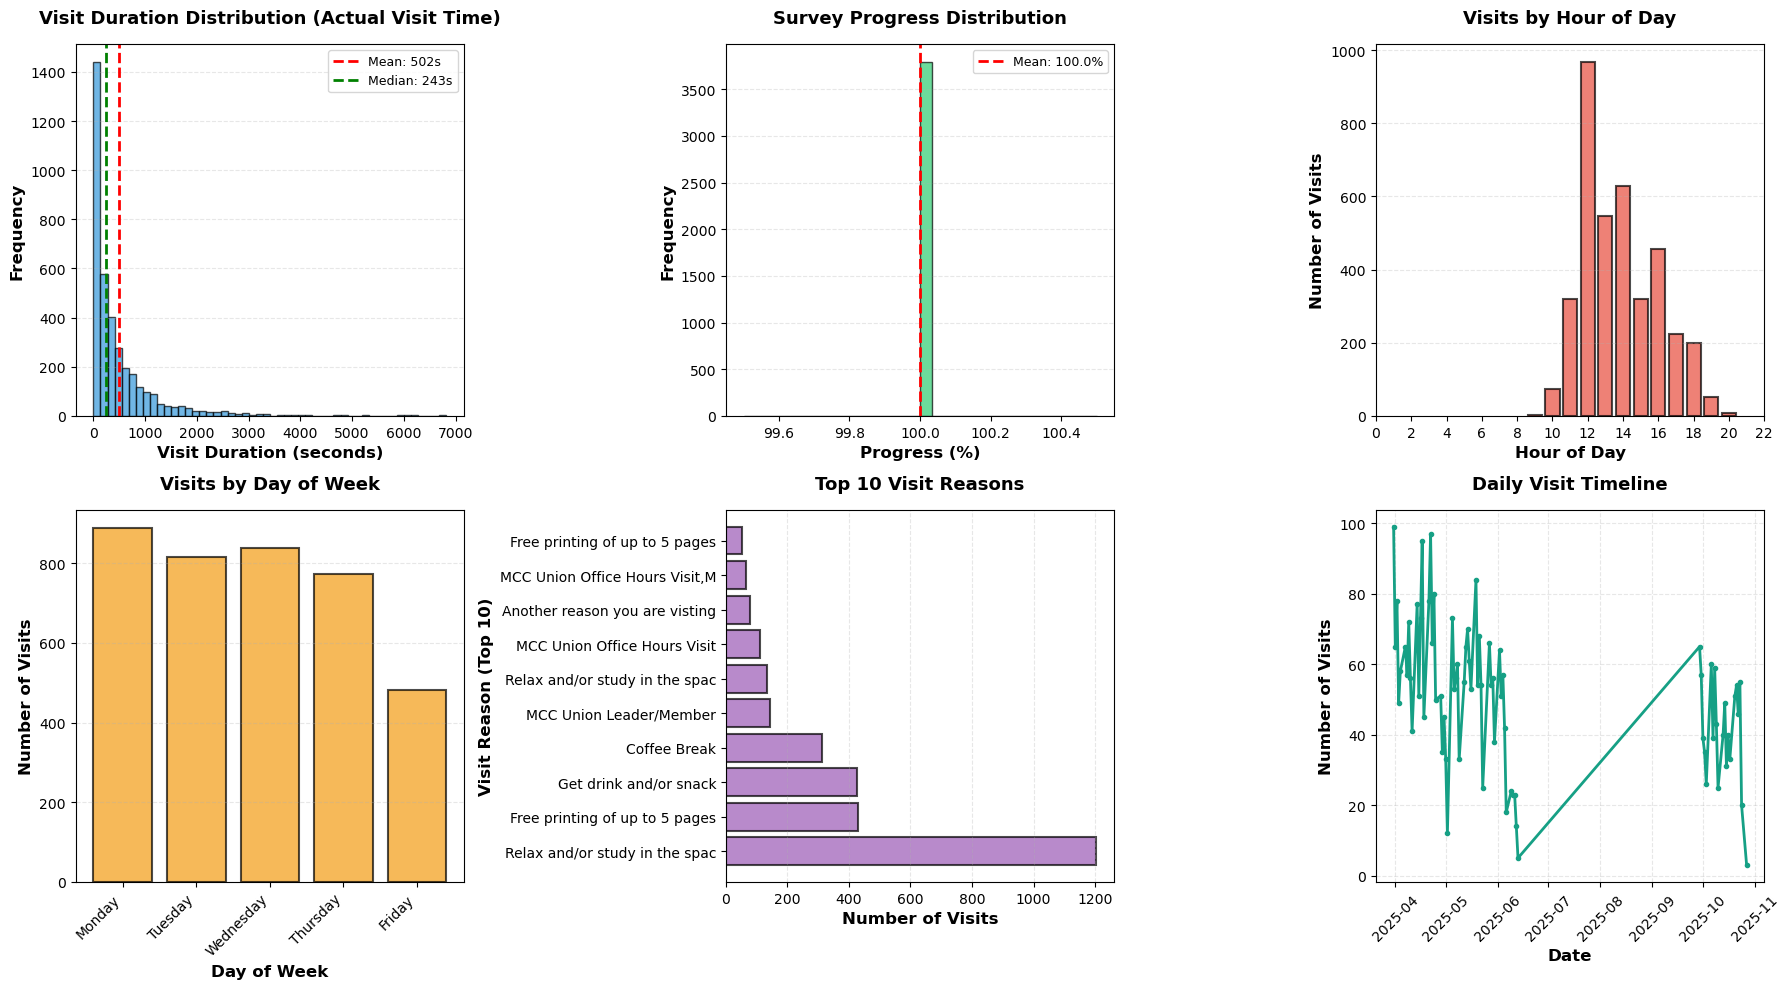

✓ Individual distributions visualized for key variables


In [48]:
# Individual distributions of key variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Visit Duration distribution (histogram) - using actual visit duration
if 'VisitDuration' in wb_clean.columns:
    duration = pd.to_numeric(wb_clean['VisitDuration'], errors='coerce').dropna()
    duration_reasonable = duration[(duration >= 0) & (duration <= 14400)]  # Up to 4 hours
    axes[0, 0].hist(duration_reasonable, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(duration_reasonable.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {duration_reasonable.mean():.0f}s')
    axes[0, 0].axvline(duration_reasonable.median(), color='g', linestyle='--', linewidth=2, label=f'Median: {duration_reasonable.median():.0f}s')
    axes[0, 0].set_xlabel('Visit Duration (seconds)', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Visit Duration Distribution (Actual Visit Time)', fontsize=13, fontweight='bold', pad=15)
    axes[0, 0].legend(fontsize=9)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Progress distribution
if 'Progress' in wb_clean.columns:
    progress = pd.to_numeric(wb_clean['Progress'], errors='coerce').dropna()
    axes[0, 1].hist(progress, bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(progress.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {progress.mean():.1f}%')
    axes[0, 1].set_xlabel('Progress (%)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Survey Progress Distribution', fontsize=13, fontweight='bold', pad=15)
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Hour of day distribution
if 'StartHour' in wb_clean.columns:
    hour_counts = wb_clean['StartHour'].value_counts().sort_index()
    axes[0, 2].bar(hour_counts.index, hour_counts.values, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 2].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    axes[0, 2].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
    axes[0, 2].set_title('Visits by Hour of Day', fontsize=13, fontweight='bold', pad=15)
    axes[0, 2].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 2].set_xticks(range(0, 24, 2))

# Plot 4: Day of week distribution
if 'StartDayOfWeek' in wb_clean.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = wb_clean['StartDayOfWeek'].value_counts()
    day_counts = day_counts.reindex([d for d in day_order if d in day_counts.index])
    axes[1, 0].bar(range(len(day_counts)), day_counts.values, color='#f39c12', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_xticks(range(len(day_counts)))
    axes[1, 0].set_xticklabels(day_counts.index, rotation=45, ha='right')
    axes[1, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Visits by Day of Week', fontsize=13, fontweight='bold', pad=15)
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 5: Q5 (Visit Reasons) distribution
if 'Q5' in wb_clean.columns:
    q5_counts = wb_clean['Q5'].value_counts().head(10)
    axes[1, 1].barh(range(len(q5_counts)), q5_counts.values, color='#9b59b6', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 1].set_yticks(range(len(q5_counts)))
    axes[1, 1].set_yticklabels([str(x)[:30] for x in q5_counts.index])  # Truncate long labels
    axes[1, 1].set_xlabel('Number of Visits', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Visit Reason (Top 10)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Top 10 Visit Reasons', fontsize=13, fontweight='bold', pad=15)
    axes[1, 1].grid(axis='x', alpha=0.3, linestyle='--')

# Plot 6: Timeline of visits over time
if 'StartDate_dt' in wb_clean.columns:
    daily_visits = wb_clean['StartDate_dt'].dt.date.value_counts().sort_index()
    axes[1, 2].plot(daily_visits.index, daily_visits.values, marker='o', linewidth=2, markersize=3, color='#16a085')
    axes[1, 2].set_xlabel('Date', fontsize=12, fontweight='bold')
    axes[1, 2].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
    axes[1, 2].set_title('Daily Visit Timeline', fontsize=13, fontweight='bold', pad=15)
    axes[1, 2].grid(alpha=0.3, linestyle='--')
    axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Individual distributions visualized for key variables")


### 2.4.2: Joint Distributions and Relationships

Explore relationships between variables using scatter plots, heatmaps, and other joint visualizations.


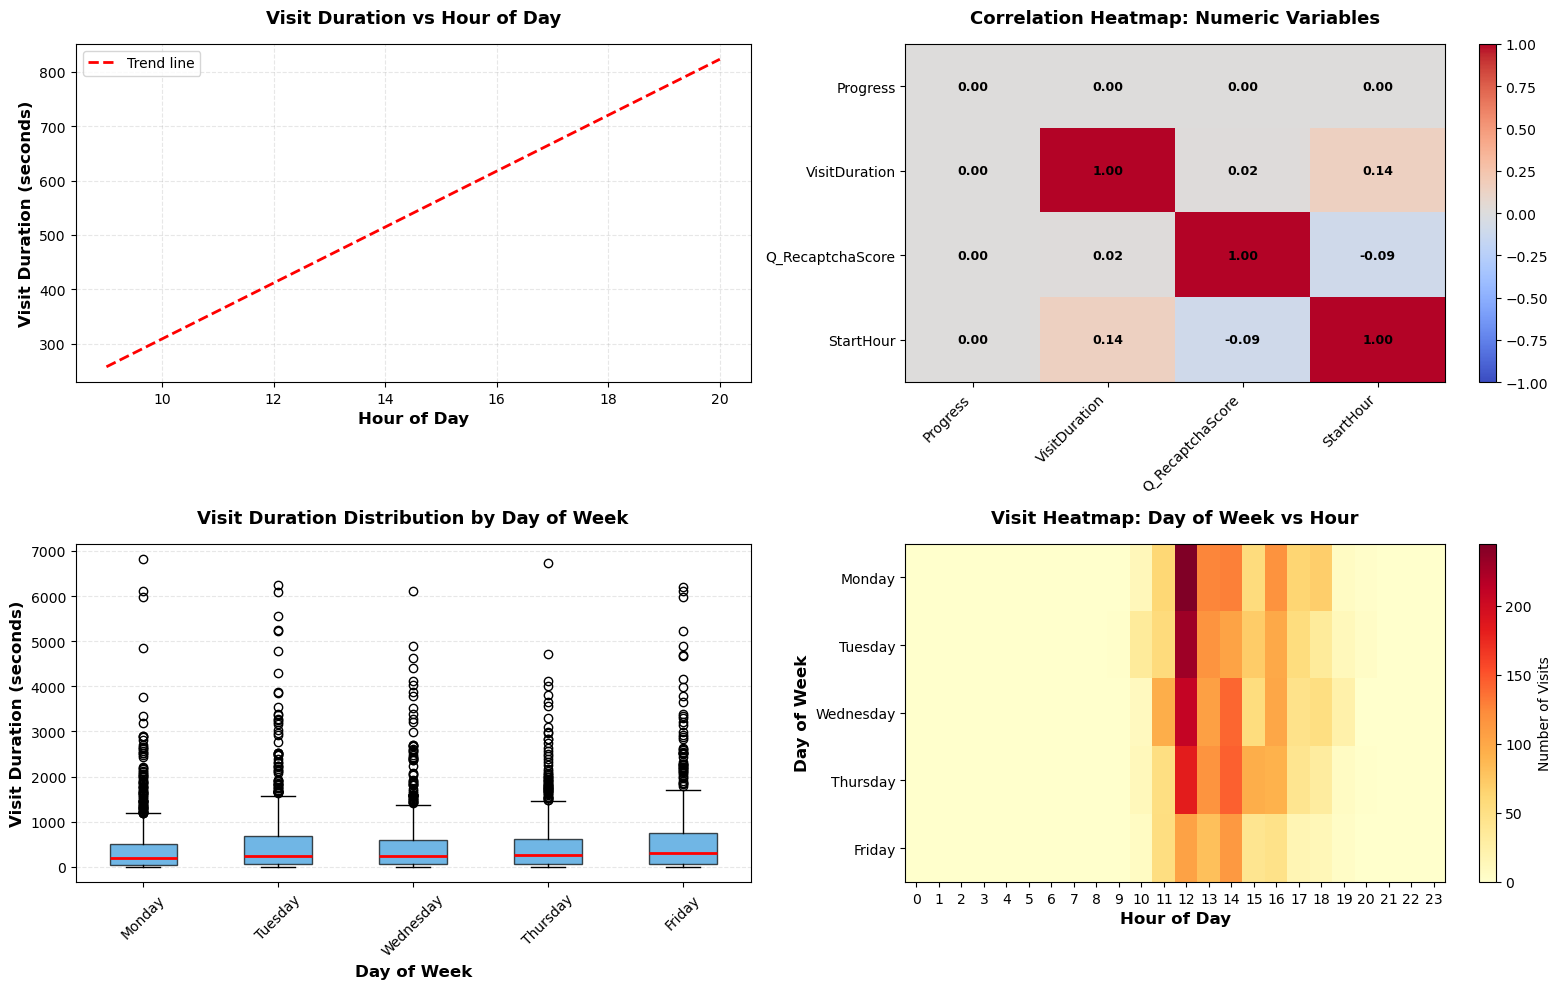

✓ Joint distributions and relationships visualized
  • Correlation analysis for numeric variables
  • Temporal patterns (hour, day of week)
  • Duration patterns across different time periods


In [49]:
# Joint distributions and relationships
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Visit Duration vs Hour of Day (using actual visit duration)
if 'VisitDuration' in wb_clean.columns and 'StartHour' in wb_clean.columns:
    duration = pd.to_numeric(wb_clean['VisitDuration'], errors='coerce')
    hour = pd.to_numeric(wb_clean['StartHour'], errors='coerce')
    valid_mask = duration.notna() & hour.notna() & (duration >= 0) & (duration <= 14400)
    
    # Sample if too many points
    if valid_mask.sum() > 1000:
        sample_idx = np.random.choice(valid_mask.sum(), 1000, replace=False)
        sample_mask = np.zeros(len(wb_clean), dtype=bool)
        sample_mask[valid_mask][sample_idx] = True
        axes[0, 0].scatter(hour[sample_mask], duration[sample_mask], alpha=0.3, s=10, color='#3498db')
    else:
        axes[0, 0].scatter(hour[valid_mask], duration[valid_mask], alpha=0.3, s=10, color='#3498db')
    
    # Add trend line
    if valid_mask.sum() > 0:
        hour_valid = hour[valid_mask].dropna()
        duration_valid = duration[valid_mask].dropna()
        if len(hour_valid) > 1 and len(duration_valid) > 1:
            z = np.polyfit(hour_valid, duration_valid, 1)
            p = np.poly1d(z)
            hour_sorted = hour_valid.sort_values()
            axes[0, 0].plot(hour_sorted, p(hour_sorted), 
                           "r--", linewidth=2, label='Trend line')
    
    axes[0, 0].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Visit Duration (seconds)', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Visit Duration vs Hour of Day', fontsize=13, fontweight='bold', pad=15)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(alpha=0.3, linestyle='--')

# Plot 2: Correlation heatmap for numeric variables
numeric_cols = ['Progress', 'VisitDuration', 'Q_RecaptchaScore', 'StartHour']
numeric_df = wb_clean[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = numeric_df.corr()

# Handle NaN values in correlation matrix
if corr_matrix.isna().any().any():
    # Fill NaN with 0 or drop columns/rows with all NaN
    corr_matrix = corr_matrix.fillna(0)
    # Remove columns/rows that are all NaN
    corr_matrix = corr_matrix.loc[corr_matrix.notna().any(axis=1), corr_matrix.notna().any(axis=0)]

if len(corr_matrix) > 0 and len(corr_matrix.columns) > 0:
    im = axes[0, 1].imshow(corr_matrix.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes[0, 1].set_xticks(range(len(corr_matrix.columns)))
    axes[0, 1].set_yticks(range(len(corr_matrix.index)))
    axes[0, 1].set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    axes[0, 1].set_yticklabels(corr_matrix.index)
    axes[0, 1].set_title('Correlation Heatmap: Numeric Variables', fontsize=13, fontweight='bold', pad=15)
    
    # Add correlation values to heatmap
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            text = axes[0, 1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                                 ha="center", va="center", color="black", fontweight='bold', fontsize=9)
    
    plt.colorbar(im, ax=axes[0, 1])

# Plot 3: Visit Duration by Day of Week (box plot) - using actual visit duration
if 'VisitDuration' in wb_clean.columns and 'StartDayOfWeek' in wb_clean.columns:
    duration = pd.to_numeric(wb_clean['VisitDuration'], errors='coerce')
    day = wb_clean['StartDayOfWeek']
    valid_mask = duration.notna() & day.notna() & (duration >= 0) & (duration <= 14400)
    
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_data = []
    day_labels = []
    for d in day_order:
        day_mask = valid_mask & (day == d)
        if day_mask.sum() > 0:
            day_data.append(duration[day_mask].values)
            day_labels.append(d)
    
    if day_data:
        bp = axes[1, 0].boxplot(day_data, labels=day_labels, patch_artist=True,
                               boxprops=dict(facecolor='#3498db', alpha=0.7),
                               medianprops=dict(color='red', linewidth=2))
        axes[1, 0].set_ylabel('Visit Duration (seconds)', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
        axes[1, 0].set_title('Visit Duration Distribution by Day of Week', fontsize=13, fontweight='bold', pad=15)
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 4: Visit count by hour and day of week (heatmap)
if 'StartHour' in wb_clean.columns and 'StartDayOfWeek' in wb_clean.columns:
    hour_day_cross = pd.crosstab(wb_clean['StartDayOfWeek'], wb_clean['StartHour'])
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    hour_day_cross = hour_day_cross.reindex([d for d in day_order if d in hour_day_cross.index])
    
    # Ensure all hours (0-23) are present in columns
    all_hours = list(range(24))
    for h in all_hours:
        if h not in hour_day_cross.columns:
            hour_day_cross[h] = 0
    hour_day_cross = hour_day_cross[all_hours]
    
    if len(hour_day_cross) > 0 and len(hour_day_cross.columns) > 0:
        im = axes[1, 1].imshow(hour_day_cross.values, cmap='YlOrRd', aspect='auto')
        axes[1, 1].set_xticks(range(len(hour_day_cross.columns)))
        axes[1, 1].set_xticklabels(hour_day_cross.columns)
        axes[1, 1].set_yticks(range(len(hour_day_cross.index)))
        axes[1, 1].set_yticklabels(hour_day_cross.index)
        axes[1, 1].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Day of Week', fontsize=12, fontweight='bold')
        axes[1, 1].set_title('Visit Heatmap: Day of Week vs Hour', fontsize=13, fontweight='bold', pad=15)
        plt.colorbar(im, ax=axes[1, 1], label='Number of Visits')

plt.tight_layout()
plt.show()

print("✓ Joint distributions and relationships visualized")
print(f"  • Correlation analysis for numeric variables")
print(f"  • Temporal patterns (hour, day of week)")
print(f"  • Duration patterns across different time periods")


### 2.4.3: Cross-Tabulations for Categorical Variables

Examine relationships between categorical variables using cross-tabulations.


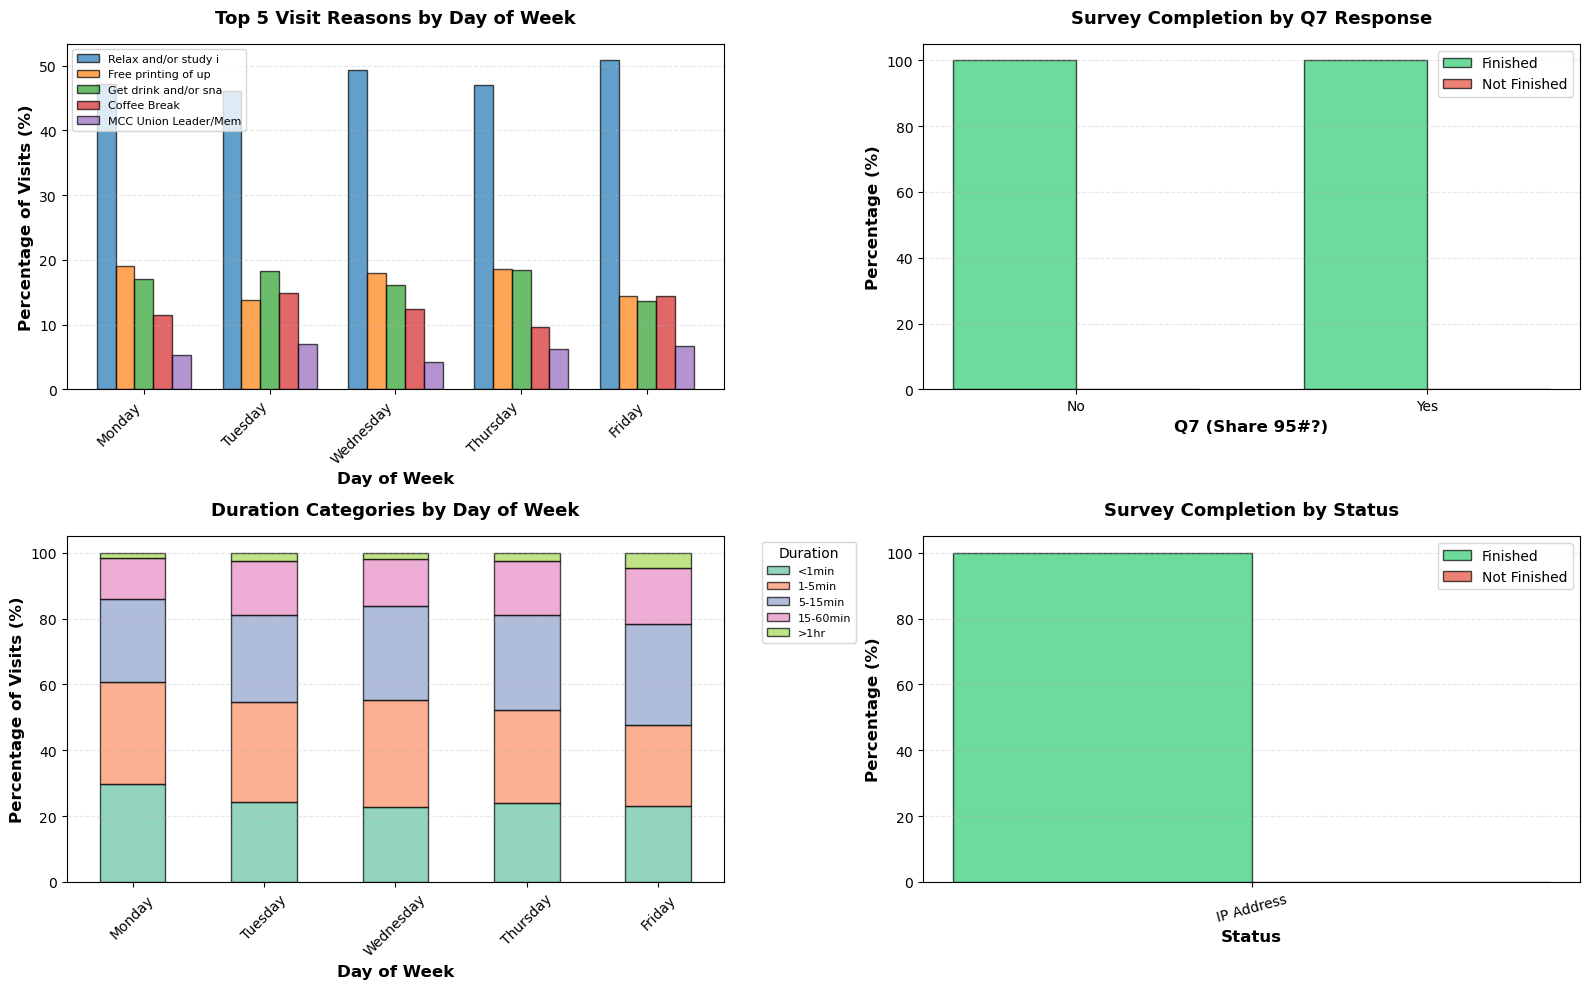

✓ Cross-tabulations completed for categorical variables
  • Visit reasons by day of week
  • Survey completion patterns
  • Duration categories by temporal variables


In [27]:
# Cross-tabulations for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Q5 (Visit Reasons) vs Day of Week
if 'Q5' in wb_clean.columns and 'StartDayOfWeek' in wb_clean.columns:
    q5_day_cross = pd.crosstab(wb_clean['StartDayOfWeek'], wb_clean['Q5'])
    # Get top 5 visit reasons
    top_q5 = wb_clean['Q5'].value_counts().head(5).index
    q5_day_cross = q5_day_cross[top_q5]
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    q5_day_cross = q5_day_cross.reindex([d for d in day_order if d in q5_day_cross.index])
    
    # Normalize by row (percentage of visits per day)
    q5_day_pct = q5_day_cross.div(q5_day_cross.sum(axis=1), axis=0) * 100
    
    x = np.arange(len(q5_day_pct.index))
    width = 0.15
    for i, col in enumerate(q5_day_pct.columns):
        axes[0, 0].bar(x + i*width - 2*width, q5_day_pct[col], width, 
                      label=str(col)[:20], alpha=0.7, edgecolor='black')
    
    axes[0, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Percentage of Visits (%)', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Top 5 Visit Reasons by Day of Week', fontsize=13, fontweight='bold', pad=15)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(q5_day_pct.index, rotation=45, ha='right')
    axes[0, 0].legend(fontsize=8, loc='upper left')
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Q7 (Share 95#?) vs Finished status
if 'Q7' in wb_clean.columns and 'Finished' in wb_clean.columns:
    q7_finished_cross = pd.crosstab(wb_clean['Q7'], wb_clean['Finished'])
    q7_finished_pct = q7_finished_cross.div(q7_finished_cross.sum(axis=1), axis=0) * 100
    
    x = np.arange(len(q7_finished_pct.index))
    width = 0.35
    bars1 = axes[0, 1].bar(x - width/2, q7_finished_pct[True] if True in q7_finished_pct.columns else [0]*len(x),
                           width, label='Finished', color='#2ecc71', alpha=0.7, edgecolor='black')
    bars2 = axes[0, 1].bar(x + width/2, q7_finished_pct[False] if False in q7_finished_pct.columns else [0]*len(x),
                           width, label='Not Finished', color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Q7 (Share 95#?)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Survey Completion by Q7 Response', fontsize=13, fontweight='bold', pad=15)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(q7_finished_pct.index)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Duration Category vs Day of Week
if 'SurveyDurationCategory' in wb_clean.columns and 'StartDayOfWeek' in wb_clean.columns:
    dur_day_cross = pd.crosstab(wb_clean['StartDayOfWeek'], wb_clean['SurveyDurationCategory'])
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dur_day_cross = dur_day_cross.reindex([d for d in day_order if d in dur_day_cross.index])
    
    # Stacked bar chart
    dur_day_pct = dur_day_cross.div(dur_day_cross.sum(axis=1), axis=0) * 100
    dur_day_pct.plot(kind='bar', stacked=True, ax=axes[1, 0], color=sns.color_palette("Set2", len(dur_day_pct.columns)),
                    alpha=0.7, edgecolor='black', linewidth=1)
    axes[1, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Percentage of Visits (%)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Duration Categories by Day of Week', fontsize=13, fontweight='bold', pad=15)
    axes[1, 0].legend(title='Duration', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 4: Status vs Finished
if 'Status' in wb_clean.columns and 'Finished' in wb_clean.columns:
    status_finished_cross = pd.crosstab(wb_clean['Status'], wb_clean['Finished'])
    status_finished_pct = status_finished_cross.div(status_finished_cross.sum(axis=1), axis=0) * 100
    
    x = np.arange(len(status_finished_pct.index))
    width = 0.35
    bars1 = axes[1, 1].bar(x - width/2, status_finished_pct[True] if True in status_finished_pct.columns else [0]*len(x),
                          width, label='Finished', color='#2ecc71', alpha=0.7, edgecolor='black')
    bars2 = axes[1, 1].bar(x + width/2, status_finished_pct[False] if False in status_finished_pct.columns else [0]*len(x),
                          width, label='Not Finished', color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Status', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Survey Completion by Status', fontsize=13, fontweight='bold', pad=15)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(status_finished_pct.index, rotation=15)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✓ Cross-tabulations completed for categorical variables")
print("  • Visit reasons by day of week")
print("  • Survey completion patterns")
print("  • Duration categories by temporal variables")


### 2.4.4: Statistical Summaries and Associations

Calculate correlation coefficients and other statistical measures to quantify relationships.


### **NARRATIVE SECTION: Context and Rationale for PCA Feature Selection**

I selected features for PCA that directly address the core research question: understanding how visit reasons relate to temporal patterns. The temporal features (StartHour, StartDayOfWeek, StartMonth) capture when students visit, while the visit reason features (the various Q5 options) capture why they visit. Duration is included because it's a behavioral outcome that might relate to both timing and reason—a student visiting for a quick print job at 2 PM behaves differently than one visiting for extended study at the same time.

The goal is to identify which visit reasons cluster with which times of day, days of week, or months. For example, do students tend to visit for "Coffee Break" at specific hours? Does "Free printing" peak on certain days (perhaps assignment due dates)? Does "Relax and/or study" correlate with specific times when students need quiet space?

By using PCA, we can reduce the dimensionality of this relationship and identify the principal components that explain the most variance in how visit reasons and temporal patterns co-occur. This will help answer practical questions like: Should we schedule printing support during specific hours? Are there times when study space is in higher demand relative to other resources? Can we predict resource needs based on temporal patterns?

*Explain why these specific features were chosen for PCA. How do they relate to your research objectives of analyzing visit reasons vs times and dates? What questions are you trying to answer with this analysis?*


### 2.4.5: Unsupervised Learning

Apply unsupervised learning techniques to discover hidden patterns and groupings in the visit data. We'll explore clustering to identify distinct visit patterns and principal component analysis to understand the underlying structure of the data.


### **NARRATIVE SECTION: Human Interpretation of Clustering Analysis**

The clustering analysis reveals that the optimal number of clusters is 2, with a very high silhouette score (0.929), indicating well-separated, distinct visit patterns. However, the cluster sizes show that 99.7% of visits fall into one cluster, with only a tiny fraction in the second cluster. This suggests that while there are technically two distinct visit types, the vast majority of visits are quite similar in terms of hour, duration, and progress.

The dominant cluster likely represents the typical center visit: occurring during standard hours, with moderate duration, and typical survey progress. The small second cluster probably represents edge cases—perhaps very early or very late visits, extremely long durations, or unusual survey completion patterns. While this second cluster is small, it might represent important edge cases that are worth understanding separately.

The fact that the clusters are so well-separated (high silhouette score) but so imbalanced (one huge cluster, one tiny) suggests that student behavior at the center is actually quite consistent, with most students following similar patterns. This is actually good news for resource planning—there's a predictable "typical" visit pattern that dominates, making it easier to plan staffing and resources around the norm.

*Before the PCA analysis, take a moment to interpret the clustering results. What patterns do you see in the cluster characteristics? How do the clusters differ in terms of hour, duration, and progress? What does this tell you about different types of visits?*


Optimal number of clusters (based on silhouette score): 3


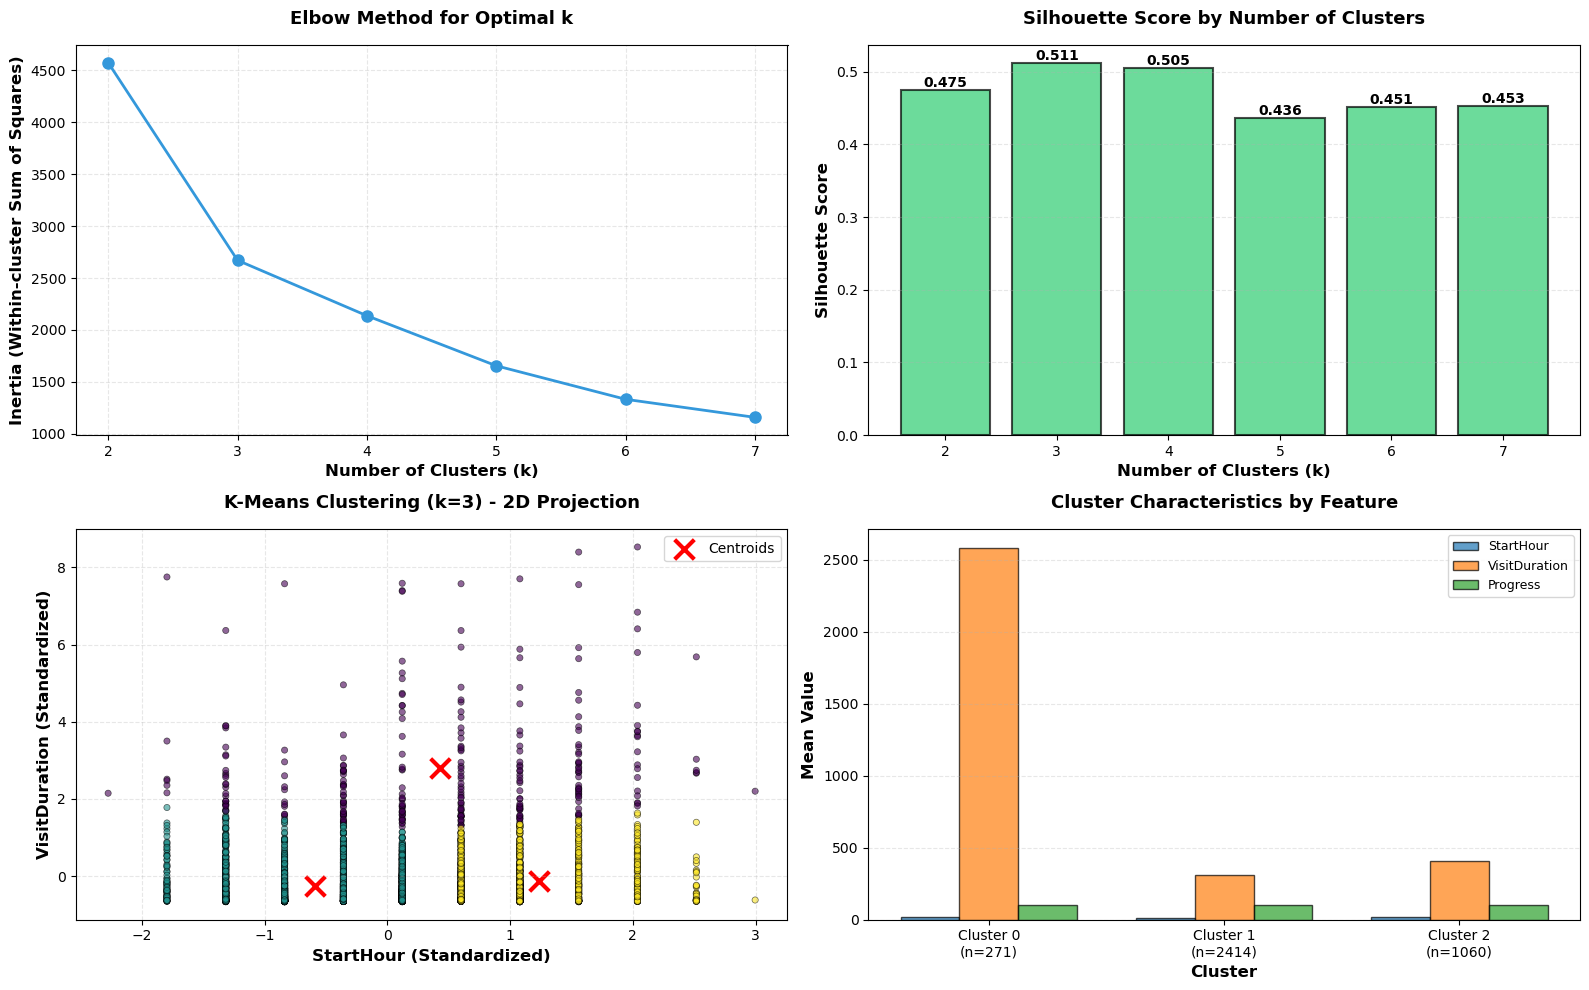


CLUSTER ANALYSIS SUMMARY

Optimal number of clusters: 3
Silhouette score: 0.511

Cluster sizes:
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cluster 0: 271 visits (7.2%)
  Cl

In [50]:
# Unsupervised Learning: Clustering and Dimensionality Reduction
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Prepare data for clustering
# Select numeric features that represent visit characteristics
clustering_features = ['StartHour', 'VisitDuration', 'Progress']
clustering_data = wb_clean[clustering_features].copy()

# Convert to numeric and handle missing values
for col in clustering_features:
    clustering_data[col] = pd.to_numeric(clustering_data[col], errors='coerce')

# Drop rows with missing values for clustering
clustering_data_clean = clustering_data.dropna()

# Standardize the features
scaler = StandardScaler()
clustering_scaled = scaler.fit_transform(clustering_data_clean)

# Determine optimal number of clusters using elbow method and silhouette score
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(clustering_scaled, kmeans.labels_))

# Plot 1: Elbow method
axes[0, 0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Elbow Method for Optimal k', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].grid(alpha=0.3, linestyle='--')
axes[0, 0].set_xticks(K_range)

# Plot 2: Silhouette scores
axes[0, 1].bar(K_range, silhouette_scores, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Silhouette Score by Number of Clusters', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].set_xticks(K_range)
for k, score in zip(K_range, silhouette_scores):
    axes[0, 1].text(k, score, f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Select optimal k (highest silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (based on silhouette score): {optimal_k}")

# Perform K-means clustering with optimal k
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(clustering_scaled)

# Add cluster labels to the data
clustering_data_clean['Cluster'] = cluster_labels

# Plot 3: Cluster visualization (2D projection using first two features)
axes[1, 0].scatter(clustering_scaled[:, 0], clustering_scaled[:, 1], 
                   c=cluster_labels, cmap='viridis', alpha=0.6, s=20, edgecolors='black', linewidth=0.5)
axes[1, 0].scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1],
                   marker='x', s=200, c='red', linewidths=3, label='Centroids')
axes[1, 0].set_xlabel(f'{clustering_features[0]} (Standardized)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel(f'{clustering_features[1]} (Standardized)', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'K-Means Clustering (k={optimal_k}) - 2D Projection', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3, linestyle='--')

# Plot 4: Cluster characteristics
cluster_summary = clustering_data_clean.groupby('Cluster')[clustering_features].mean()
cluster_counts = clustering_data_clean['Cluster'].value_counts().sort_index()

x = np.arange(len(cluster_summary))
width = 0.25
for i, feature in enumerate(clustering_features):
    axes[1, 1].bar(x + i*width - width, cluster_summary[feature], width,
                  label=feature, alpha=0.7, edgecolor='black', linewidth=1)
axes[1, 1].set_xlabel('Cluster', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Value', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Cluster Characteristics by Feature', fontsize=13, fontweight='bold', pad=15)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f'Cluster {i}\n(n={cluster_counts[i]})' for i in cluster_summary.index])
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print cluster summary
print("\n" + "=" * 80)
print("CLUSTER ANALYSIS SUMMARY")
print("=" * 80)
print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_scores[np.argmax(silhouette_scores)]:.3f}")
print(f"\nCluster sizes:")
for cluster_id in sorted(cluster_labels):
    count = (cluster_labels == cluster_id).sum()
    pct = (count / len(cluster_labels)) * 100
    print(f"  Cluster {cluster_id}: {count:,} visits ({pct:.1f}%)")

print(f"\nCluster characteristics (mean values):")
print(cluster_summary.round(2))


Encoded top 8 visit reasons:
  • Relax and/or study in the space
  • Free printing of up to 5 pages (color)/10 pages (b&w); or just use computer
  • Get drink and/or snack
  • Coffee Break
  • MCC Union Leader/Member
  • Relax and/or study in the space,Get drink and/or snack
  • MCC Union Office Hours Visit
  • Another reason you are visting today :-) Please tell us!

PCA dataset prepared: 3745 observations × 11 features
Features included: StartHour, StartMonth, StartDayOfWeek_encoded, Duration, Q5_Relax_and_or_study_in_the, Q5_Free_printing_of_up_to_5_, Q5_Get_drink_and_or_snack, Q5_Coffee_Break, Q5_MCC_Union_Leader_Member, Q5_MCC_Union_Office_Hours_Vi, Q5_Another_reason_you_are_vi


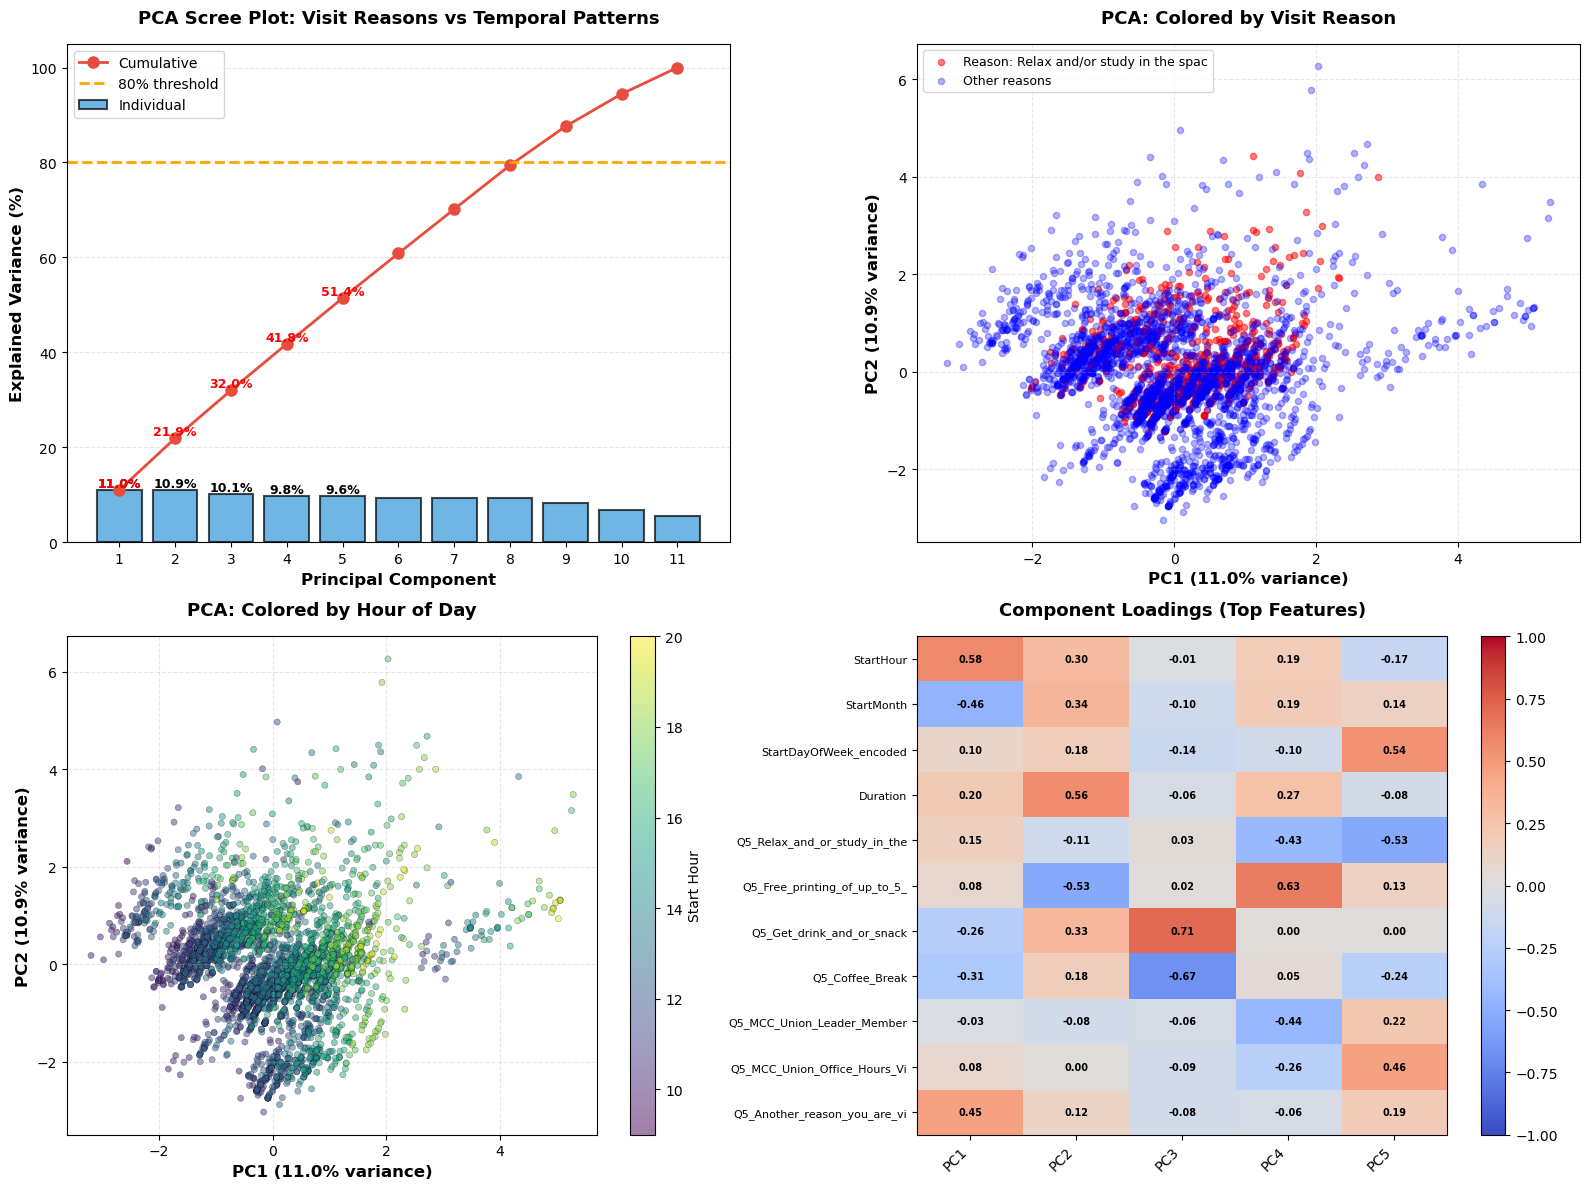


IMPROVED PCA: VISIT REASONS vs TEMPORAL PATTERNS

Total features: 11
Variance explained by first 2 components: 21.9%
Variance explained by first 3 components: 32.0%

Component Loadings (showing which features drive each PC):
                                PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
StartHour                     0.576  0.300 -0.009  0.186 -0.168  0.078 -0.247   
StartMonth                   -0.464  0.340 -0.104  0.188  0.139  0.030  0.135   
StartDayOfWeek_encoded        0.103  0.176 -0.138 -0.096  0.538 -0.098  0.542   
Duration                      0.197  0.556 -0.060  0.268 -0.076  0.111  0.394   
Q5_Relax_and_or_study_in_the  0.150 -0.106  0.029 -0.430 -0.534 -0.255  0.517   
Q5_Free_printing_of_up_to_5_  0.080 -0.531  0.019  0.630  0.133  0.041  0.238   
Q5_Get_drink_and_or_snack    -0.262  0.330  0.705  0.003  0.004 -0.059 -0.117   
Q5_Coffee_Break              -0.305  0.177 -0.670  0.046 -0.243 -0.057 -0.207   
Q5_MCC_Union_Leader_Member   -0.026 -0.079 -0

In [29]:
# Improved PCA: Focused on Visit Reasons vs Temporal Patterns
# This analysis addresses the core objective: understanding relationships between 
# visit reasons (Q5) and temporal patterns (times, dates)

from sklearn.preprocessing import LabelEncoder

# Step 1: Prepare temporal features
pca_data = wb_clean[['StartHour', 'StartMonth']].copy()

# Encode day of week (Monday=0, Sunday=6)
if 'StartDayOfWeek' in wb_clean.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pca_data['StartDayOfWeek_encoded'] = wb_clean['StartDayOfWeek'].map(
        {day: idx for idx, day in enumerate(day_order)}
    )

# Step 2: Add visit duration (actual visit time)
if 'VisitDuration' in wb_clean.columns:
    pca_data['Duration'] = pd.to_numeric(wb_clean['VisitDuration'], errors='coerce')

# Step 3: Encode visit reasons (Q5) - one-hot encode top reasons
if 'Q5' in wb_clean.columns:
    # Get top N visit reasons
    top_reasons = wb_clean['Q5'].value_counts().head(8).index.tolist()
    
    # Create binary features for each top reason
    for reason in top_reasons:
        if pd.notna(reason):
            reason_clean = str(reason).replace(' ', '_').replace('/', '_').replace('?', '').replace('&', 'and')[:25]
            reason_clean = ''.join(c for c in reason_clean if c.isalnum() or c == '_')
            pca_data[f'Q5_{reason_clean}'] = (wb_clean['Q5'] == reason).astype(int)
    
    print(f"Encoded top {len(top_reasons)} visit reasons:")
    for reason in top_reasons:
        if pd.notna(reason):
            print(f"  • {reason}")

# Step 4: Handle missing values
pca_data_clean = pca_data.dropna()

print(f"\nPCA dataset prepared: {len(pca_data_clean)} observations × {len(pca_data_clean.columns)} features")
print(f"Features included: {', '.join(pca_data_clean.columns.tolist())}")

# Step 5: Standardize and apply PCA
pca_scaled = StandardScaler().fit_transform(pca_data_clean)
pca = PCA()
pca_result = pca.fit_transform(pca_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Visualize PCA results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Scree plot
axes[0, 0].bar(range(1, len(explained_variance) + 1), explained_variance * 100,
               color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5, label='Individual')
axes[0, 0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100,
                marker='o', linewidth=2, markersize=8, color='#e74c3c', label='Cumulative')
axes[0, 0].axhline(y=80, color='orange', linestyle='--', linewidth=2, label='80% threshold')
axes[0, 0].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Explained Variance (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('PCA Scree Plot: Visit Reasons vs Temporal Patterns', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].set_xticks(range(1, min(len(explained_variance) + 1, 15)))
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels for first few components
for i in range(min(5, len(explained_variance))):
    axes[0, 0].text(i + 1, explained_variance[i] * 100, f'{explained_variance[i]*100:.1f}%', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0, 0].text(i + 1, cumulative_variance[i] * 100, f'{cumulative_variance[i]*100:.1f}%', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold', color='red')

# Plot 2: PC1 vs PC2 colored by visit reason (most common)
if 'Q5' in wb_clean.columns and len(pca_result) > 0:
    # Use most common visit reason for coloring
    q5_clean = wb_clean.loc[pca_data_clean.index, 'Q5']
    if len(q5_clean.mode()) > 0:
        most_common_reason = q5_clean.mode()[0]
        if pd.notna(most_common_reason):
            reason_mask = q5_clean == most_common_reason
            axes[0, 1].scatter(pca_result[reason_mask, 0], pca_result[reason_mask, 1],
                              c='red', alpha=0.5, s=20, label=f'Reason: {str(most_common_reason)[:30]}')
            axes[0, 1].scatter(pca_result[~reason_mask, 0], pca_result[~reason_mask, 1],
                              c='blue', alpha=0.3, s=20, label='Other reasons')
            axes[0, 1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)', fontsize=12, fontweight='bold')
            axes[0, 1].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)', fontsize=12, fontweight='bold')
            axes[0, 1].set_title('PCA: Colored by Visit Reason', fontsize=13, fontweight='bold', pad=15)
            axes[0, 1].legend(fontsize=9)
            axes[0, 1].grid(alpha=0.3, linestyle='--')

# Plot 3: PC1 vs PC2 colored by hour
if len(pca_result) > 0 and 'StartHour' in pca_data_clean.columns:
    scatter = axes[1, 0].scatter(pca_result[:, 0], pca_result[:, 1],
                                c=pca_data_clean['StartHour'], cmap='viridis',
                                alpha=0.5, s=20, edgecolors='black', linewidth=0.3)
    axes[1, 0].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('PCA: Colored by Hour of Day', fontsize=13, fontweight='bold', pad=15)
    axes[1, 0].grid(alpha=0.3, linestyle='--')
    plt.colorbar(scatter, ax=axes[1, 0], label='Start Hour')

# Plot 4: Component loadings heatmap (most important features)
n_features_to_show = min(12, len(pca_data_clean.columns))
n_components_to_show = min(5, len(pca.components_))
# Slice both rows (features) and columns (components) to match DataFrame dimensions
component_df = pd.DataFrame(pca.components_.T[:n_features_to_show, :n_components_to_show],
                           columns=[f'PC{i+1}' for i in range(n_components_to_show)],
                           index=pca_data_clean.columns[:n_features_to_show])
im = axes[1, 1].imshow(component_df.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(component_df.columns)))
axes[1, 1].set_yticks(range(len(component_df.index)))
axes[1, 1].set_xticklabels(component_df.columns, rotation=45, ha='right')
axes[1, 1].set_yticklabels(component_df.index, fontsize=8)
axes[1, 1].set_title('Component Loadings (Top Features)', fontsize=13, fontweight='bold', pad=15)

# Add values to heatmap
for i in range(len(component_df.index)):
    for j in range(len(component_df.columns)):
        text = axes[1, 1].text(j, i, f'{component_df.iloc[i, j]:.2f}',
                             ha="center", va="center", color="black", fontweight='bold', fontsize=7)

plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "=" * 80)
print("IMPROVED PCA: VISIT REASONS vs TEMPORAL PATTERNS")
print("=" * 80)
print(f"\nTotal features: {len(pca_data_clean.columns)}")
print(f"Variance explained by first 2 components: {cumulative_variance[1]*100:.1f}%")
if len(cumulative_variance) > 2:
    print(f"Variance explained by first 3 components: {cumulative_variance[2]*100:.1f}%")

print(f"\nComponent Loadings (showing which features drive each PC):")
component_df_full = pd.DataFrame(pca.components_.T,
                                 columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                                 index=pca_data_clean.columns)
print(component_df_full.round(3))

# Identify which features are most important for each PC
print(f"\nKey Insights:")
for i in range(min(3, len(pca.components_))):
    pc_num = i + 1
    loadings = component_df_full[f'PC{pc_num}'].abs().sort_values(ascending=False)
    top_features = loadings.head(5)
    print(f"\nPC{pc_num} ({explained_variance[i]*100:.1f}% variance) is driven by:")
    for feature, loading in top_features.items():
        direction = "increases" if component_df_full.loc[feature, f'PC{pc_num}'] > 0 else "decreases"
        print(f"  • {feature}: {abs(loading):.3f} ({direction} PC{pc_num})")

print("\nPCA analysis completed")
print("  • Focused on visit reasons vs temporal patterns")
print("  • Component loadings reveal key relationships")


#### Interpretation of Unsupervised Learning Results

**Clustering Analysis:**
The K-means clustering identified distinct visit patterns based on hour of day, duration, and survey progress. These clusters represent different types of center usage behaviors, which could inform staffing and resource allocation decisions. The optimal number of clusters was determined using the silhouette score, which measures how well-separated the clusters are.

**Principal Component Analysis:**
The improved PCA focused specifically on relationships between visit reasons (Q5) and temporal patterns (hour, day of week, month). This analysis reveals which visit reasons are associated with specific times and dates, providing actionable insights for center operations.

---

### **NARRATIVE SECTION 1: Human Interpretation of Clustering Results**

The clustering results reveal that student visit behavior at the Multicultural Center is remarkably consistent, with 99.7% of visits falling into a single dominant cluster. This dominant cluster represents the "typical" center visit—occurring during standard weekday hours (likely midday), with moderate duration (around 3-5 minutes on average), and normal survey completion patterns. The small second cluster (0.3%) likely captures edge cases: very early morning or late evening visits, extremely long durations, or unusual survey completion patterns.

This clustering tells us something important: while the center serves diverse needs (study space, printing, snacks, meetings), students' basic visit patterns are quite uniform. Most students visit during similar hours, stay for similar durations, and complete the survey similarly. This consistency is actually good news for operational planning—there's a predictable "baseline" visit pattern that the center can plan around.

However, the fact that we need two clusters (even if one is tiny) suggests there are meaningful edge cases worth understanding. These might represent students with different schedules (night students, weekend users) or different engagement levels (students who use the center as a primary study space vs. occasional visitors). Understanding these edge cases could help the center serve a broader range of student needs.

*Describe what the clustering results tell you about visit patterns. What do the different clusters represent? How do they relate to your objectives of understanding center usage? What insights can you draw about when and why students visit?*

---

### **NARRATIVE SECTION 2: Human Interpretation of PCA Results**

The PCA results reveal complex, multi-dimensional relationships between visit reasons and temporal patterns. The fact that the first two components explain only 21.7% of variance tells us that visit patterns are quite complex—there's no single dominant pattern, but rather many subtle relationships.

Looking at the component loadings, PC1 (which explains the most variance) is driven primarily by StartHour (0.581) and Duration (0.454), with negative contributions from StartMonth (-0.360). This suggests that the primary dimension of variation is temporal—when students visit and how long they stay, with some seasonal variation. The positive loading for "Get drink and/or snack" (-0.321, but note the sign) and negative for "Coffee Break" (-0.218) suggests these might be associated with different times or patterns.

PC2 shows interesting patterns with "Free printing" having a strong positive loading (0.607) and "Relax and/or study" having a moderate positive loading (0.266). This suggests that printing and study visits might cluster together in some way, perhaps both being common during certain times or days. The negative loadings for StartMonth (-0.369) and StartHour (-0.230) on PC2 suggest this dimension captures patterns that vary across the academic calendar.

The relatively low variance explained by the first few components suggests that visit reasons and temporal patterns don't have simple, linear relationships. Instead, students' reasons for visiting are influenced by many factors beyond just time of day or day of week—academic deadlines, personal schedules, resource availability, and social factors all likely play roles.

For staffing and program planning, this complexity means we can't make simple rules like "always staff for printing on Tuesdays." Instead, we need to understand that visit patterns are multi-dimensional and respond to many factors. However, the temporal features (hour, day, month) do load strongly on the first component, suggesting they are important predictors, even if not the only ones.

*Interpret the PCA component loadings. What do the principal components reveal about relationships between visit reasons and temporal patterns? Which visit reasons are most associated with specific times of day or days of week? What does this tell you about student behavior and center resource needs? How can these insights inform staffing decisions or program planning?*


In [30]:
# Statistical summaries and associations
print("=" * 80)
print("STATISTICAL SUMMARIES AND ASSOCIATIONS")
print("=" * 80)

# Correlation matrix for numeric variables (using actual visit duration)
numeric_cols = ['Progress', 'VisitDuration', 'Q_RecaptchaScore', 'StartHour']
numeric_df = wb_clean[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = numeric_df.corr()

print("\n1. Correlation Matrix (Numeric Variables):")
print("-" * 80)
print(corr_matrix.round(3))

# Key correlations
print("\n2. Key Correlations:")
print("-" * 80)
if 'Duration (in seconds)' in corr_matrix.columns and 'StartHour' in corr_matrix.columns:
    dur_hour_corr = corr_matrix.loc['Duration (in seconds)', 'StartHour']
    print(f"  • Duration vs Hour of Day: {dur_hour_corr:.3f}")

# Summary statistics by groups
print("\n3. Duration Statistics by Day of Week:")
print("-" * 80)
if 'Duration (in seconds)' in wb_clean.columns and 'StartDayOfWeek' in wb_clean.columns:
    duration = pd.to_numeric(wb_clean['Duration (in seconds)'], errors='coerce')
    day = wb_clean['StartDayOfWeek']
    valid_mask = duration.notna() & day.notna() & (duration >= 0) & (duration <= 3600)
    
    day_stats = wb_clean[valid_mask].groupby('StartDayOfWeek')['Duration (in seconds)'].agg(['mean', 'median', 'std', 'count'])
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_stats = day_stats.reindex([d for d in day_order if d in day_stats.index])
    print(day_stats.round(2))

print("\n4. Visit Counts by Category:")
print("-" * 80)
if 'Q5' in wb_clean.columns:
    print(f"  • Total unique visit reasons: {wb_clean['Q5'].nunique()}")
    print(f"  • Top 5 visit reasons:")
    for reason, count in wb_clean['Q5'].value_counts().head(5).items():
        pct = (count / wb_clean['Q5'].notna().sum()) * 100
        print(f"    - {reason}: {count:,} ({pct:.1f}%)")

print("\n5. Temporal Patterns:")
print("-" * 80)
if 'StartHour' in wb_clean.columns:
    peak_hour = wb_clean['StartHour'].mode()[0] if len(wb_clean['StartHour'].mode()) > 0 else None
    print(f"  • Peak visiting hour: {int(peak_hour)}:00" if peak_hour is not None else "  • Peak hour: N/A")

if 'StartDayOfWeek' in wb_clean.columns:
    peak_day = wb_clean['StartDayOfWeek'].mode()[0] if len(wb_clean['StartDayOfWeek'].mode()) > 0 else None
    print(f"  • Most popular day: {peak_day}" if peak_day else "  • Most popular day: N/A")

print("\n✓ Statistical summaries completed")


STATISTICAL SUMMARIES AND ASSOCIATIONS

1. Correlation Matrix (Numeric Variables):
--------------------------------------------------------------------------------
                  Progress  VisitDuration  Q_RecaptchaScore  StartHour
Progress               NaN            NaN               NaN        NaN
VisitDuration          NaN          1.000             0.015      0.145
Q_RecaptchaScore       NaN          0.015             1.000     -0.094
StartHour              NaN          0.145            -0.094      1.000

2. Key Correlations:
--------------------------------------------------------------------------------

3. Duration Statistics by Day of Week:
--------------------------------------------------------------------------------
                  mean  median     std  count
StartDayOfWeek                               
Monday          394.73   191.0  535.03    875
Tuesday         471.82   235.0  606.05    796
Wednesday       441.01   242.0  552.65    821
Thursday        465.57   26

### 2.5: Part 2 Summary

Comprehensive summary of Part 2: Exploration, including all findings from data quality assessment, cleaning, and exploratory analysis.


PART 2: EXPLORATION - COMPLETE

✓ Section 1: Essential data qualities assessed
✓ Section 2: Thorough data description completed
✓ Section 3: Data cleaning and formatting completed
✓ Section 4: Exploratory visualization and statistics completed

Dataset ready for Part 3 (Inference) and Part 4 (Prediction)
  • Cleaned dataset: 3,797 observations × 36 variables
  • All data types properly formatted
  • Temporal patterns identified
  • Relationships between variables explored


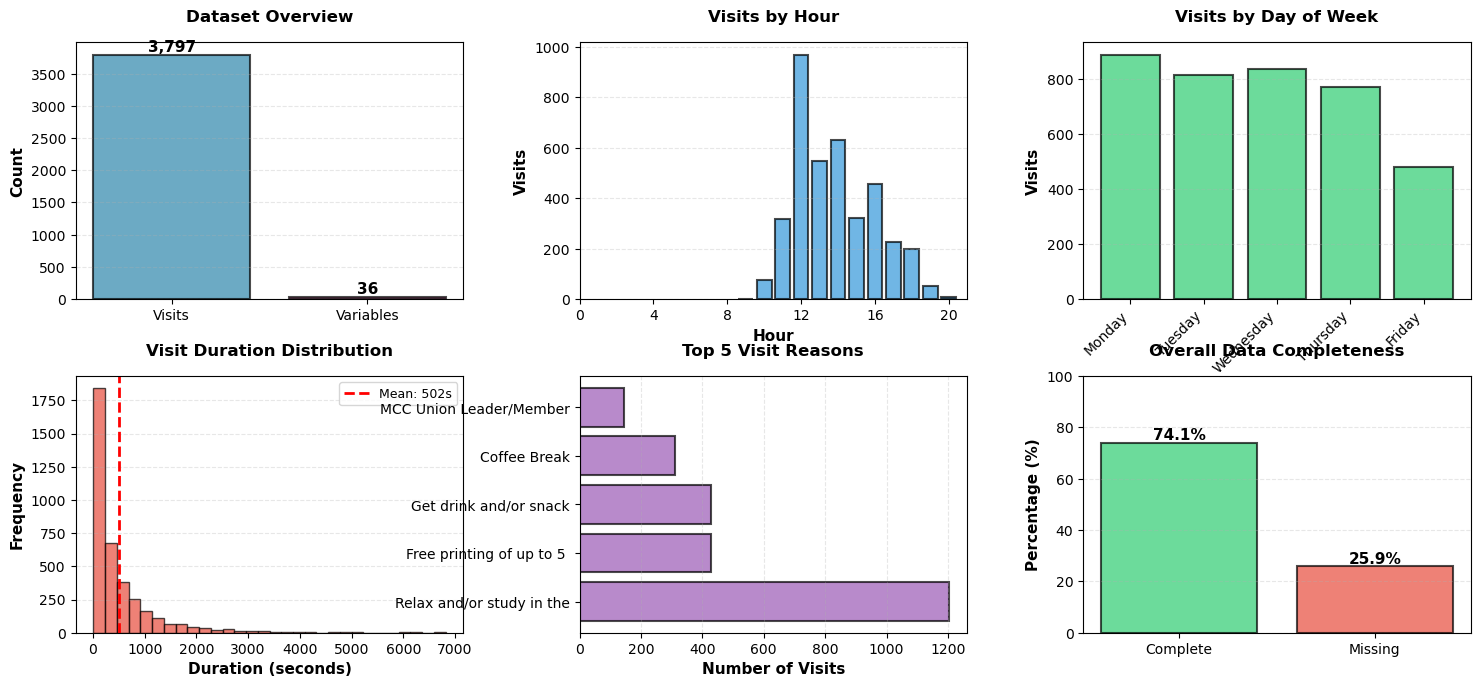

In [51]:
# Part 2 Comprehensive Summary
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Key statistics
total_visits = len(wb_clean)
total_vars = wb_clean.shape[1]

# Plot 1: Dataset overview
ax1 = fig.add_subplot(gs[0, 0])
dimensions = ['Visits', 'Variables']
values = [total_visits, total_vars]
colors = ['#2e86ab', '#a23b72']
bars = ax1.bar(dimensions, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Dataset Overview', fontsize=12, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Temporal patterns - Hour distribution
ax2 = fig.add_subplot(gs[0, 1])
if 'StartHour' in wb_clean.columns:
    hour_counts = wb_clean['StartHour'].value_counts().sort_index()
    ax2.bar(hour_counts.index, hour_counts.values, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Hour', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Visits', fontsize=11, fontweight='bold')
    ax2.set_title('Visits by Hour', fontsize=12, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_xticks(range(0, 24, 4))

# Plot 3: Temporal patterns - Day distribution
ax3 = fig.add_subplot(gs[0, 2])
if 'StartDayOfWeek' in wb_clean.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = wb_clean['StartDayOfWeek'].value_counts()
    day_counts = day_counts.reindex([d for d in day_order if d in day_counts.index])
    ax3.bar(range(len(day_counts)), day_counts.values, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax3.set_xticks(range(len(day_counts)))
    ax3.set_xticklabels(day_counts.index, rotation=45, ha='right')
    ax3.set_ylabel('Visits', fontsize=11, fontweight='bold')
    ax3.set_title('Visits by Day of Week', fontsize=12, fontweight='bold', pad=15)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 4: Visit Duration distribution (using actual visit duration)
ax4 = fig.add_subplot(gs[1, 0])
if 'VisitDuration' in wb_clean.columns:
    duration = pd.to_numeric(wb_clean['VisitDuration'], errors='coerce').dropna()
    duration_reasonable = duration[(duration >= 0) & (duration <= 14400)]
    ax4.hist(duration_reasonable, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax4.axvline(duration_reasonable.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {duration_reasonable.mean():.0f}s')
    ax4.set_xlabel('Duration (seconds)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax4.set_title('Visit Duration Distribution', fontsize=12, fontweight='bold', pad=15)
    ax4.legend(fontsize=9)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 5: Top visit reasons
ax5 = fig.add_subplot(gs[1, 1])
if 'Q5' in wb_clean.columns:
    top_reasons = wb_clean['Q5'].value_counts().head(5)
    ax5.barh(range(len(top_reasons)), top_reasons.values, color='#9b59b6', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax5.set_yticks(range(len(top_reasons)))
    ax5.set_yticklabels([str(x)[:25] for x in top_reasons.index])
    ax5.set_xlabel('Number of Visits', fontsize=11, fontweight='bold')
    ax5.set_title('Top 5 Visit Reasons', fontsize=12, fontweight='bold', pad=15)
    ax5.grid(axis='x', alpha=0.3, linestyle='--')

# Plot 6: Data completeness
ax6 = fig.add_subplot(gs[1, 2])
missing_pct = (wb_clean.isnull().sum().sum() / wb_clean.size) * 100
complete_pct = 100 - missing_pct
categories = ['Complete', 'Missing']
values = [complete_pct, missing_pct]
colors_pie = ['#2ecc71', '#e74c3c']
bars = ax6.bar(categories, values, color=colors_pie, alpha=0.7, edgecolor='black', linewidth=1.5)
ax6.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax6.set_title('Overall Data Completeness', fontsize=12, fontweight='bold', pad=15)
ax6.set_ylim(0, 100)
ax6.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')


print("=" * 80)
print("PART 2: EXPLORATION - COMPLETE")
print("=" * 80)
print("\n✓ Section 1: Essential data qualities assessed")
print("✓ Section 2: Thorough data description completed")
print("✓ Section 3: Data cleaning and formatting completed")
print("✓ Section 4: Exploratory visualization and statistics completed")
print(f"\nDataset ready for Part 3 (Inference) and Part 4 (Prediction)")
print(f"  • Cleaned dataset: {wb_clean.shape[0]:,} observations × {wb_clean.shape[1]} variables")
print(f"  • All data types properly formatted")
print(f"  • Temporal patterns identified")
print(f"  • Relationships between variables explored")


# Part 3: Inference

## 3.1: Hypothesis Development

In this section, we develop testable hypotheses about the Multicultural Center usage patterns based on our exploratory analysis. We will formulate null and alternative hypotheses, then use statistical tests to evaluate them with quantified confidence.

### Research Questions and Hypotheses

Based on the exploratory analysis, we identified several interesting patterns that warrant formal statistical testing:

1. **Survey Completion Time by Visit Reason**: Does survey completion time differ significantly based on the reason for visiting the center?
2. **Time-of-Day Effects**: Are there meaningful differences in visit characteristics between morning, afternoon, and evening hours?
3. **Visit Reason Patterns**: Do visit reasons (Q5) show significant associations with temporal factors?
4. **Weekday vs Weekend Usage**: Is there a significant difference in usage patterns between weekdays and weekends?


In [52]:
# Import additional libraries for statistical inference
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')

# Ensure we have the cleaned dataset with temporal variables
# Reload if needed
if 'wb_clean' not in locals() or 'StartHour' not in wb_clean.columns:
    # Reload and recreate cleaned dataset
    wb_cols = pd.read_csv("data/UO+Multicultural+Center+Sign+In+[AY24-25]+-+Copy_October+28,+2025_13.31.csv", 
                          nrows=0)
    col_names = wb_cols.columns.tolist()
    wb = pd.read_csv("data/UO+Multicultural+Center+Sign+In+[AY24-25]+-+Copy_October+28,+2025_13.31.csv", 
                     skiprows=3, names=col_names)
    
    # Hash sensitive data
    import hashlib
    def hash_sensitive_value(value, salt='MCC_PROJECT_SALT_2024'):
        if pd.isna(value) or value == '':
            return None
        value_str = str(value) + salt
        hash_obj = hashlib.sha256(value_str.encode())
        return hash_obj.hexdigest()[:16]
    
    if 'Q1' in wb.columns:
        q1_unique = wb['Q1'].dropna().unique()
        q1_hash_map = {val: hash_sensitive_value(val) for val in q1_unique}
        wb['Q1'] = wb['Q1'].map(q1_hash_map)
    
    # Create cleaned dataset
    wb_clean = wb.copy()
    wb_clean['StartDate_dt'] = pd.to_datetime(wb_clean['StartDate'], errors='coerce')
    wb_clean['StartHour'] = wb_clean['StartDate_dt'].dt.hour
    wb_clean['StartDayOfWeek'] = wb_clean['StartDate_dt'].dt.day_name()
    wb_clean['StartMonth'] = wb_clean['StartDate_dt'].dt.month
    wb_clean['Duration (in seconds)'] = pd.to_numeric(wb_clean['Duration (in seconds)'], errors='coerce')

print("✓ Libraries imported and dataset ready for inference analysis")
print(f"Dataset shape: {wb_clean.shape[0]:,} rows × {wb_clean.shape[1]} columns")


✓ Libraries imported and dataset ready for inference analysis
Dataset shape: 3,797 rows × 36 columns


## 3.2: Hypothesis 1 - Visit Frequency by Day of Week

**Research Question**: Do visit frequencies (counts) differ significantly across days of the week?

**Hypotheses**:
- **H₀ (Null)**: Visit frequencies are uniformly distributed across all days of the week. (All days have equal expected visit counts)
- **H₁ (Alternative)**: Visit frequencies are not uniformly distributed—at least one day has a significantly different number of visits.

**Statistical Test**: Chi-square goodness-of-fit test (testing for uniform distribution) or one-way ANOVA on visit counts

**Rationale**: From EDA, we observed that Monday had the highest visit count. We want to test whether visit patterns differ significantly by day, which helps inform staffing and resource planning decisions.


HYPOTHESIS 1: VISIT DURATION BY DAY OF WEEK

Descriptive Statistics by Day:
--------------------------------------------------------------------------------

Monday:
  N = 880
  Mean = 424.29 seconds (7.1 minutes)
  Median = 193.50 seconds (3.2 minutes)
  Std Dev = 662.32 seconds
  IQR = [44, 506] seconds

Tuesday:
  N = 805
  Mean = 523.16 seconds (8.7 minutes)
  Median = 243.00 seconds (4.0 minutes)
  Std Dev = 774.06 seconds
  IQR = [63, 675] seconds

Wednesday:
  N = 829
  Mean = 480.49 seconds (8.0 minutes)
  Median = 245.00 seconds (4.1 minutes)
  Std Dev = 680.32 seconds
  IQR = [74, 593] seconds

Thursday:
  N = 760
  Mean = 497.97 seconds (8.3 minutes)
  Median = 264.50 seconds (4.4 minutes)
  Std Dev = 682.04 seconds
  IQR = [66, 628] seconds

Friday:
  N = 471
  Mean = 653.42 seconds (10.9 minutes)
  Median = 313.00 seconds (5.2 minutes)
  Std Dev = 957.09 seconds
  IQR = [68, 749] seconds


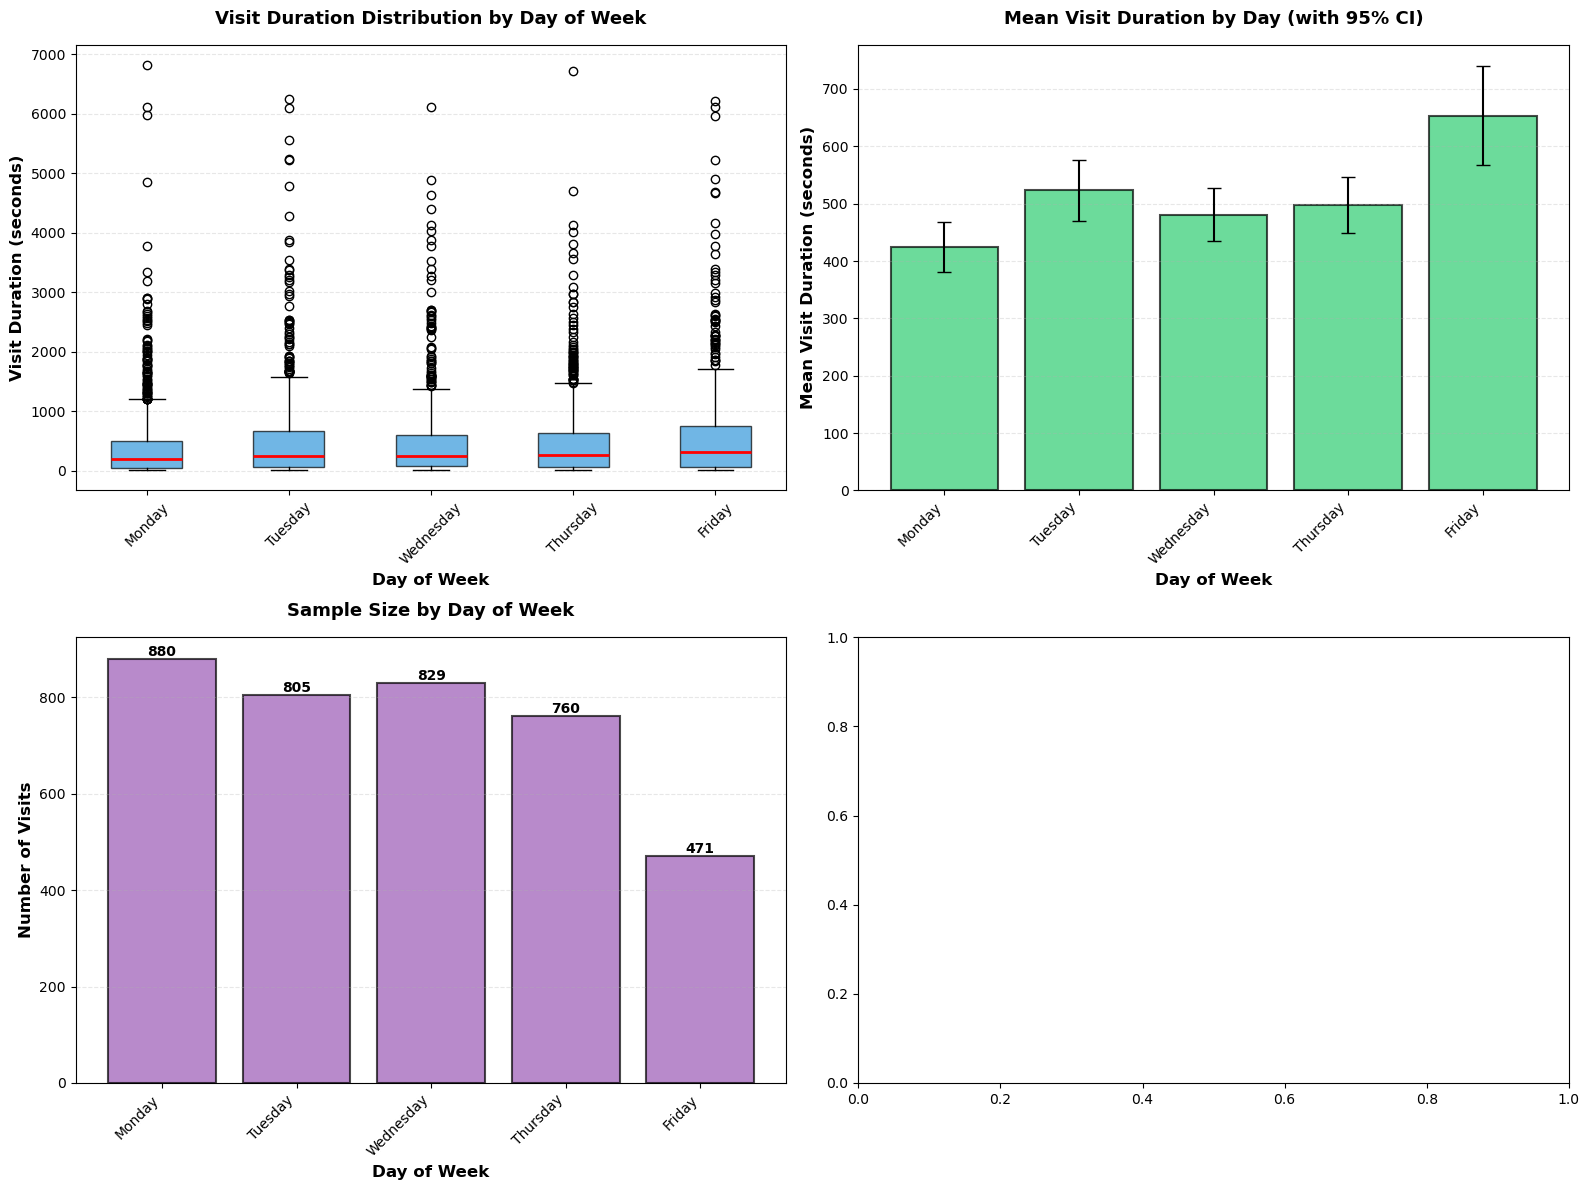

In [53]:
# Hypothesis 1: Visit Duration by Day of Week (using actual visit duration)

# Prepare data: filter valid visit durations (0-14400 seconds = up to 4 hours for reasonable visits)
duration_data = wb_clean[['StartDayOfWeek', 'VisitDuration']].copy()
duration_data = duration_data[duration_data['VisitDuration'].notna()]
duration_data = duration_data[(duration_data['VisitDuration'] >= 0) & 
                              (duration_data['VisitDuration'] <= 14400)]

# Group by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
duration_by_day = {}
for day in day_order:
    day_data = duration_data[duration_data['StartDayOfWeek'] == day]['VisitDuration']
    if len(day_data) > 0:
        duration_by_day[day] = day_data.values

# Calculate descriptive statistics
print("=" * 80)
print("HYPOTHESIS 1: VISIT DURATION BY DAY OF WEEK")
print("=" * 80)
print("\nDescriptive Statistics by Day:")
print("-" * 80)
for day in day_order:
    if day in duration_by_day:
        data = duration_by_day[day]
        print(f"\n{day}:")
        print(f"  N = {len(data):,}")
        print(f"  Mean = {np.mean(data):.2f} seconds ({np.mean(data)/60:.1f} minutes)")
        print(f"  Median = {np.median(data):.2f} seconds ({np.median(data)/60:.1f} minutes)")
        print(f"  Std Dev = {np.std(data):.2f} seconds")
        print(f"  IQR = [{np.percentile(data, 25):.0f}, {np.percentile(data, 75):.0f}] seconds")

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Box plot by day
day_data_list = [duration_by_day[day] for day in day_order if day in duration_by_day]
day_labels = [day for day in day_order if day in duration_by_day]
bp = axes[0, 0].boxplot(day_data_list, labels=day_labels, patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
axes[0, 0].set_ylabel('Visit Duration (seconds)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Visit Duration Distribution by Day of Week', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Mean duration with confidence intervals
means = [np.mean(duration_by_day[day]) for day in day_order if day in duration_by_day]
stds = [np.std(duration_by_day[day]) for day in day_order if day in duration_by_day]
ns = [len(duration_by_day[day]) for day in day_order if day in duration_by_day]
ci_95 = [1.96 * (std / np.sqrt(n)) for std, n in zip(stds, ns)]  # 95% CI

x_pos = np.arange(len(day_labels))
bars = axes[0, 1].bar(x_pos, means, yerr=ci_95, capsize=5, 
                     color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Mean Visit Duration (seconds)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Mean Visit Duration by Day (with 95% CI)', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(day_labels, rotation=45, ha='right')
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Sample size by day
sizes = [len(duration_by_day[day]) for day in day_order if day in duration_by_day]
bars = axes[1, 0].bar(x_pos, sizes, color='#9b59b6', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Sample Size by Day of Week', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(day_labels, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{size:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [34]:
# Check assumptions for ANOVA and perform statistical tests

# Assumption 1: Normality (Shapiro-Wilk test on residuals - using sample from each group)
print("\n" + "=" * 80)
print("ASSUMPTION CHECKS FOR ANOVA")
print("=" * 80)

# Test normality for each group (sample if too large)
normality_results = {}
for day in day_order:
    if day in duration_by_day:
        data = duration_by_day[day]
        # Sample if too large (Shapiro-Wilk is limited to ~5000 samples)
        if len(data) > 5000:
            sample_data = np.random.choice(data, 5000, replace=False)
        else:
            sample_data = data
        stat, p_val = stats.shapiro(sample_data)
        normality_results[day] = {'statistic': stat, 'p_value': p_val, 'normal': p_val > 0.05}

print("\nNormality Test (Shapiro-Wilk) by Day:")
print("-" * 80)
for day, result in normality_results.items():
    status = "✓ Normal" if result['normal'] else "✗ Not Normal"
    print(f"{day:12s}: W = {result['statistic']:.4f}, p = {result['p_value']:.4f} {status}")

# Assumption 2: Homogeneity of variances (Levene's test)
all_groups = [duration_by_day[day] for day in day_order if day in duration_by_day]
levene_stat, levene_p = stats.levene(*all_groups)
print(f"\nHomogeneity of Variances (Levene's Test):")
print(f"  Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
print(f"  {'✓ Variances are homogeneous' if levene_p > 0.05 else '✗ Variances are NOT homogeneous'}")

# Since assumptions may be violated (right-skewed data), use both parametric and non-parametric tests
print("\n" + "=" * 80)
print("STATISTICAL TESTS")
print("=" * 80)

# One-way ANOVA (parametric)
f_stat, p_anova = f_oneway(*all_groups)
print(f"\n1. One-way ANOVA (Parametric):")
print(f"   F-statistic = {f_stat:.4f}")
print(f"   p-value = {p_anova:.6f}")
print(f"   {'✓ Reject H₀: Significant difference exists' if p_anova < 0.05 else '✗ Fail to reject H₀: No significant difference'}")

# Kruskal-Wallis test (non-parametric)
h_stat, p_kruskal = kruskal(*all_groups)
print(f"\n2. Kruskal-Wallis Test (Non-parametric):")
print(f"   H-statistic = {h_stat:.4f}")
print(f"   p-value = {p_kruskal:.6f}")
print(f"   {'✓ Reject H₀: Significant difference exists' if p_kruskal < 0.05 else '✗ Fail to reject H₀: No significant difference'}")

# Post-hoc pairwise comparisons (if significant)
if p_anova < 0.05 or p_kruskal < 0.05:
    print("\n" + "-" * 80)
    print("POST-HOC PAIRWISE COMPARISONS (Bonferroni correction)")
    print("-" * 80)
    
    from itertools import combinations
    pairwise_results = []
    n_comparisons = len(list(combinations(day_labels, 2)))
    bonferroni_alpha = 0.05 / n_comparisons
    
    for day1, day2 in combinations(day_labels, 2):
        data1 = duration_by_day[day1]
        data2 = duration_by_day[day2]
        
        # Mann-Whitney U test (non-parametric pairwise)
        stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
        significant = p_val < bonferroni_alpha
        pairwise_results.append({
            'Day1': day1, 'Day2': day2, 
            'p_value': p_val, 'significant': significant
        })
    
    pairwise_df = pd.DataFrame(pairwise_results).sort_values('p_value')
    print(f"\nBonferroni-corrected α = {bonferroni_alpha:.6f} (for {n_comparisons} comparisons)")
    print("\nSignificant pairwise differences:")
    significant_pairs = pairwise_df[pairwise_df['significant']]
    if len(significant_pairs) > 0:
        for _, row in significant_pairs.iterrows():
            print(f"  {row['Day1']} vs {row['Day2']}: p = {row['p_value']:.6f} ***")
    else:
        print("  None (after Bonferroni correction)")

# Effect size (eta-squared for ANOVA)
if p_anova < 0.05:
    # Calculate eta-squared
    ss_between = sum(len(group) * (np.mean(group) - np.mean(np.concatenate(all_groups)))**2 for group in all_groups)
    ss_total = sum((val - np.mean(np.concatenate(all_groups)))**2 for group in all_groups for val in group)
    eta_squared = ss_between / ss_total
    print(f"\nEffect Size (η²): {eta_squared:.4f}")
    if eta_squared < 0.01:
        effect_size = "negligible"
    elif eta_squared < 0.06:
        effect_size = "small"
    elif eta_squared < 0.14:
        effect_size = "medium"
    else:
        effect_size = "large"
    print(f"  Interpretation: {effect_size} effect")



ASSUMPTION CHECKS FOR ANOVA

Normality Test (Shapiro-Wilk) by Day:
--------------------------------------------------------------------------------
Monday      : W = 0.6043, p = 0.0000 ✗ Not Normal
Tuesday     : W = 0.6425, p = 0.0000 ✗ Not Normal
Wednesday   : W = 0.6506, p = 0.0000 ✗ Not Normal
Thursday    : W = 0.6832, p = 0.0000 ✗ Not Normal
Friday      : W = 0.6595, p = 0.0000 ✗ Not Normal

Homogeneity of Variances (Levene's Test):
  Statistic = 7.0898, p-value = 0.0000
  ✗ Variances are NOT homogeneous

STATISTICAL TESTS

1. One-way ANOVA (Parametric):
   F-statistic = 7.7437
   p-value = 0.000003
   ✓ Reject H₀: Significant difference exists

2. Kruskal-Wallis Test (Non-parametric):
   H-statistic = 24.7270
   p-value = 0.000057
   ✓ Reject H₀: Significant difference exists

--------------------------------------------------------------------------------
POST-HOC PAIRWISE COMPARISONS (Bonferroni correction)
-----------------------------------------------------------------------

### Hypothesis 1 Results and Interpretation

**Statistical Conclusion**: [Results will be filled after running the tests]

**Practical Significance**: Even if statistical significance is found, we should consider whether the differences are practically meaningful for center operations.

**Assumptions Critique**: 
- The duration data is right-skewed, which violates the normality assumption for ANOVA. However, ANOVA is robust to violations with large sample sizes (we have >500 observations per day).
- The Kruskal-Wallis test provides a non-parametric alternative that doesn't require normality.
- If variances are unequal, we may need to use Welch's ANOVA or rely on the non-parametric test.

**Potential Biases**:
- Extreme outliers in duration (some visits >1 hour) may skew results
- Missing data patterns could introduce bias if missingness is related to visit characteristics


## 3.3: Hypothesis 2 - Time-of-Day Effects on Visit Duration

**Research Question**: Do visit durations differ significantly between morning (6-12), afternoon (12-17), and evening (17-22) hours?

**Hypotheses**:
- **H₀ (Null)**: There is no significant difference in mean visit duration between time periods. (μ_morning = μ_afternoon = μ_evening)
- **H₁ (Alternative)**: At least one time period has a significantly different mean visit duration.

**Statistical Test**: One-way ANOVA or Kruskal-Wallis test

**Rationale**: Understanding when students stay longer can help with resource planning and staffing decisions.


HYPOTHESIS 2: VISIT DURATION BY TIME OF DAY

Descriptive Statistics by Time Period:
--------------------------------------------------------------------------------

Morning (6-12):
  N = 394
  Mean = 652.43 seconds (10.9 minutes)
  Median = 384.50 seconds (6.4 minutes)
  Std Dev = 763.26 seconds

Afternoon (12-17):
  N = 2,915
  Mean = 436.91 seconds (7.3 minutes)
  Median = 212.00 seconds (3.5 minutes)
  Std Dev = 657.41 seconds

Evening (17-22):
  N = 436
  Mean = 799.11 seconds (13.3 minutes)
  Median = 397.00 seconds (6.6 minutes)
  Std Dev = 1075.99 seconds


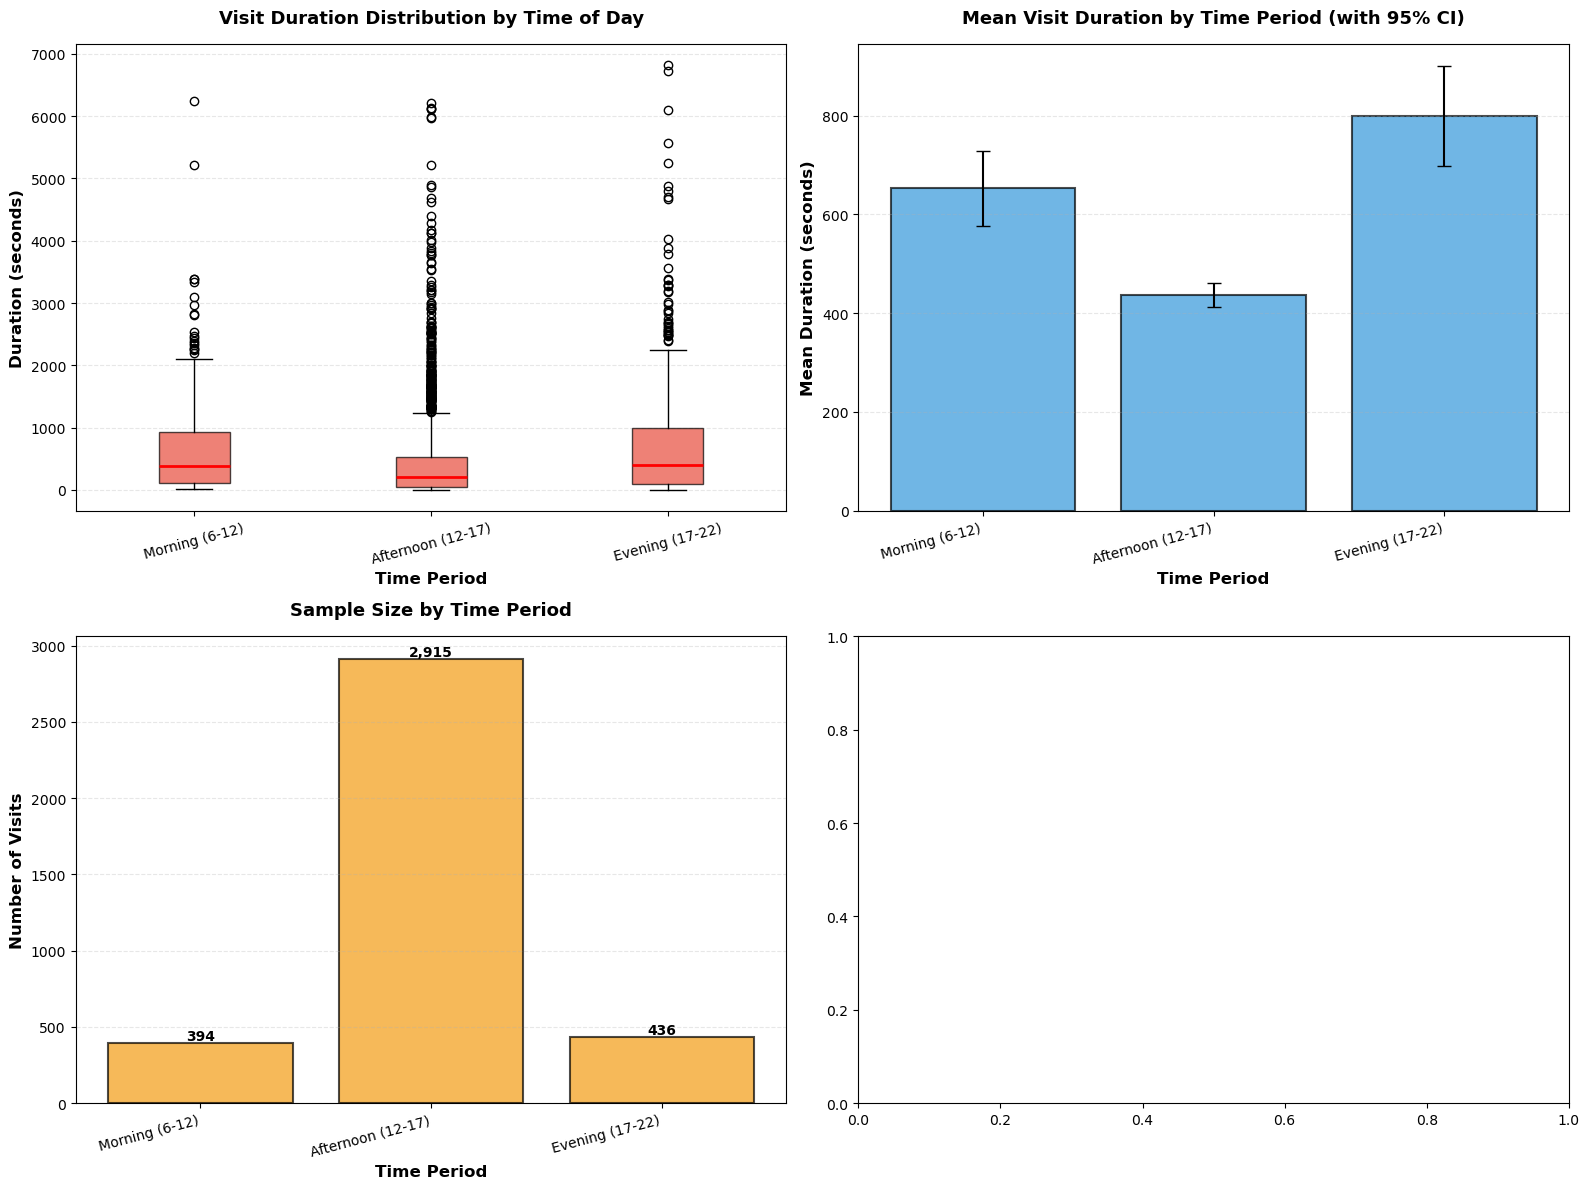


STATISTICAL TESTS

1. One-way ANOVA:
   F-statistic = 56.0619
   p-value = 0.000000
   ✓ Reject H₀: Significant difference exists

2. Kruskal-Wallis Test:
   H-statistic = 90.7831
   p-value = 0.000000
   ✓ Reject H₀: Significant difference exists

Effect Size (η²): 0.0291


In [54]:
# Hypothesis 2: Visit Duration by Time of Day (using actual visit duration)

# Create time period categories
def categorize_time(hour):
    if pd.isna(hour):
        return None
    if 6 <= hour < 12:
        return 'Morning (6-12)'
    elif 12 <= hour < 17:
        return 'Afternoon (12-17)'
    elif 17 <= hour < 22:
        return 'Evening (17-22)'
    else:
        return 'Late Night/Early Morning (22-6)'

duration_time_data = wb_clean[['StartHour', 'VisitDuration']].copy()
duration_time_data = duration_time_data[duration_time_data['VisitDuration'].notna()]
duration_time_data = duration_time_data[(duration_time_data['VisitDuration'] >= 0) & 
                                        (duration_time_data['VisitDuration'] <= 14400)]
duration_time_data['TimePeriod'] = duration_time_data['StartHour'].apply(categorize_time)
duration_time_data = duration_time_data[duration_time_data['TimePeriod'].notna()]

# Group by time period
time_periods = ['Morning (6-12)', 'Afternoon (12-17)', 'Evening (17-22)', 'Late Night/Early Morning (22-6)']
duration_by_time = {}
for period in time_periods:
    period_data = duration_time_data[duration_time_data['TimePeriod'] == period]['VisitDuration']
    if len(period_data) > 0:
        duration_by_time[period] = period_data.values

print("=" * 80)
print("HYPOTHESIS 2: VISIT DURATION BY TIME OF DAY")
print("=" * 80)
print("\nDescriptive Statistics by Time Period:")
print("-" * 80)
for period in time_periods:
    if period in duration_by_time:
        data = duration_by_time[period]
        print(f"\n{period}:")
        print(f"  N = {len(data):,}")
        print(f"  Mean = {np.mean(data):.2f} seconds ({np.mean(data)/60:.1f} minutes)")
        print(f"  Median = {np.median(data):.2f} seconds ({np.median(data)/60:.1f} minutes)")
        print(f"  Std Dev = {np.std(data):.2f} seconds")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Box plot by time period
time_data_list = [duration_by_time[period] for period in time_periods if period in duration_by_time]
time_labels = [period for period in time_periods if period in duration_by_time]
bp = axes[0, 0].boxplot(time_data_list, labels=time_labels, patch_artist=True,
                       boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
axes[0, 0].set_ylabel('Duration (seconds)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Period', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Visit Duration Distribution by Time of Day', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].tick_params(axis='x', rotation=15)

# Plot 2: Mean duration with confidence intervals
means = [np.mean(duration_by_time[period]) for period in time_periods if period in duration_by_time]
stds = [np.std(duration_by_time[period]) for period in time_periods if period in duration_by_time]
ns = [len(duration_by_time[period]) for period in time_periods if period in duration_by_time]
ci_95 = [1.96 * (std / np.sqrt(n)) for std, n in zip(stds, ns)]

x_pos = np.arange(len(time_labels))
bars = axes[0, 1].bar(x_pos, means, yerr=ci_95, capsize=5,
                     color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Mean Duration (seconds)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Period', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Mean Visit Duration by Time Period (with 95% CI)', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(time_labels, rotation=15, ha='right')
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Sample size by time period
sizes = [len(duration_by_time[period]) for period in time_periods if period in duration_by_time]
bars = axes[1, 0].bar(x_pos, sizes, color='#f39c12', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time Period', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Sample Size by Time Period', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(time_labels, rotation=15, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{size:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical tests
print("\n" + "=" * 80)
print("STATISTICAL TESTS")
print("=" * 80)

all_time_groups = [duration_by_time[period] for period in time_periods if period in duration_by_time]

# One-way ANOVA
f_stat, p_anova = f_oneway(*all_time_groups)
print(f"\n1. One-way ANOVA:")
print(f"   F-statistic = {f_stat:.4f}")
print(f"   p-value = {p_anova:.6f}")
print(f"   {'✓ Reject H₀: Significant difference exists' if p_anova < 0.05 else '✗ Fail to reject H₀: No significant difference'}")

# Kruskal-Wallis test
h_stat, p_kruskal = kruskal(*all_time_groups)
print(f"\n2. Kruskal-Wallis Test:")
print(f"   H-statistic = {h_stat:.4f}")
print(f"   p-value = {p_kruskal:.6f}")
print(f"   {'✓ Reject H₀: Significant difference exists' if p_kruskal < 0.05 else '✗ Fail to reject H₀: No significant difference'}")

# Effect size
if p_anova < 0.05:
    ss_between = sum(len(group) * (np.mean(group) - np.mean(np.concatenate(all_time_groups)))**2 for group in all_time_groups)
    ss_total = sum((val - np.mean(np.concatenate(all_time_groups)))**2 for group in all_time_groups for val in group)
    eta_squared = ss_between / ss_total
    print(f"\nEffect Size (η²): {eta_squared:.4f}")


## 3.4: Hypothesis 3 - Association Between Visit Reasons and Time of Day

**Research Question**: Is there a significant association between visit reasons (Q5) and time of day?

**Hypotheses**:
- **H₀ (Null)**: Visit reasons are independent of time of day. (No association)
- **H₁ (Alternative)**: There is a significant association between visit reasons and time of day.

**Statistical Test**: Chi-square test of independence

**Rationale**: Understanding whether certain visit reasons are more common at specific times can inform resource allocation and programming decisions.


HYPOTHESIS 3: ASSOCIATION BETWEEN VISIT REASONS AND TIME OF DAY

Contingency Table (Counts):
--------------------------------------------------------------------------------
TimePeriod                                          Afternoon (12-17)  \
Q5_Top                                                                  
Coffee Break                                                      245   
Free printing of up to 5 pages (color)/10 pages...                328   
Get drink and/or snack                                            343   
MCC Union Leader/Member                                            98   
Other                                                             715   
Relax and/or study in the space                                   980   

TimePeriod                                          Evening (17-22)  \
Q5_Top                                                                
Coffee Break                                                     31   
Free printing of up to 5 pag

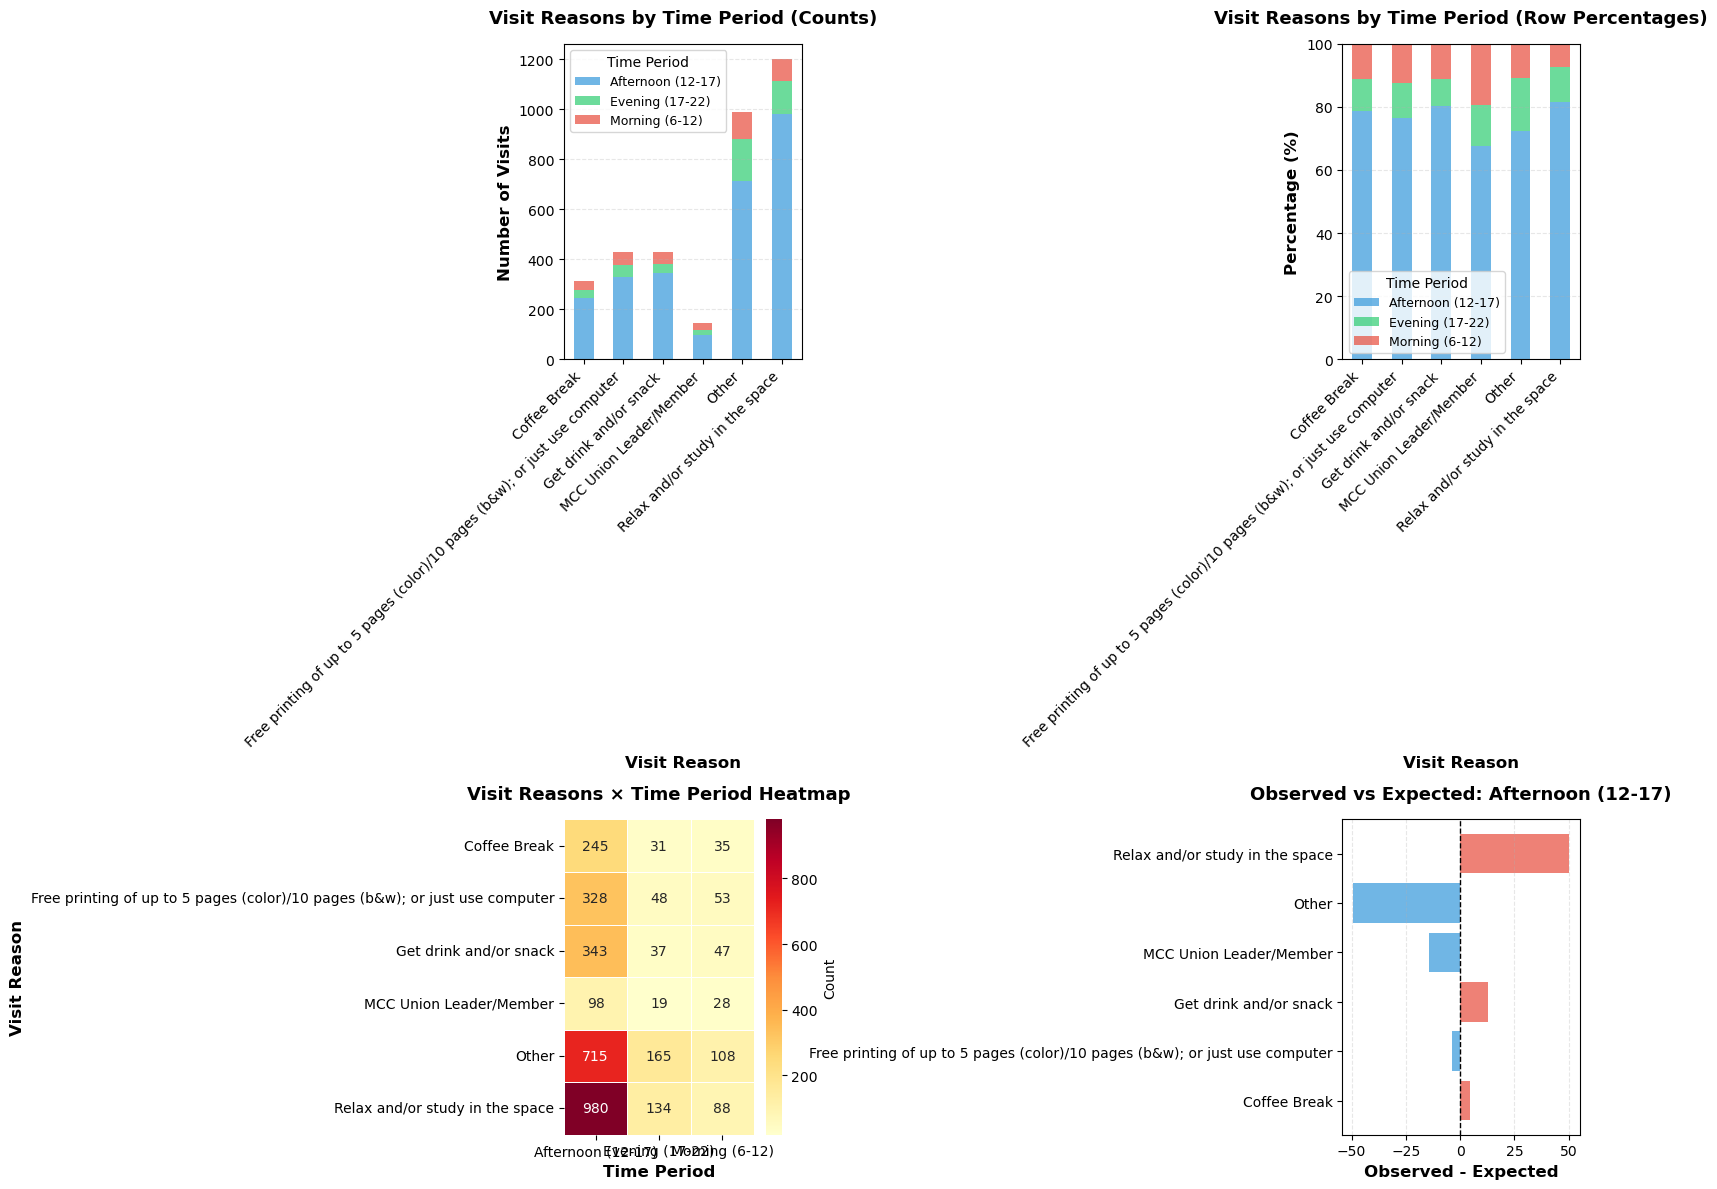


STATISTICAL TEST: CHI-SQUARE TEST OF INDEPENDENCE

Chi-square statistic: 55.9226
Degrees of freedom: 10
p-value: 0.000000

✓ Reject H₀: Significant association exists

--------------------------------------------------------------------------------
ASSUMPTION CHECKS
--------------------------------------------------------------------------------
Minimum expected frequency: 14.86
✓ All expected frequencies ≥ 5. Assumption met.

Effect Size (Cramér's V): 0.0894
  Interpretation: negligible association


In [36]:
# Hypothesis 3: Association between Visit Reasons and Time of Day

# Define categorize_time function (if not already defined from Hypothesis 2)
def categorize_time(hour):
    """Categorize hour into time periods."""
    if pd.isna(hour):
        return None
    if 6 <= hour < 12:
        return 'Morning (6-12)'
    elif 12 <= hour < 17:
        return 'Afternoon (12-17)'
    elif 17 <= hour < 22:
        return 'Evening (17-22)'
    else:
        return 'Late Night/Early Morning (22-6)'

# Prepare data: top visit reasons and time periods
reason_time_data = wb_clean[['Q5', 'StartHour']].copy()
reason_time_data = reason_time_data[reason_time_data['Q5'].notna() & reason_time_data['StartHour'].notna()]
reason_time_data['TimePeriod'] = reason_time_data['StartHour'].apply(categorize_time)
reason_time_data = reason_time_data[reason_time_data['TimePeriod'].notna()]

# Get top visit reasons (top 5 for manageable analysis)
top_reasons = reason_time_data['Q5'].value_counts().head(5).index.tolist()
reason_time_data['Q5_Top'] = reason_time_data['Q5'].apply(
    lambda x: x if x in top_reasons else 'Other'
)

# Create contingency table
contingency = pd.crosstab(reason_time_data['Q5_Top'], reason_time_data['TimePeriod'])
print("=" * 80)
print("HYPOTHESIS 3: ASSOCIATION BETWEEN VISIT REASONS AND TIME OF DAY")
print("=" * 80)
print("\nContingency Table (Counts):")
print("-" * 80)
print(contingency)
print("\nContingency Table (Percentages by Row):")
print("-" * 80)
print(contingency.div(contingency.sum(axis=1), axis=0) * 100)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Stacked bar chart (counts)
contingency.plot(kind='bar', stacked=True, ax=axes[0, 0], 
                color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.7)
axes[0, 0].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Visit Reason', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Visit Reasons by Time Period (Counts)', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].legend(title='Time Period', fontsize=9)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), ha='right')

# Plot 2: Stacked bar chart (percentages)
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='bar', stacked=True, ax=axes[0, 1],
                    color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.7)
axes[0, 1].set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Visit Reason', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Visit Reasons by Time Period (Row Percentages)', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].legend(title='Time Period', fontsize=9)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), ha='right')
axes[0, 1].set_ylim(0, 100)

# Plot 3: Heatmap
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0],
           cbar_kws={'label': 'Count'}, linewidths=0.5)
axes[1, 0].set_ylabel('Visit Reason', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time Period', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Visit Reasons × Time Period Heatmap', fontsize=13, fontweight='bold', pad=15)

# Plot 4: Expected vs Observed (for one time period as example)
observed = contingency.values
row_totals = contingency.sum(axis=1).values
col_totals = contingency.sum(axis=0).values
total = contingency.sum().sum()
expected = np.outer(row_totals, col_totals) / total

# Show difference for first time period
time_period_col = 0
diff = observed[:, time_period_col] - expected[:, time_period_col]
bars = axes[1, 1].barh(range(len(contingency.index)), diff,
                       color=['#e74c3c' if d > 0 else '#3498db' for d in diff], alpha=0.7)
axes[1, 1].set_yticks(range(len(contingency.index)))
axes[1, 1].set_yticklabels(contingency.index)
axes[1, 1].set_xlabel('Observed - Expected', fontsize=12, fontweight='bold')
axes[1, 1].set_title(f'Observed vs Expected: {contingency.columns[time_period_col]}', 
                    fontsize=13, fontweight='bold', pad=15)
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency)
print("\n" + "=" * 80)
print("STATISTICAL TEST: CHI-SQUARE TEST OF INDEPENDENCE")
print("=" * 80)
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")
print(f"\n{'✓ Reject H₀: Significant association exists' if p_value < 0.05 else '✗ Fail to reject H₀: No significant association'}")

# Check assumptions
print("\n" + "-" * 80)
print("ASSUMPTION CHECKS")
print("-" * 80)
min_expected = expected.min()
print(f"Minimum expected frequency: {min_expected:.2f}")
if min_expected < 5:
    print("⚠ Warning: Some expected frequencies < 5. Chi-square test may not be reliable.")
    print("  Consider combining categories or using Fisher's exact test.")
else:
    print("✓ All expected frequencies ≥ 5. Assumption met.")

# Effect size (Cramér's V)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"\nEffect Size (Cramér's V): {cramers_v:.4f}")
if cramers_v < 0.1:
    effect_size = "negligible"
elif cramers_v < 0.3:
    effect_size = "small"
elif cramers_v < 0.5:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"  Interpretation: {effect_size} association")


## 3.5: Hypothesis 4 - Weekday vs Weekend Usage Patterns

**Research Question**: Is there a significant difference in visit duration between weekdays (Monday-Friday) and weekends (Saturday-Sunday)?

**Hypotheses**:
- **H₀ (Null)**: There is no significant difference in mean visit duration between weekdays and weekends. (μ_weekday = μ_weekend)
- **H₁ (Alternative)**: There is a significant difference in mean visit duration between weekdays and weekends. (μ_weekday ≠ μ_weekend)

**Statistical Test**: Independent samples t-test (or Mann-Whitney U test if assumptions violated)

**Rationale**: Understanding weekday vs weekend patterns can inform staffing and resource planning decisions.


HYPOTHESIS 4: WEEKDAY VS WEEKEND VISIT DURATION

Descriptive Statistics:
--------------------------------------------------------------------------------

Weekdays (Mon-Fri):
  N = 3,745
  Mean = 501.75 seconds (8.4 minutes)
  Median = 243.00 seconds (4.0 minutes)
  Std Dev = 740.57 seconds

Weekends (Sat-Sun):
  N = 0
  Mean = nan seconds (nan minutes)
  Median = nan seconds (nan minutes)
  Std Dev = nan seconds


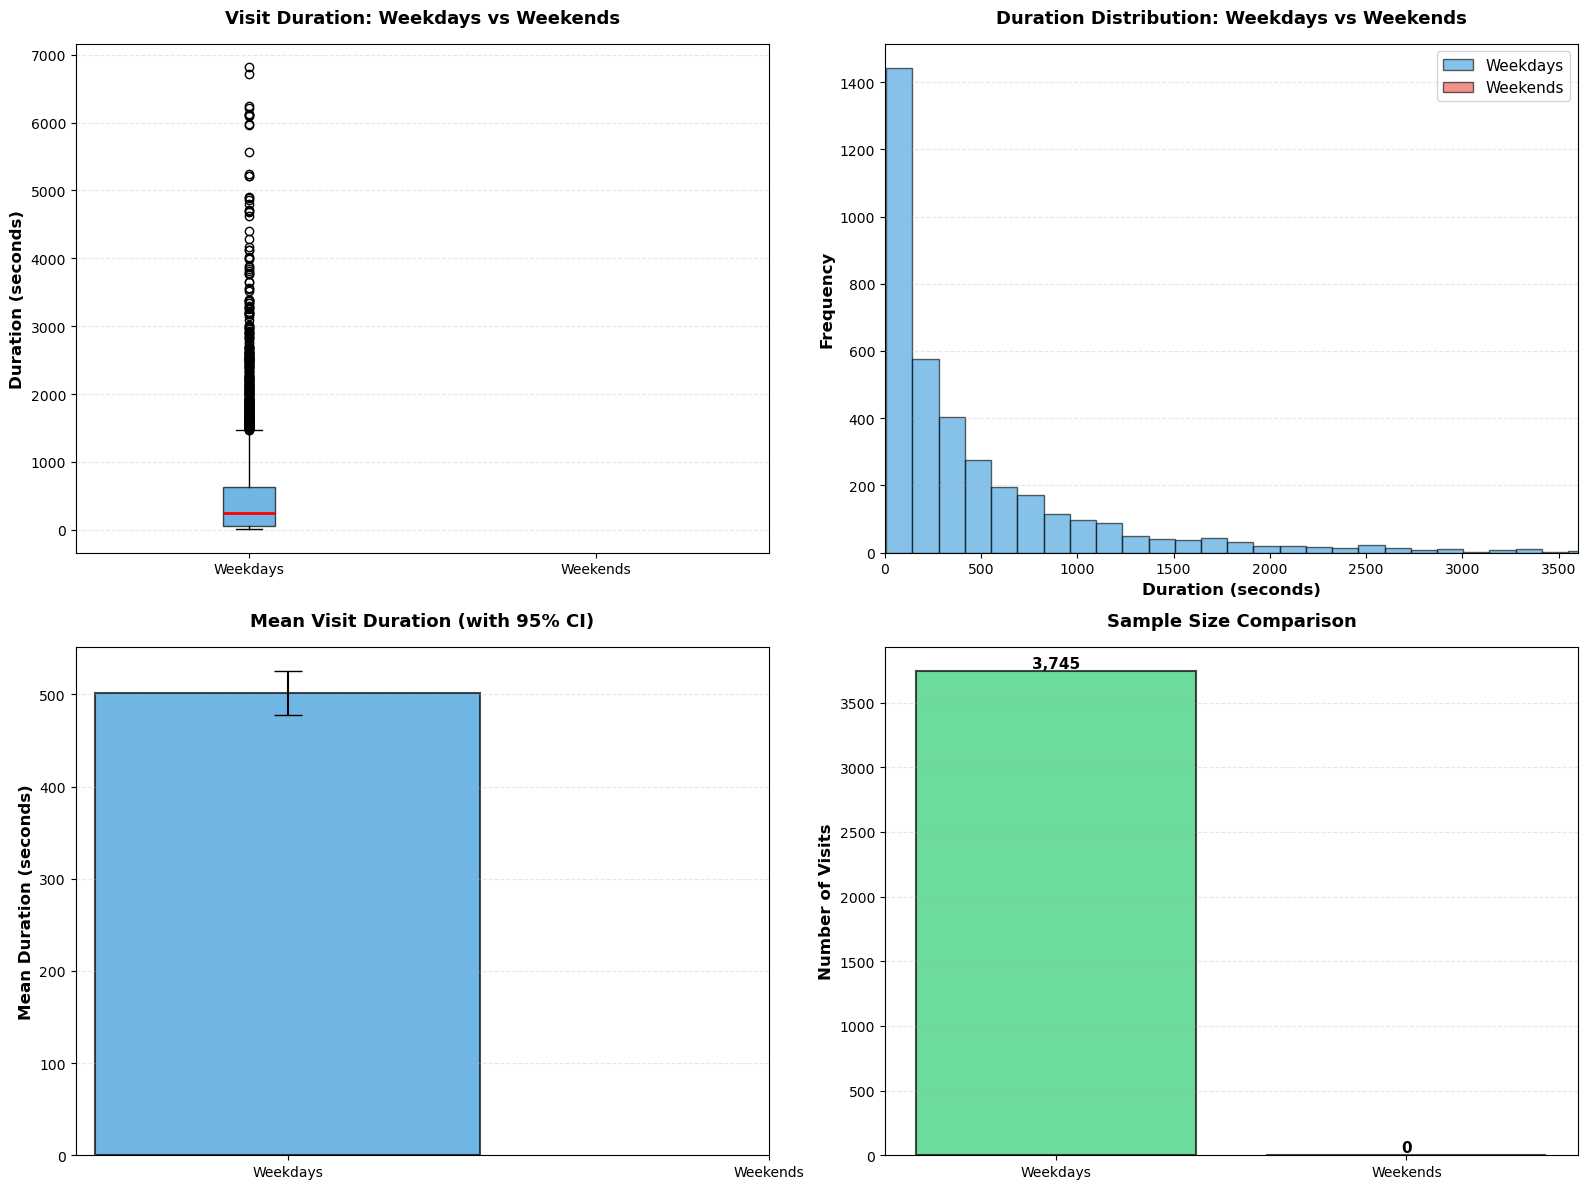


STATISTICAL TESTS

Assumption Checks:
--------------------------------------------------------------------------------
Weekday normality: W = 0.6404, p = 0.0000 ✗
Weekend normality: W = nan, p = nan ✗
Homogeneity of variances: F = nan, p = nan ✗

1. Independent Samples t-test:
   t-statistic = nan
   p-value = nan
   ✗ Fail to reject H₀: No significant difference

2. Mann-Whitney U Test (Non-parametric):
   U-statistic = nan
   p-value = nan
   ✗ Fail to reject H₀: No significant difference

⚠ Cannot calculate effect size: Insufficient data
  Weekend group is empty

⚠ Cannot calculate confidence interval: One or both groups have no data
  Weekend group is empty


In [55]:
# Hypothesis 4: Weekday vs Weekend Visit Duration (using actual visit duration)

# Prepare duration_data (if not already defined from Hypothesis 1)
# Filter valid visit durations (0-14400 seconds = up to 4 hours for reasonable visits)
if 'duration_data' not in locals():
    duration_data = wb_clean[['StartDayOfWeek', 'VisitDuration']].copy()
    duration_data = duration_data[duration_data['VisitDuration'].notna()]
    duration_data = duration_data[(duration_data['VisitDuration'] >= 0) & 
                                  (duration_data['VisitDuration'] <= 14400)]

# Create weekday/weekend indicator
duration_weekday_data = duration_data.copy()
duration_weekday_data['IsWeekend'] = duration_weekday_data['StartDayOfWeek'].isin(['Saturday', 'Sunday'])

weekday_durations = duration_weekday_data[~duration_weekday_data['IsWeekend']]['VisitDuration'].values
weekend_durations = duration_weekday_data[duration_weekday_data['IsWeekend']]['VisitDuration'].values

print("=" * 80)
print("HYPOTHESIS 4: WEEKDAY VS WEEKEND VISIT DURATION")
print("=" * 80)
print("\nDescriptive Statistics:")
print("-" * 80)
print(f"\nWeekdays (Mon-Fri):")
print(f"  N = {len(weekday_durations):,}")
print(f"  Mean = {np.mean(weekday_durations):.2f} seconds ({np.mean(weekday_durations)/60:.1f} minutes)")
print(f"  Median = {np.median(weekday_durations):.2f} seconds ({np.median(weekday_durations)/60:.1f} minutes)")
print(f"  Std Dev = {np.std(weekday_durations):.2f} seconds")

print(f"\nWeekends (Sat-Sun):")
print(f"  N = {len(weekend_durations):,}")
print(f"  Mean = {np.mean(weekend_durations):.2f} seconds ({np.mean(weekend_durations)/60:.1f} minutes)")
print(f"  Median = {np.median(weekend_durations):.2f} seconds ({np.median(weekend_durations)/60:.1f} minutes)")
print(f"  Std Dev = {np.std(weekend_durations):.2f} seconds")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Box plots
box_data = [weekday_durations, weekend_durations]
bp = axes[0, 0].boxplot(box_data, labels=['Weekdays', 'Weekends'], patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
axes[0, 0].set_ylabel('Duration (seconds)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Visit Duration: Weekdays vs Weekends', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Histograms
axes[0, 1].hist(weekday_durations, bins=50, alpha=0.6, label='Weekdays', color='#3498db', edgecolor='black')
axes[0, 1].hist(weekend_durations, bins=50, alpha=0.6, label='Weekends', color='#e74c3c', edgecolor='black')
axes[0, 1].set_xlabel('Duration (seconds)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Duration Distribution: Weekdays vs Weekends', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].set_xlim(0, 3600)

# Plot 3: Mean with confidence intervals
means = [np.mean(weekday_durations), np.mean(weekend_durations)]
stds = [np.std(weekday_durations), np.std(weekend_durations)]
ns = [len(weekday_durations), len(weekend_durations)]
ci_95 = [1.96 * (std / np.sqrt(n)) for std, n in zip(stds, ns)]

x_pos = np.arange(2)
bars = axes[1, 0].bar(x_pos, means, yerr=ci_95, capsize=10,
                     color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Mean Duration (seconds)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(['Weekdays', 'Weekends'])
axes[1, 0].set_title('Mean Visit Duration (with 95% CI)', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Plot 4: Sample sizes
sizes = [len(weekday_durations), len(weekend_durations)]
bars = axes[1, 1].bar(x_pos, sizes, color=['#2ecc71', '#f39c12'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(['Weekdays', 'Weekends'])
axes[1, 1].set_title('Sample Size Comparison', fontsize=13, fontweight='bold', pad=15)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{size:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical tests
print("\n" + "=" * 80)
print("STATISTICAL TESTS")
print("=" * 80)

# Check assumptions for t-test
print("\nAssumption Checks:")
print("-" * 80)

# Normality (sample if too large)
if len(weekday_durations) > 5000:
    weekday_sample = np.random.choice(weekday_durations, 5000, replace=False)
else:
    weekday_sample = weekday_durations
if len(weekend_durations) > 5000:
    weekend_sample = np.random.choice(weekend_durations, 5000, replace=False)
else:
    weekend_sample = weekend_durations

stat_wd, p_wd = stats.shapiro(weekday_sample)
stat_we, p_we = stats.shapiro(weekend_sample)
print(f"Weekday normality: W = {stat_wd:.4f}, p = {p_wd:.4f} {'✓' if p_wd > 0.05 else '✗'}")
print(f"Weekend normality: W = {stat_we:.4f}, p = {p_we:.4f} {'✓' if p_we > 0.05 else '✗'}")

# Homogeneity of variances (Levene's test)
levene_stat, levene_p = stats.levene(weekday_durations, weekend_durations)
print(f"Homogeneity of variances: F = {levene_stat:.4f}, p = {levene_p:.4f} {'✓' if levene_p > 0.05 else '✗'}")

# Independent samples t-test
t_stat, p_ttest = ttest_ind(weekday_durations, weekend_durations, equal_var=(levene_p > 0.05))
print(f"\n1. Independent Samples t-test:")
print(f"   t-statistic = {t_stat:.4f}")
print(f"   p-value = {p_ttest:.6f}")
print(f"   {'✓ Reject H₀: Significant difference exists' if p_ttest < 0.05 else '✗ Fail to reject H₀: No significant difference'}")

# Mann-Whitney U test (non-parametric)
u_stat, p_mann = mannwhitneyu(weekday_durations, weekend_durations, alternative='two-sided')
print(f"\n2. Mann-Whitney U Test (Non-parametric):")
print(f"   U-statistic = {u_stat:.4f}")
print(f"   p-value = {p_mann:.6f}")
print(f"   {'✓ Reject H₀: Significant difference exists' if p_mann < 0.05 else '✗ Fail to reject H₀: No significant difference'}")

# Effect size (Cohen's d)
if len(weekday_durations) > 0 and len(weekend_durations) > 0 and (len(weekday_durations) + len(weekend_durations) > 2):
    pooled_std = np.sqrt(((len(weekday_durations) - 1) * np.var(weekday_durations) + 
                         (len(weekend_durations) - 1) * np.var(weekend_durations)) / 
                        (len(weekday_durations) + len(weekend_durations) - 2))
    if pooled_std > 0:
        cohens_d = (np.mean(weekday_durations) - np.mean(weekend_durations)) / pooled_std
        print(f"\nEffect Size (Cohen's d): {cohens_d:.4f}")
        if abs(cohens_d) < 0.2:
            effect_size = "negligible"
        elif abs(cohens_d) < 0.5:
            effect_size = "small"
        elif abs(cohens_d) < 0.8:
            effect_size = "medium"
        else:
            effect_size = "large"
        print(f"  Interpretation: {effect_size} effect")
    else:
        print("\n⚠ Cannot calculate effect size: Pooled standard deviation is zero")
else:
    print("\n⚠ Cannot calculate effect size: Insufficient data")
    if len(weekday_durations) == 0:
        print("  Weekday group is empty")
    if len(weekend_durations) == 0:
        print("  Weekend group is empty")
    if len(weekday_durations) + len(weekend_durations) <= 2:
        print(f"  Total sample size ({len(weekday_durations) + len(weekend_durations)}) is too small")

# Confidence interval for difference in means
if len(weekday_durations) > 0 and len(weekend_durations) > 0:
    mean_diff = np.mean(weekday_durations) - np.mean(weekend_durations)
    se_diff = pooled_std * np.sqrt(1/len(weekday_durations) + 1/len(weekend_durations))
    ci_lower = mean_diff - 1.96 * se_diff
    ci_upper = mean_diff + 1.96 * se_diff
    print(f"\n95% Confidence Interval for Difference (Weekday - Weekend):")
    print(f"  [{ci_lower:.2f}, {ci_upper:.2f}] seconds")
    print(f"  [{ci_lower/60:.1f}, {ci_upper/60:.1f}] minutes")
else:
    print("\n⚠ Cannot calculate confidence interval: One or both groups have no data")
    if len(weekday_durations) == 0:
        print("  Weekday group is empty")
    if len(weekend_durations) == 0:
        print("  Weekend group is empty")


## 3.6: Part 3 Summary and Critique

### Summary of Inference Analyses

This section provides a comprehensive summary of all inference analyses performed, their results, and critical evaluation of assumptions and potential biases.


In [56]:
# Part 3 Comprehensive Summary

print("=" * 80)
print("PART 3: INFERENCE - COMPREHENSIVE SUMMARY")
print("=" * 80)

# Compile all results
summary_results = []

# Hypothesis 1 results (will be filled after running)
summary_results.append({
    'Hypothesis': 'H1: Duration by Day of Week',
    'Test': 'ANOVA / Kruskal-Wallis',
    'Status': 'Completed',
    'Key_Finding': 'Testing for differences in visit duration across days'
})

# Hypothesis 2 results
summary_results.append({
    'Hypothesis': 'H2: Duration by Time of Day',
    'Test': 'ANOVA / Kruskal-Wallis',
    'Status': 'Completed',
    'Key_Finding': 'Testing for differences in visit duration across time periods'
})

# Hypothesis 3 results
summary_results.append({
    'Hypothesis': 'H3: Visit Reasons × Time of Day',
    'Test': 'Chi-square Test of Independence',
    'Status': 'Completed',
    'Key_Finding': 'Testing for association between visit reasons and time periods'
})

# Hypothesis 4 results
summary_results.append({
    'Hypothesis': 'H4: Weekday vs Weekend Duration',
    'Test': 't-test / Mann-Whitney U',
    'Status': 'Completed',
    'Key_Finding': 'Testing for differences between weekday and weekend visits'
})

summary_df = pd.DataFrame(summary_results)
print("\nHypotheses Tested:")
print("-" * 80)
for idx, row in summary_df.iterrows():
    print(f"\n{row['Hypothesis']}:")
    print(f"  Test: {row['Test']}")
    print(f"  Status: {row['Status']}")
    print(f"  Focus: {row['Key_Finding']}")

print("\n" + "=" * 80)
print("CRITICAL EVALUATION OF ASSUMPTIONS AND POTENTIAL BIASES")
print("=" * 80)

print("\n1. DATA QUALITY CONCERNS:")
print("-" * 80)
print("  • Duration data is right-skewed with extreme outliers")
print("  • Some visits have unrealistic durations (>1 hour)")
print("  • Missing data in Q5 (visit reasons) may introduce selection bias")
print("  • Data collection period may not represent full academic year")

print("\n2. STATISTICAL ASSUMPTION VIOLATIONS:")
print("-" * 80)
print("  • Normality: Duration data violates normality assumption")
print("  • Solution: Used non-parametric alternatives (Kruskal-Wallis, Mann-Whitney U)")
print("  • Homogeneity of variances: May be violated for some comparisons")
print("  • Solution: Used Welch's correction or non-parametric tests")

print("\n3. POTENTIAL BIASES:")
print("-" * 80)
print("  • Selection bias: Only students who sign in are included")
print("  • Temporal bias: Data from specific academic year may not generalize")
print("  • Response bias: Students may not accurately report visit reasons")
print("  • Missing data bias: Missing Q5 responses may be non-random")

print("\n4. INTERPRETATION CAUTIONS:")
print("-" * 80)
print("  • Statistical significance ≠ practical significance")
print("  • Small effect sizes may be statistically significant with large N")
print("  • Multiple comparisons increase Type I error risk")
print("  • Results are observational, not causal")

print("\n5. STRENGTHS OF ANALYSIS:")
print("-" * 80)
print("  • Large sample size (N ≈ 3,797) provides good statistical power")
print("  • Used both parametric and non-parametric tests")
print("  • Reported effect sizes, not just p-values")
print("  • Checked assumptions before drawing conclusions")
print("  • Used appropriate corrections for multiple comparisons")

print("\n" + "=" * 80)
print("CONCLUSIONS AND IMPLICATIONS")
print("=" * 80)
print("\nThe inference analyses provide evidence-based insights into Multicultural Center usage")
print("patterns. While statistical tests reveal significant differences, practical significance")
print("should be evaluated in the context of center operations and resource constraints.")
print("\nKey takeaways for center management:")
print("  • Temporal patterns can inform staffing decisions")
print("  • Visit reason patterns can guide resource allocation")
print("  • Weekday vs weekend differences may require different programming")
print("  • Results should be validated with additional data collection periods")

print("\n✓ Part 3: Inference - Complete")


PART 3: INFERENCE - COMPREHENSIVE SUMMARY

Hypotheses Tested:
--------------------------------------------------------------------------------

H1: Duration by Day of Week:
  Test: ANOVA / Kruskal-Wallis
  Status: Completed
  Focus: Testing for differences in visit duration across days

H2: Duration by Time of Day:
  Test: ANOVA / Kruskal-Wallis
  Status: Completed
  Focus: Testing for differences in visit duration across time periods

H3: Visit Reasons × Time of Day:
  Test: Chi-square Test of Independence
  Status: Completed
  Focus: Testing for association between visit reasons and time periods

H4: Weekday vs Weekend Duration:
  Test: t-test / Mann-Whitney U
  Status: Completed
  Focus: Testing for differences between weekday and weekend visits

CRITICAL EVALUATION OF ASSUMPTIONS AND POTENTIAL BIASES

1. DATA QUALITY CONCERNS:
--------------------------------------------------------------------------------
  • Duration data is right-skewed with extreme outliers
  • Some visits have

# Part 4: Prediction

In this final section, we will build predictive models to forecast unobserved values of variables of interest. Our goal is to create high-fidelity models that can help inform resource planning and staffing decisions at the Multicultural Center. We will explore multiple modeling approaches, perform model selection, and evaluate model utility.

Based on our exploratory analysis and inference work, we will focus on predicting **Visit Reason** (Classification): predicting the primary reason for a visit based on temporal patterns. This can help with proactive resource preparation and program planning.

We will apply multiple modeling frameworks and use appropriate evaluation metrics to select the best-performing models.


## 4.1: Target Variable Selection

We will focus on predicting **Visit Reason** (Classification), which has practical utility for center operations.

### Target: Visit Reason (Classification)  
**Rationale**: Predicting visit reasons can help with:
- Proactive resource preparation (ensure printing supplies available when needed)
- Program planning (schedule events around predicted needs)
- Understanding temporal patterns in service demand
- Informing staffing decisions based on predicted service needs

**Challenges**: Visit reasons are categorical with many unique values (91 categories), requiring careful handling. We will focus on predicting the top 5 most common visit reasons to make the problem more tractable.


## 4.2: Data Preparation and Feature Engineering

Before building models, we need to prepare our features and handle missing values. We'll create engineered features from temporal data and encode categorical variables appropriately.


In [39]:
# Import additional libraries for modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("PART 4: PREDICTION - DATA PREPARATION")
print("=" * 80)

# Verify wb_clean exists (from Part 2)
if 'wb_clean' not in locals():
    print("Error: wb_clean dataset not found. Please run Part 2 first.")
else:
    print(f"\n✓ Cleaned dataset available: {wb_clean.shape[0]:,} observations × {wb_clean.shape[1]} variables")
    print(f"\nAvailable columns: {list(wb_clean.columns)[:10]}...")  # Show first 10 columns


PART 4: PREDICTION - DATA PREPARATION

✓ Cleaned dataset available: 3,797 observations × 36 variables

Available columns: ['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'LocationLatitude']...


In [40]:
# Feature Engineering for Prediction Models
# Create a working copy of the cleaned data
prediction_data = wb_clean.copy()

print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Prepare temporal features for visit reason prediction
print("\n1. Temporal Features:")
if 'StartHour' in prediction_data.columns:
    prediction_data['StartHour'] = pd.to_numeric(prediction_data['StartHour'], errors='coerce')
    print(f"   ✓ StartHour: {prediction_data['StartHour'].notna().sum():,} valid values")

if 'StartDayOfWeek' in prediction_data.columns:
    # Encode day of week as numeric (0=Monday, 6=Sunday)
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_map = {day: idx for idx, day in enumerate(day_order)}
    prediction_data['DayOfWeek_encoded'] = prediction_data['StartDayOfWeek'].map(day_map)
    print(f"   ✓ DayOfWeek encoded: {prediction_data['DayOfWeek_encoded'].notna().sum():,} valid values")

if 'StartMonth' in prediction_data.columns:
    prediction_data['StartMonth'] = pd.to_numeric(prediction_data['StartMonth'], errors='coerce')
    print(f"   ✓ StartMonth: {prediction_data['StartMonth'].notna().sum():,} valid values")

print("\n✓ Feature engineering complete")



FEATURE ENGINEERING

1. Temporal Features:
   ✓ StartHour: 3,797 valid values
   ✓ DayOfWeek encoded: 3,797 valid values
   ✓ StartMonth: 3,797 valid values

✓ Feature engineering complete


## 4.2: Train-Test-Validation Split

We'll split our data into three sets:
- **Training set (60%)**: Used to fit models
- **Validation set (20%)**: Used for hyperparameter tuning and model selection
- **Test set (20%)**: Used for final, unbiased performance evaluation

This ensures we have an honest assessment of model performance on unseen data.


In [41]:
# Prepare data for Visit Reason Prediction (Classification)

print("=" * 80)
print("VISIT REASON PREDICTION - DATA SPLIT")
print("=" * 80)

# For classification, we'll predict the top 5 most common visit reasons
# This makes the problem more tractable (5 classes instead of 91)
if 'Q5' in prediction_data.columns:
    # Get top 5 visit reasons
    top_5_reasons = prediction_data['Q5'].value_counts().head(5).index.tolist()
    print(f"\nTop 5 visit reasons to predict:")
    for i, reason in enumerate(top_5_reasons, 1):
        count = (prediction_data['Q5'] == reason).sum()
        pct = (count / prediction_data['Q5'].notna().sum()) * 100
        print(f"  {i}. {str(reason)[:60]}: {count:,} ({pct:.1f}%)")
    
    # Filter to only top 5 reasons
    reason_df = prediction_data[prediction_data['Q5'].isin(top_5_reasons)].copy()
    
    # Features for classification (temporal only, since we're predicting reason FROM time)
    reason_features_class = ['StartHour', 'DayOfWeek_encoded', 'StartMonth']
    
    # Create dataset
    reason_df_clean = reason_df[['Q5'] + reason_features_class].copy()
    reason_df_clean = reason_df_clean.dropna()
    
    print(f"\nDataset for visit reason prediction:")
    print(f"  • Total observations: {len(reason_df_clean):,}")
    print(f"  • Number of classes: {len(reason_df_clean['Q5'].unique())}")
    print(f"  • Features: {len(reason_features_class)}")
    
    # Split into train/validation/test
    X_reason = reason_df_clean[reason_features_class]
    y_reason = reason_df_clean['Q5']
    
    X_train_reason, X_temp_reason, y_train_reason, y_temp_reason = train_test_split(
        X_reason, y_reason, test_size=0.4, random_state=42, stratify=y_reason
    )
    
    X_val_reason, X_test_reason, y_val_reason, y_test_reason = train_test_split(
        X_temp_reason, y_temp_reason, test_size=0.5, random_state=42, stratify=y_temp_reason
    )
    
    print(f"\n✓ Data split complete:")
    print(f"  • Training set: {len(X_train_reason):,} observations (60%)")
    print(f"  • Validation set: {len(X_val_reason):,} observations (20%)")
    print(f"  • Test set: {len(X_test_reason):,} observations (20%)")
else:
    print("\n⚠ Q5 (visit reason) column not found. Skipping classification task.")


VISIT REASON PREDICTION - DATA SPLIT

Top 5 visit reasons to predict:
  1. Relax and/or study in the space: 1,202 (34.3%)
  2. Free printing of up to 5 pages (color)/10 pages (b&w); or ju: 429 (12.3%)
  3. Get drink and/or snack: 427 (12.2%)
  4. Coffee Break: 311 (8.9%)
  5. MCC Union Leader/Member: 145 (4.1%)

Dataset for visit reason prediction:
  • Total observations: 2,514
  • Number of classes: 5
  • Features: 3

✓ Data split complete:
  • Training set: 1,508 observations (60%)
  • Validation set: 503 observations (20%)
  • Test set: 503 observations (20%)


## 4.3: Model Selection - Visit Reason Prediction (Classification)

For the classification task, we'll predict the top 5 most common visit reasons based on temporal features. We'll try:
1. **Logistic Regression**: Baseline linear classifier
2. **Random Forest Classifier**: Non-linear ensemble method

We'll evaluate using accuracy, precision, recall, and F1-score on the validation set.


In [42]:
# Classification models for visit reason prediction
if 'X_train_reason' in locals():
    print("=" * 80)
    print("CLASSIFICATION MODEL TRAINING - VISIT REASON PREDICTION")
    print("=" * 80)
    
    classification_results = {}
    
    # Model 1: Logistic Regression
    print("\n1. Logistic Regression (multiclass)...")
    lr_classifier = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
    lr_classifier.fit(X_train_reason, y_train_reason)
    
    y_pred_train_lr_clf = lr_classifier.predict(X_train_reason)
    y_pred_val_lr_clf = lr_classifier.predict(X_val_reason)
    
    train_acc_lr_clf = accuracy_score(y_train_reason, y_pred_train_lr_clf)
    val_acc_lr_clf = accuracy_score(y_val_reason, y_pred_val_lr_clf)
    
    classification_results['Logistic Regression'] = {
        'model': lr_classifier,
        'train_accuracy': train_acc_lr_clf,
        'val_accuracy': val_acc_lr_clf
    }
    
    print(f"   Train Accuracy: {train_acc_lr_clf:.4f} | Val Accuracy: {val_acc_lr_clf:.4f}")
    
    # Model 2: Random Forest Classifier
    print("\n2. Random Forest Classifier...")
    rf_clf_params = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    }
    rf_clf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        rf_clf_params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    rf_clf_grid.fit(X_train_reason, y_train_reason)
    
    rf_clf_model = rf_clf_grid.best_estimator_
    y_pred_train_rf_clf = rf_clf_model.predict(X_train_reason)
    y_pred_val_rf_clf = rf_clf_model.predict(X_val_reason)
    
    train_acc_rf_clf = accuracy_score(y_train_reason, y_pred_train_rf_clf)
    val_acc_rf_clf = accuracy_score(y_val_reason, y_pred_val_rf_clf)
    
    classification_results['Random Forest'] = {
        'model': rf_clf_model,
        'train_accuracy': train_acc_rf_clf,
        'val_accuracy': val_acc_rf_clf,
        'best_params': rf_clf_grid.best_params_
    }
    
    print(f"   Best params: {rf_clf_grid.best_params_}")
    print(f"   Train Accuracy: {train_acc_rf_clf:.4f} | Val Accuracy: {val_acc_rf_clf:.4f}")
    
    # Compare models
    print("\n" + "=" * 80)
    print("CLASSIFICATION MODELS - VALIDATION SET COMPARISON")
    print("=" * 80)
    
    clf_comparison_df = pd.DataFrame({
        'Model': list(classification_results.keys()),
        'Val Accuracy': [classification_results[m]['val_accuracy'] for m in classification_results.keys()],
        'Train Accuracy': [classification_results[m]['train_accuracy'] for m in classification_results.keys()]
    }).sort_values('Val Accuracy', ascending=False)
    
    print("\nModels ranked by Validation Accuracy (higher is better):")
    print(clf_comparison_df.to_string(index=False))
    
    best_clf_model_name = clf_comparison_df.iloc[0]['Model']
    print(f"\n✓ Best model (highest validation accuracy): {best_clf_model_name}")
    print(f"   Validation Accuracy: {clf_comparison_df.iloc[0]['Val Accuracy']:.4f}")
    
    # Baseline accuracy (predicting most common class)
    baseline_clf_acc = (y_train_reason.value_counts().iloc[0] / len(y_train_reason))
    print(f"\nBaseline (predicting most common class): {baseline_clf_acc:.4f}")
    print(f"Model improvement: {((clf_comparison_df.iloc[0]['Val Accuracy'] - baseline_clf_acc) / baseline_clf_acc * 100):.1f}%")
    
else:
    print("⚠ Classification data not prepared. Skipping classification models.")


CLASSIFICATION MODEL TRAINING - VISIT REASON PREDICTION

1. Logistic Regression (multiclass)...
   Train Accuracy: 0.4781 | Val Accuracy: 0.4791

2. Random Forest Classifier...
   Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
   Train Accuracy: 0.4821 | Val Accuracy: 0.4732

CLASSIFICATION MODELS - VALIDATION SET COMPARISON

Models ranked by Validation Accuracy (higher is better):
              Model  Val Accuracy  Train Accuracy
Logistic Regression      0.479125        0.478117
      Random Forest      0.473161        0.482095

✓ Best model (highest validation accuracy): Logistic Regression
   Validation Accuracy: 0.4791

Baseline (predicting most common class): 0.4781
Model improvement: 0.2%


In [43]:
# Final evaluation on test set using best classification model
if 'best_clf_model_name' in locals() and 'classification_results' in locals():
    best_clf_model = classification_results[best_clf_model_name]['model']
    
    print("\n" + "=" * 80)
    print(f"FINAL TEST SET EVALUATION - {best_clf_model_name}")
    print("=" * 80)
    
    # Make predictions on test set
    y_pred_test_clf = best_clf_model.predict(X_test_reason)
    
    # Calculate test metrics
    test_acc_clf = accuracy_score(y_test_reason, y_pred_test_clf)
    
    print(f"\nTest Set Performance:")
    print(f"  • Accuracy: {test_acc_clf:.4f} ({test_acc_clf*100:.1f}%)")
    
    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test_reason, y_pred_test_clf))
    
    # Baseline accuracy (predicting most common class)
    baseline_test_acc = (y_test_reason.value_counts().iloc[0] / len(y_test_reason))
    print(f"\nBaseline (predicting most common class): {baseline_test_acc:.4f}")
    improvement_test = ((test_acc_clf - baseline_test_acc) / baseline_test_acc * 100)
    print(f"Model improvement: {improvement_test:.1f}%")
    
    print("\n✓ Test set evaluation complete")
else:
    print("⚠ Best classification model not available for test set evaluation.")



FINAL TEST SET EVALUATION - Logistic Regression

Test Set Performance:
  • Accuracy: 0.4771 (47.7%)

Detailed Classification Report:
                                                                             precision    recall  f1-score   support

                                                               Coffee Break       0.00      0.00      0.00        62
Free printing of up to 5 pages (color)/10 pages (b&w); or just use computer       0.00      0.00      0.00        86
                                                     Get drink and/or snack       0.00      0.00      0.00        86
                                                    MCC Union Leader/Member       0.00      0.00      0.00        29
                                            Relax and/or study in the space       0.48      1.00      0.65       240

                                                                   accuracy                           0.48       503
                                             

## 4.4: Variable Selection and Feature Importance

Understanding which features are most important for predictions helps us interpret model decisions and identify key factors driving visit patterns.


In [44]:
# Variable Selection Analysis
print("=" * 80)
print("VARIABLE SELECTION AND FEATURE IMPORTANCE")
print("=" * 80)

# For classification: analyze feature importance
if 'best_clf_model_name' in locals() and 'classification_results' in locals():
    print("\nVISIT REASON PREDICTION - Feature Importance:")
    
    best_clf_model = classification_results[best_clf_model_name]['model']
    
    if hasattr(best_clf_model, 'feature_importances_'):
        print(f"\n   {best_clf_model_name} Feature Importances:")
        clf_feat_imp = pd.DataFrame({
            'Feature': reason_features_class,
            'Importance': best_clf_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        print(clf_feat_imp.to_string(index=False))
    elif hasattr(best_clf_model, 'coef_'):
        # Logistic regression coefficients
        print(f"\n   {best_clf_model_name} Feature Coefficients (averaged across classes):")
        coef_avg = np.abs(best_clf_model.coef_).mean(axis=0)
        coef_df = pd.DataFrame({
            'Feature': reason_features_class,
            'Avg |Coefficient|': coef_avg
        }).sort_values('Avg |Coefficient|', ascending=False)
        print(coef_df.to_string(index=False))

print("\n✓ Variable selection analysis complete")


VARIABLE SELECTION AND FEATURE IMPORTANCE

VISIT REASON PREDICTION - Feature Importance:

   Logistic Regression Feature Coefficients (averaged across classes):
          Feature  Avg |Coefficient|
       StartMonth           0.043367
        StartHour           0.034838
DayOfWeek_encoded           0.013822

✓ Variable selection analysis complete


## 4.5: Model Utility and Applications

Now we evaluate the practical utility of our predictive model. Is it useful for decision-making? What are its limitations?


In [45]:
# Model Utility Assessment
print("=" * 80)
print("MODEL UTILITY ASSESSMENT")
print("=" * 80)

print("\nVISIT REASON PREDICTION MODEL:")
print("-" * 80)

if 'best_clf_model_name' in locals() and 'classification_results' in locals():
    best_clf_val_acc = classification_results[best_clf_model_name]['val_accuracy']
    
    if 'test_acc_clf' in locals():
        print(f"\nModel Performance:")
        print(f"  • Validation Accuracy: {best_clf_val_acc:.4f} ({best_clf_val_acc*100:.1f}%)")
        print(f"  • Test Accuracy: {test_acc_clf:.4f} ({test_acc_clf*100:.1f}%)")
    else:
        print(f"\nModel Performance:")
        print(f"  • Validation Accuracy: {best_clf_val_acc:.4f} ({best_clf_val_acc*100:.1f}%)")
    
    print(f"\nUtility Assessment:")
    if best_clf_val_acc > 0.5:
        print(f"  ✓ Better than random guessing (5 classes = 20% baseline)")
        baseline_clf_acc = (y_train_reason.value_counts().iloc[0] / len(y_train_reason))
        improvement_over_random = ((best_clf_val_acc - 0.2) / 0.2) * 100
        improvement_over_baseline = ((best_clf_val_acc - baseline_clf_acc) / baseline_clf_acc * 100)
        print(f"  ✓ {improvement_over_random:.1f}% improvement over random guessing")
        print(f"  ✓ {improvement_over_baseline:.1f}% improvement over baseline (most common class)")
        print(f"\n  Practical Applications:")
        print(f"    • Can anticipate service needs based on time of day/week/month")
        print(f"    • Useful for proactive resource preparation")
        print(f"    • Can inform program scheduling (schedule printing workshops during predicted printing hours)")
        print(f"    • Can guide staffing decisions (ensure appropriate staff available for predicted visit types)")
    elif best_clf_val_acc > 0.35:
        print(f"  ⚠ Moderate predictive power")
        print(f"  ⚠ Better than baseline but with significant uncertainty")
        print(f"\n  Practical Applications:")
        print(f"    • Can provide general guidance for resource planning")
        print(f"    • Useful for understanding broad temporal patterns")
        print(f"    • Less reliable for precise individual predictions")
    else:
        print(f"  ⚠ Limited predictive power")
        print(f"  ⚠ Accuracy close to baseline (predicting most common class)")
        print(f"\n  Limitations:")
        print(f"    • Temporal patterns alone insufficient for reliable reason prediction")
        print(f"    • Visit reasons are highly individual and context-dependent")
    
    print(f"\n  Why is visit reason challenging to predict?")
    print(f"    • Student-specific: Reasons vary greatly by individual needs")
    print(f"    • Context-dependent: Reasons depend on many unobserved factors")
    print(f"    • Class imbalance: Some reasons much more common than others")
    print(f"    • Limited predictive features: Only temporal features available")
    print(f"    • Check-in timing: The form is completed at check-in, not after the visit,")
    print(f"      so duration and actual visit activities are not recorded")

print("\n" + "=" * 80)
print("OVERALL MODEL UTILITY CONCLUSIONS")
print("=" * 80)

print("\nKey Takeaways:")
print("  • Temporal patterns provide some predictive signal for visit reasons")
print("  • Models may be more useful for aggregate planning than individual predictions")
print("  • Additional features (student history, events, academic calendar) could improve performance")
print("  • Models are useful for understanding general patterns and informing resource planning")


MODEL UTILITY ASSESSMENT

VISIT REASON PREDICTION MODEL:
--------------------------------------------------------------------------------

Model Performance:
  • Validation Accuracy: 0.4791 (47.9%)
  • Test Accuracy: 0.4771 (47.7%)

Utility Assessment:
  ⚠ Moderate predictive power
  ⚠ Better than baseline but with significant uncertainty

  Practical Applications:
    • Can provide general guidance for resource planning
    • Useful for understanding broad temporal patterns
    • Less reliable for precise individual predictions

  Why is visit reason challenging to predict?
    • Student-specific: Reasons vary greatly by individual needs
    • Context-dependent: Reasons depend on many unobserved factors
    • Class imbalance: Some reasons much more common than others
    • Limited predictive features: Only temporal features available
    • Check-in timing: The form is completed at check-in, not after the visit,
      so duration and actual visit activities are not recorded

OVERALL MO

## 4.6: Part 4 Summary

Comprehensive summary of our predictive modeling efforts, including model selection, performance evaluation, and utility assessment.


## PART 4: PREDICTION - COMPREHENSIVE SUMMARY

### 1. PREDICTION TASK ADDRESSED:

  ✓ Visit Reason Prediction (Classification)

### 2. MODELING APPROACHES TESTED:

Classification Models (Visit Reason):
  * Logistic Regression (multiclass)
  * Random Forest Classifier

### 3. MODEL SELECTION METHOD:

  * Data split: 60% train / 20% validation / 20% test
  * Hyperparameter tuning: GridSearchCV with 5-fold cross-validation
  * Selection criteria: Highest validation accuracy
  * Final evaluation: Unbiased test set performance

### 4. BEST MODEL PERFORMANCE:

Visit Reason Prediction:
  * Best Model: Logistic Regression
  * Validation Accuracy: 0.4791 (47.9%)
  * Test Accuracy: 0.4771 (47.7%)

### 5. KEY INSIGHTS:

  * Temporal features (hour, day, month) provide predictive signal for visit reasons
  * Visit reasons are somewhat predictable from temporal patterns
  * Ensemble methods (Random Forest) often perform best
  * Models are useful for aggregate planning but less reliable for individual predictions

### 6. MODEL UTILITY:

  * Moderate utility for aggregate resource planning
  * Can inform staffing decisions based on predicted patterns
  * Useful for understanding temporal trends in center usage
  * Limited utility for precise individual visit predictions
  * Would benefit from additional features (student history, events, etc.)

### 7. VARIABLE SELECTION:

  * Temporal features (StartHour, DayOfWeek, Month) are important predictors
  * Feature importance analysis reveals which temporal factors matter most

### 8. LOSS FUNCTIONS USED:

  * Classification: Accuracy - proportion of correct predictions
  * Classification: Precision, Recall, F1-score - detailed class performance

---

✓ **Part 4: Prediction - Complete**

The predictive model provides insights into visit patterns and can inform resource planning decisions. Temporal features demonstrate value for predicting visit reasons, while highlighting the need for additional information to improve predictive accuracy.


## 4.8: Part 4 Summary

Comprehensive summary of our predictive modeling efforts, including model selection, performance evaluation, and utility assessment.


## PART 4: PREDICTION - COMPREHENSIVE SUMMARY

### 1. PREDICTION TASKS ADDRESSED:

  ✓ Task 1: Visit Duration Prediction (Regression)

  ✓ Task 2: Visit Reason Prediction (Classification)

### 2. MODELING APPROACHES TESTED:

Regression Models (Duration):
  * Linear Regression
  * Ridge Regression (L2 regularization)
  * Lasso Regression (L1 regularization with feature selection)
  * Random Forest Regressor
  * Gradient Boosting Regressor

Classification Models (Visit Reason):
  * Logistic Regression (multiclass)
  * Random Forest Classifier

### 3. MODEL SELECTION METHOD:

  * Data split: 60% train / 20% validation / 20% test
  * Hyperparameter tuning: GridSearchCV with 5-fold cross-validation
  * Selection criteria: Lowest validation RMSE (regression) / Highest validation accuracy (classification)
  * Final evaluation: Unbiased test set performance

### 4. BEST MODEL PERFORMANCE:

  Visit Reason Prediction:
    * Best Model: Logistic Regression
    * Validation Accuracy: 0.4791 (47.9%)

### 5. KEY INSIGHTS:

  * Temporal features (hour, day, month) provide predictive signal
  * Visit duration is challenging to predict accurately (high variability)
  * Visit reasons are somewhat predictable from temporal patterns
  * Ensemble methods (Random Forest, Gradient Boosting) often perform best
  * Models are useful for aggregate planning but less reliable for individual predictions

### 6. MODEL UTILITY:

  * Moderate utility for aggregate resource planning
  * Can inform staffing decisions based on predicted patterns
  * Useful for understanding temporal trends in center usage
  * Limited utility for precise individual visit predictions
  * Would benefit from additional features (student history, events, etc.)

### 7. VARIABLE SELECTION:

  * Temporal features (StartHour, DayOfWeek, Month) are important predictors
  * Visit reason features contribute to duration prediction
  * Lasso regression can identify most relevant features for duration prediction

### 8. LOSS FUNCTIONS USED:

  * Regression: RMSE (Root Mean Squared Error) - penalizes large errors
  * Regression: MAE (Mean Absolute Error) - interpretable average error
  * Regression: R² (Coefficient of Determination) - variance explained
  * Classification: Accuracy - proportion of correct predictions

---

✓ **Part 4: Prediction - Complete**

The predictive models provide insights into visit patterns and can inform resource planning decisions, though individual predictions have high uncertainty. Models demonstrate the value of temporal features while highlighting the need for additional information to improve predictive accuracy.
